<img src="smart-city-digital-twin.jpg">

<a id="top"></a>

# Smart City Digital Twin — Exploratory Data Analysis & Preprocessing

**A complete, readable walkthrough of a 7-table urban sensor ecosystem**

---

**What this notebook is.** A full exploratory data analysis (EDA) and preprocessing pass over the
*Smart City Digital Twin Ecosystem* dataset: 20 city districts monitored hourly for three years
across weather, traffic, power, air quality and public transport, plus two discrete event logs
(planned city events and emergency incidents).

**What is the Notebook Structure is** Every chapter opens by
explaining what the table contains and what questions we are about to ask of it; every code cell is
preceded by a short note saying *why* it is being run; every analysis block closes with an
**Insights** panel written in plain language.

**What it produces.** Seven cleaned, validated dataframes (`weather_clean`, `traffic_clean`,
`power_grid_clean`, `air_quality_clean`, `public_transport_clean`, `city_events`,
`emergency_events`), a documented record of every cleaning decision, and a cross-file synthesis of
what the data says about how this city actually behaves.

---

### How to read this notebook

| Element | Meaning |
|---|---|
| **Chapter** (`## 1`, `## 2`, …) | One source file, analysed end to end |
| **Section** (`### 2.4`, …) | One analysis step within that file |
| *Why we run this* | Short note before a code block explaining its purpose |
| **Insights** | Findings in plain language — the takeaway, not the code |
| **Pitfalls & corrections** | Mistakes made and fixed during the analysis, kept deliberately |
| **Chapter takeaways** | The handful of facts worth remembering from that file |

The notebook is linear: each chapter depends on `districts` (loaded in Chapter 1) and later
chapters reuse the cleaned frames of earlier ones for cross-table merges. Run it top to bottom.

<a id="toc"></a>

## Table of contents

**Front matter**
- [About the dataset](#about)
- [Analysis methodology — the playbook applied to every file](#method)
- [0. Setup: libraries and shared helpers](#ch0)

**Part I — The dimension table**
- [1. `districts.csv` — the city's 20 districts](#ch1)
  - [1.1 Loading and first look](#s1-1)
  - [1.2 Population, area and density by district type](#s1-2)
  - [1.3 Commercial vs industrial activity](#s1-3)
  - [1.4 How the district attributes relate to each other](#s1-4)
  - [1.5 Zooming in on the strongest relationships](#s1-5)
  - [1.6 Power supply vs power demand, and a first engineered feature](#s1-6)
  - [1.7 Chapter takeaways](#s1-7)

**Part II — The hourly sensor tables**
- [2. `weather.csv` — citywide weather readings](#ch2)
  - [2.1 Loading, types and duplicates](#s2-1)
  - [2.2 Missing values: finding the mechanism before deleting anything](#s2-2)
  - [2.3 Distributions and outliers](#s2-3)
  - [2.4 Trends over time](#s2-4)
  - [2.5 Weather conditions and relationships between variables](#s2-5)
  - [2.6 Flag validation: heatwave, heavy rain, storm](#s2-6)
  - [2.7 District context: microclimates and the urban heat island](#s2-7)
  - [2.8 Chapter takeaways](#s2-8)
- [3. `traffic.csv` — hourly road conditions](#ch3)
  - [3.1 Loading, types and duplicates](#s3-1)
  - [3.2 Missing values and bias checks](#s3-2)
  - [3.3 Distributions: normal-range vs zero-inflated columns](#s3-3)
  - [3.4 Outliers and the decision not to remove them](#s3-4)
  - [3.5 The daily traffic cycle](#s3-5)
  - [3.6 Flag validation: rush hour, weekend, accident](#s3-6)
  - [3.7 Weekday vs weekend structure](#s3-7)
  - [3.8 How the traffic variables relate to each other](#s3-8)
  - [3.9 District context and weather validation](#s3-9)
  - [3.10 Chapter takeaways](#s3-10)
- [4. `power_grid.csv` — electricity demand, generation and stress](#ch4)
  - [4.1 Loading, types, duplicates and a redundancy check](#s4-1)
  - [4.2 Missing values](#s4-2)
  - [4.3 Distributions and the two renewable regimes](#s4-3)
  - [4.4 Outliers](#s4-4)
  - [4.5 Trends over time](#s4-5)
  - [4.6 Relationships between the grid variables](#s4-6)
  - [4.7 Flag validation: outages](#s4-7)
  - [4.8 District and weather context](#s4-8)
  - [4.9 Chapter takeaways](#s4-9)
- [5. `air_quality.csv` — six pollutants and an AQI index](#ch5)
  - [5.1 Loading, types, duplicates and categories](#s5-1)
  - [5.2 Missing values](#s5-2)
  - [5.3 Distributions, skew and outliers](#s5-3)
  - [5.4 Trends over time](#s5-4)
  - [5.5 Relationships between pollutants](#s5-5)
  - [5.6 Flag and category validation](#s5-6)
  - [5.7 What actually drives pollution: district, traffic and weather](#s5-7)
  - [5.8 Chapter takeaways](#s5-8)
- [6. `public_transport.csv` — ridership, service and delays](#ch6)
  - [6.1 Loading, types and two structural checks](#s6-1)
  - [6.2 Missing values](#s6-2)
  - [6.3 Distributions, skew and outliers](#s6-3)
  - [6.4 Trends over time](#s6-4)
  - [6.5 Relationships and flag validation](#s6-5)
  - [6.6 District, traffic and weather context](#s6-6)
  - [6.7 Chapter takeaways](#s6-7)

**Part III — The event logs**
- [7. `city_events.csv` — planned events and their citywide footprint](#ch7)
  - [7.1 Loading, types and a new engineered feature](#s7-1)
  - [7.2 Attendance, duration and event scale](#s7-2)
  - [7.3 When events happen](#s7-3)
  - [7.4 Turnout ratio and impact-level validation](#s7-4)
  - [7.5 Which districts host events](#s7-5)
  - [7.6 Measuring real event impact: a range join with a baseline](#s7-6)
  - [7.7 Event impact across all four fact tables](#s7-7)
  - [7.8 Chapter takeaways](#s7-8)
- [8. `emergency_events.csv` — incident log and response](#ch8)
  - [8.1 Loading, types and categories](#s8-1)
  - [8.2 Distributions of response time and incident mix](#s8-2)
  - [8.3 When emergencies happen](#s8-3)
  - [8.4 Severity, response time and outcome](#s8-4)
  - [8.5 Validating the emergency flags against ground truth](#s8-5)
  - [8.6 What drives emergency demand across districts](#s8-6)
  - [8.7 Chapter takeaways](#s8-7)

**Part IV — Synthesis**
- [9. Cross-file findings: what the whole dataset says](#ch9)
  - [9.1 The flag reliability scoreboard](#s9-1)
  - [9.2 Six recurring structures across the city](#s9-2)
  - [9.3 Methodology lessons learned](#s9-3)
  - [9.4 Limitations and what we would do next](#s9-4)
- [Appendix A — Cleaning decisions at a glance](#appA)
- [Appendix B — Glossary of engineered and derived columns](#appB)

<a id="about"></a>

## About the dataset

[↑ back to contents](#toc)

The *Smart City Digital Twin Ecosystem* is a simulated but internally consistent model of a city of
20 districts. It is organised like a small data warehouse: **one dimension table** describing the
districts, **five hourly fact tables** of sensor readings, and **two event logs**.

| File | Type | Grain (one row = …) | Key | Rows |
|---|---|---|---|---|
| `districts.csv` | Dimension | one district | `district_id` | 20 |
| `weather.csv` | Fact (hourly) | one district-hour | `district_id` + `timestamp` | ~525K |
| `traffic.csv` | Fact (hourly) | one district-hour | `district_id` + `timestamp` | ~525K |
| `power_grid.csv` | Fact (hourly) | one district-hour | `district_id` + `timestamp` | ~525K |
| `air_quality.csv` | Fact (hourly) | one district-hour | `district_id` + `timestamp` | ~525K |
| `public_transport.csv` | Fact (hourly) | one district-hour | `district_id` + `timestamp` | ~525K |
| `city_events.csv` | Event log | one planned event | `event_id` | 300 |
| `emergency_events.csv` | Event log | one incident | `event_id` | ~12.9K |

**Three structural facts worth knowing before reading anything else:**

1. **`district_id` + `timestamp` joins everything.** Every fact table shares the same hourly grid
   over the same 20 districts and the same 3-year span, which is what makes cross-table analysis
   (traffic ↔ weather, power ↔ heatwaves, events ↔ everything) possible.
2. **Each fact table carries a `sensor_status` column**, and roughly 1% of rows are
   `Communication-Loss` or `Storm-Affected`. Those rows have *all* their measurement columns null
   simultaneously. This single mechanism explains 100% of the missing data in five of the seven
   files — the two event logs have no sensors and no nulls at all.
3. **Many columns are pre-engineered flags and indices** (`heatwave_flag`, `rush_hour_flag`,
   `congestion_index`, `weather_impact_score`, `synthetic_aqi`, `pollution_alert_flag`, …). They did
   not come from a sensor; somebody derived them. A large share of the work below is therefore
   *validating* these flags against the raw measurements rather than engineering new ones.

<a id="method"></a>

## Analysis methodology — the playbook applied to every file

[↑ back to contents](#toc)

Every fact table in this notebook goes through the same eight-step sequence. Keeping the order fixed
makes the chapters comparable and makes it obvious when a file deviates from the pattern (the two
event logs skip steps 2 and partly 3, because they have no sensors).

| Step | Question it answers | Typical tools |
|---|---|---|
| **1. Load & inspect** | What is in here, what shape, what types? | `head`, `shape`, `info`, `describe` |
| **2. Types & duplicates** | Are timestamps real datetimes? Is the key unique? | `to_datetime`, `astype('Int64')`, `duplicated` |
| **3. Missing values** | *Why* are they missing, and is the missingness biased? | null counts, `sensor_status` cross-check, per-district and per-hour rates |
| **4. Univariate analysis** | What does each column look like on its own? | histograms, `skew`, zero-inflation checks |
| **5. Outliers** | Are extremes errors, or the signal we care about? | IQR rule, boxplots, split by inflated / non-inflated |
| **6. Time trends** | How does the city behave across the hour, day and year? | hourly/monthly groupbys, resampling, rolling means |
| **7. Relationships & flag validation** | Do the variables and the pre-built flags hold up? | correlation heatmaps, group means, crosstabs |
| **8. Cross-table context** | What does this file mean once joined to district and to other domains? | merges on `district_id` (+ `timestamp`) |

**Three principles used throughout, worth stating once:**

- **Never drop data before understanding the mechanism.** Nulls are diagnosed (which rows, which
  columns, which districts, which hours) before a single row is removed, and the decision is
  recorded in writing.
- **Correlation is the wrong tool for rare events.** Columns that are ~95% zero (accidents,
  special events) or U-shaped (demand vs temperature) are read through group means and
  crosstabs, never through a Pearson coefficient alone.
- **An "outlier" is not automatically an error.** Across all seven files *no value was ever removed
  or capped* — every IQR-flagged extreme turned out to be either a real peak condition or an
  artifact of a zero-inflated distribution.

<a id="ch0"></a>

## 0. Setup: libraries and shared helpers

[↑ back to contents](#toc)

Standard scientific Python stack: `pandas` for the dataframes, `numpy` for numeric helpers,
`matplotlib` and `seaborn` for plotting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**The one shared helper used across every chapter.** `iqr_outliers` implements the standard
Interquartile Range rule: anything below `Q1 − 1.5·IQR` or above `Q3 + 1.5·IQR` is flagged. It is
defined once here and reused in Chapters 2–6 so the outlier step is identical everywhere and the
results are comparable file to file.

A caution that will matter repeatedly: this rule assumes a roughly symmetric distribution. On
heavily zero-inflated columns (rainfall, accident counts, renewable generation) the fences sit
almost on top of zero, and the rule will flag ordinary values as "extreme". We keep using it, but we
read its output with that in mind.

In [2]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

---
<a id="ch1"></a>

# Part I — The dimension table

## 1. `districts.csv` — the city's 20 districts

[↑ back to contents](#toc)

**What this file is.** The only non-time-series table in the dataset: one row per district, 20 rows
total. It is the *dimension table* every other file joins back to, so getting a clear picture of it
first pays off in every chapter that follows.

**What each row carries.** Three kinds of attribute:

- **Physical**: `area_km2`, `population`, `green_space_percent`
- **Economic / functional**: `district_type`, `commercial_activity_index`,
  `industrial_activity_index`
- **Infrastructure design parameters**: `road_capacity_index`, `public_transport_access_index`,
  `base_electricity_demand_mwh`, `grid_capacity_mwh`, `temp_offset_c`, `wind_multiplier`

That last group matters a lot. `temp_offset_c` and `wind_multiplier` are *design knobs* — the
dataset's author used them to give each district its own microclimate. In Chapter 2 we test whether
the weather readings actually reflect them.

**Questions this chapter answers**

1. Are the district labels (`Residential`, `Industrial`, …) consistent with the numbers attached to
   them, or are they cosmetic?
2. Is infrastructure in this city allocated by population, by area, or by economic activity?
3. Which attributes are redundant with each other, and which carry independent information?
4. How much spare electrical capacity does each district have?

<a id="s1-1"></a>

### 1.1 Loading and first look

*Why we run this.* Before any analysis, establish the basics: what the columns are, whether types
were parsed sensibly, how the numeric ranges look, and how many districts fall into each category.

- **`read_csv`** — load the table.
- **`head(10)`** — eyeball the actual values, half the file at a glance since there are only 20 rows.
- **`info()`** — column names, dtypes and null counts in one view.
- **`describe()`** — ranges, means and spread for every numeric column.
- **`value_counts()`** — how many districts of each type exist. This count is important later:
  averages for a type backed by one district are a data point, not a trend.

In [3]:
districts = pd.read_csv("data/districts.csv")

In [4]:
districts.head(10)

,district_id,district_name,district_type,area_km2,population,commercial_activity_index,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh
0,D01,Downtown,Commercial,5.2,120000,95,10,5,80,95,400,1.5,0.7,23076.923077,617.454012
1,D02,Financial District,Commercial,3.8,45000,100,5,8,85,90,500,1.2,0.6,11842.105263,843.839288
2,D03,Industrial Zone,Industrial,15.0,15000,30,100,2,70,40,800,2.0,0.9,1000.000000,1306.398788
3,D04,North Residential,Residential,12.5,180000,40,5,30,60,75,250,-0.5,1.1,14400.000000,399.916155
4,D05,South Residential,Residential,14.0,160000,35,10,25,65,70,230,0.0,1.0,11428.571429,342.471072
5,D06,East Residential,Residential,10.0,140000,25,15,20,55,60,200,0.2,1.0,14000.000000,297.799726
6,D07,West Residential,Residential,11.5,150000,45,5,28,60,65,210,-0.2,1.1,13043.478261,307.549390
7,D08,Tech Park,Commercial,6.0,25000,85,20,15,90,85,450,0.8,0.8,4166.666667,749.944816
8,D09,University District,Mixed,7.5,85000,60,0,35,50,80,180,-0.3,1.0,11333.333333,288.050176
9,D10,Airport District,Transport,25.0,5000,70,60,10,100,90,600,1.0,1.4,200.000000,976.210887


In [5]:
districts.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   district_id                    20 non-null     str    
 1   district_name                  20 non-null     str    
 2   district_type                  20 non-null     str    
 3   area_km2                       20 non-null     float64
 4   population                     20 non-null     int64  
 5   commercial_activity_index      20 non-null     int64  
 6   industrial_activity_index      20 non-null     int64  
 7   green_space_percent            20 non-null     int64  
 8   road_capacity_index            20 non-null     int64  
 9   public_transport_access_index  20 non-null     int64  
 10  base_electricity_demand_mwh    20 non-null     int64  
 11  temp_offset_c                  20 non-null     float64
 12  wind_multiplier                20 non-null     float64
 13  pop

In [6]:
districts.describe()

,area_km2,population,commercial_activity_index,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh
count,20.0000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.8250,67300.000000,56.000000,19.750000,24.500000,66.500000,70.000000,329.000000,0.240000,0.995000,8267.382641,522.124402
std,6.2476,58560.899475,26.881808,29.579287,21.139885,17.851729,18.353259,199.417573,0.916745,0.258488,6383.611536,336.607098
min,3.0000,1000.000000,15.000000,0.000000,2.000000,30.000000,30.000000,50.000000,-1.500000,0.500000,117.647059,82.905533
25%,5.1500,15000.000000,33.750000,5.000000,10.000000,55.000000,60.000000,187.500000,-0.500000,0.875000,2576.923077,289.012582
50%,8.0000,52500.000000,57.500000,10.000000,20.000000,67.500000,75.000000,240.000000,0.200000,1.000000,8333.333333,371.193614
75%,12.8750,112500.000000,77.500000,16.250000,30.000000,80.000000,85.000000,412.500000,1.000000,1.125000,13191.699605,650.576713
max,25.0000,180000.000000,100.000000,100.000000,90.000000,100.000000,95.000000,800.000000,2.000000,1.500000,23076.923077,1306.398788


In [7]:
districts['district_type'].value_counts()

district_type
Residential        6
Commercial         5
Mixed              3
Industrial         2
Recreation         2
Transport          1
Public Services    1
Name: count, dtype: int64

<a id="s1-2"></a>

### 1.2 Population, area and density by district type

*Why we run this.* "Which district type is densest?" cannot be answered by averaging a density
column — density is a ratio, and the average of ratios is not the ratio of the totals. So we
aggregate the two *extensive* quantities first (population and area genuinely add up across
districts), then divide.

- **`pivot_table`** — a quick look at mean population per type, to see the raw scale differences.
- **`groupby(...).agg(sum)`** — total area and total population per district type.
- **Derived column** — `population_density = population / area_km2`, computed *after* summing.
- **Three bar charts** — area, population and density side by side, so the difference between "big",
  "populous" and "dense" is visible at once.

In [8]:
districts.pivot_table(index='district_type', values='population', aggfunc='mean')

,population
district_type,
Commercial,47600.000000
Industrial,13500.000000
Mixed,73333.333333
Public Services,15000.000000
Recreation,5500.000000
Residential,138333.333333
Transport,5000.000000


In [9]:
# we used sum as the population and area are extensive quantities, its meaningful to get thier total sum
result = districts.groupby('district_type').agg({'area_km2':'sum', 'population':'sum'})

In [10]:
result['population_density'] = result['population'] / result['area_km2']
result

,area_km2,population,population_density
district_type,,,
Commercial,26.0,238000,9153.846154
Industrial,33.0,27000,818.181818
Mixed,17.0,220000,12941.176471
Public Services,3.0,15000,5000.000000
Recreation,13.5,11000,814.814815
Residential,79.0,830000,10506.329114
Transport,25.0,5000,200.000000


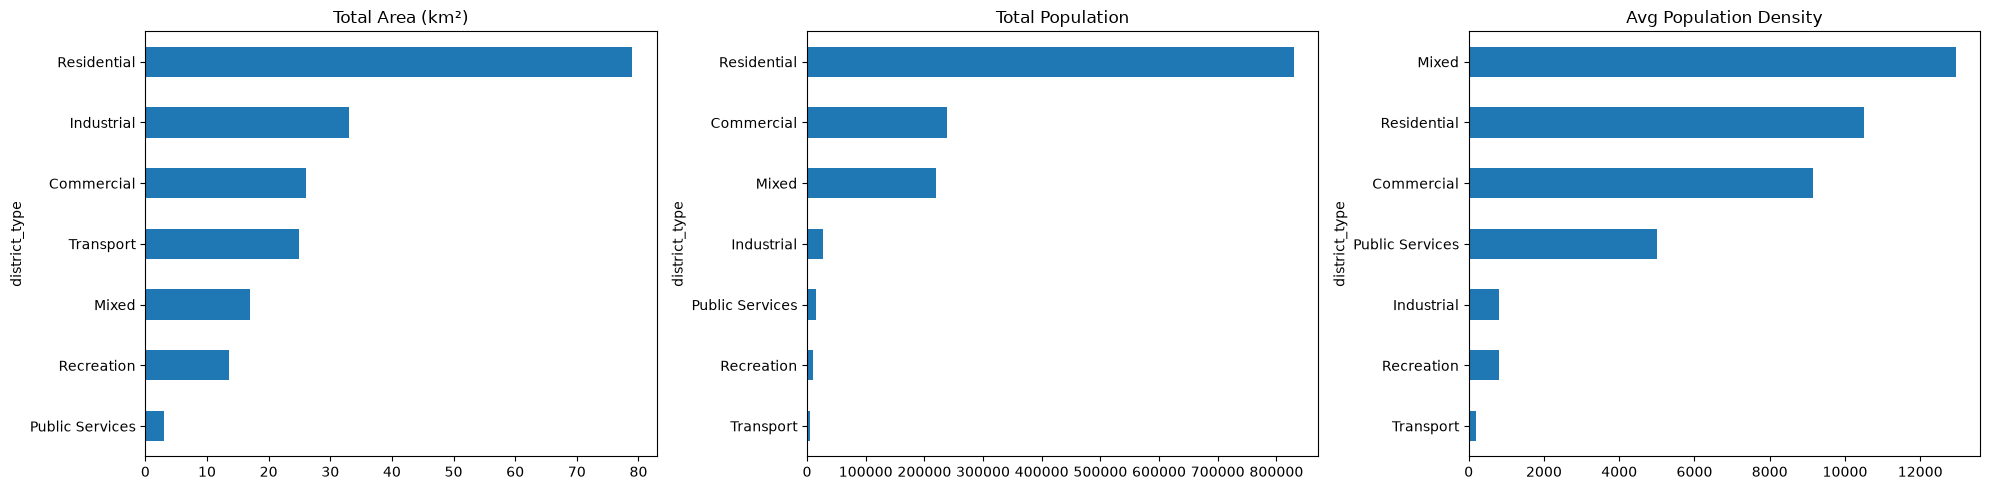

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
result['area_km2'].sort_values().plot(kind='barh', ax=axes[0], title='Total Area (km²)')
result['population'].sort_values().plot(kind='barh', ax=axes[1], title='Total Population')
result['population_density'].sort_values().plot(kind='barh', ax=axes[2], title='Avg Population Density')
plt.tight_layout()

#### Insights — population, area and density by district type

- **Mixed** districts have the highest density (~12,940 people/km²) despite modest total 
  population and area — they pack people into compact zones efficiently 
- **Residential** districts hold the largest total population (830,000) and the largest 
  total area (79 km²) by far, but their density (~10,500/km²) is second, not first — 
  population is spread out rather than concentrated.
- **Commercial** districts (~9,150/km²) sit close behind residential in density but with a 
  fraction of the total population/area — commercial zones are smaller and denser workplaces, 
  not living space.
- **Industrial** and **Recreation** types have almost identical, low density (~815-820/km²) 
  for very different reasons: industrial zones are built for machinery/logistics, not people; 
  recreation zones (parks) are intentionally low-population green space.
- **Transport** (Airport District) is the extreme outlier: the largest single area (25 km²) 
  but lowest population (5,000), giving the lowest density (~200/km²) — consistent with 
  infrastructure that needs land but not residents.
- **Public Services** (Medical District) is a small, single-district category — its density 
  (~5,000/km²) is only representative of one district, so we treat it as a data point, not a trend.

> **Rule of thumb used throughout this notebook — when to `sum` and when to `mean`**
>
> - **Sum** when the column is a count or measurement of quantity that genuinely accumulates:
>   population, area, traffic volume, demand in MWh.
> - **Mean (or median)** when the column is a rate, index, percentage or score — something that
>   describes intensity or quality *per unit*, and would be meaningless added together:
>   `congestion_index`, `commercial_activity_index`, `grid_load_percent`.
>
> Getting this backwards is one of the easiest ways to produce a confident, wrong number.

<a id="s1-3"></a>

### 1.3 Commercial vs industrial activity

*Why we run this.* A sanity check on the dataset's internal consistency: if a district is labelled
`Industrial`, does it actually score high on `industrial_activity_index`? If the labels and the
numbers disagree, every later grouping by `district_type` becomes suspect.

Both indices are scores (0–100), so here we average rather than sum, per the rule above.

In [12]:
# Here we will use mean not sum as the commercial and industrial activity are intensive quantities, something like rating or score not a count
result2 = districts.groupby('district_type').agg({'commercial_activity_index': 'mean', 'industrial_activity_index': 'mean'})
result2

,commercial_activity_index,industrial_activity_index
district_type,,
Commercial,91.000000,11.000000
Industrial,40.000000,97.500000
Mixed,63.333333,8.333333
Public Services,60.000000,10.000000
Recreation,42.500000,2.500000
Residential,30.000000,7.500000
Transport,70.000000,60.000000


Text(0.5, 1.0, 'Commercial vs Industrial Activity by District Type')

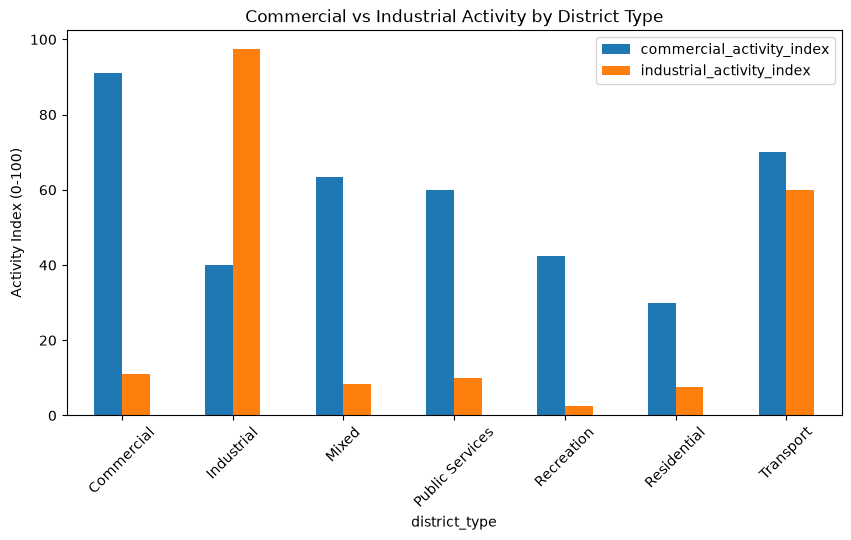

In [13]:
result2.plot(kind='bar', figsize=(10,5))
plt.ylabel('Activity Index (0-100)')
plt.xticks(rotation=45)
plt.title('Commercial vs Industrial Activity by District Type')

#### Insights — do the district labels match the numbers?

- The labels match the numbers well for the two "pure" types: **Commercial** districts 
  average ~91 on commercial_activity_index and only ~11 on industrial — and **Industrial** 
  districts average ~97.5 on industrial_activity_index and only ~40 on commercial. 
  The dataset is internally consistent, not just randomly labeled.
- **Residential** districts score low on both indices (~30 commercial, ~7.5 industrial) — 
  as expected, they're not activity hubs, they're where people live.
- **Mixed** districts sit in between (~63 commercial, ~8 industrial) — leaning commercial-heavy 
  rather than truly balanced between the two.
- **Transport** (Airport District) is the interesting outlier: moderately high on BOTH 
  commercial (70) and industrial (60) — makes sense, an airport has retail/commerce activity 
  plus industrial/logistics operations simultaneously.
- **Recreation** and **Public Services** each rely on just 1-2 districts, so their averages describe individual districts more 
  than a general pattern for the type.

<a id="s1-4"></a>

### 1.4 How the district attributes relate to each other

*Why we run this.* With 12 numeric attributes there are 66 possible pairings — far too many to check
one at a time. A correlation heatmap shows all of them at once and tells us which pairs deserve a
closer look, which are redundant, and which are independent.

We include the derived `population_density` alongside the raw columns so it can be compared directly
against the physical attributes.

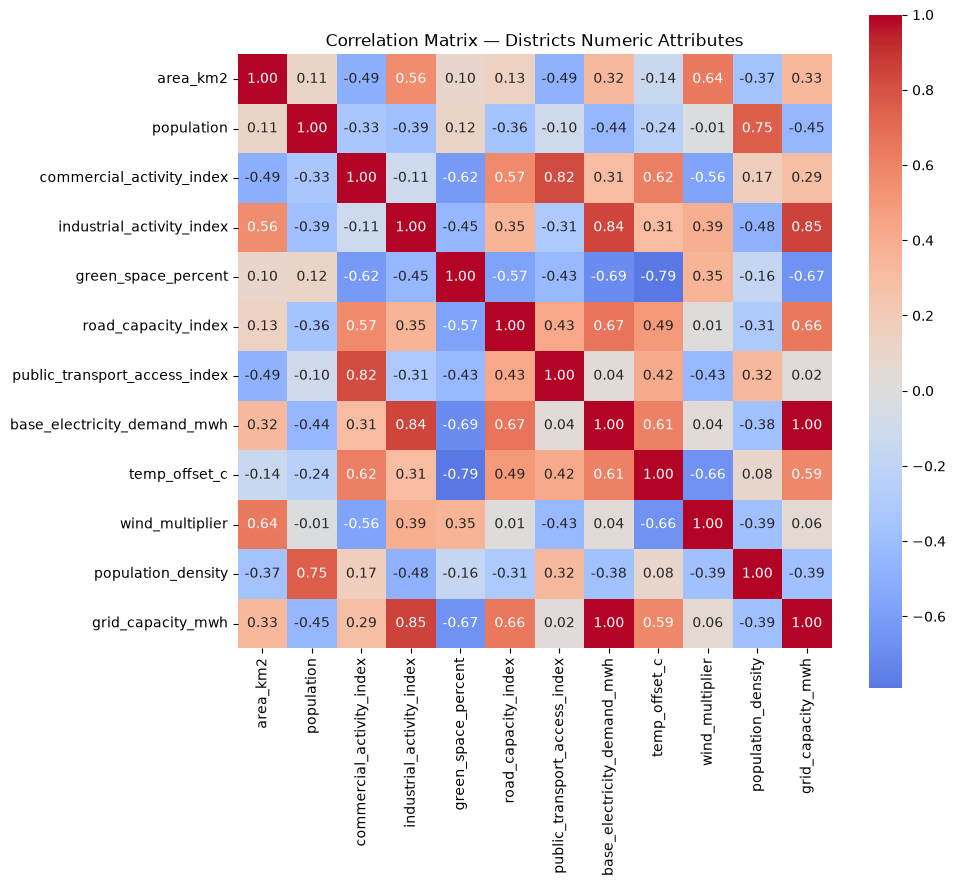

In [14]:
numeric_cols = ['area_km2', 'population', 'commercial_activity_index', 'industrial_activity_index',
                'green_space_percent', 'road_capacity_index', 'public_transport_access_index',
                'base_electricity_demand_mwh', 'temp_offset_c', 'wind_multiplier',
                'population_density', 'grid_capacity_mwh']

corr_matrix = districts[numeric_cols].corr()

plt.figure(figsize=(10, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Districts Numeric Attributes')
plt.tight_layout()

#### Insights — correlation matrix of district attributes

**Physical geography drives wind exposure**
- `area_km2` correlates with `wind_multiplier` (r=0.64) — larger districts are more open/exposed, 
  consistent with less wind-blocking (fewer buildings per km²).
- `population_density` correlates negatively with `wind_multiplier` (r=-0.39) — denser districts 
  are more built-up, which dampens wind. Both point to the same underlying story: 
  density and openness are opposite ends of the same spectrum.

**Activity type drives infrastructure needs, not just usage**
- `industrial_activity_index` correlates strongly with `grid_capacity_mwh` (r=0.85) and 
  `base_electricity_demand_mwh` (r=0.82) — industrial districts are both provisioned for and 
  consuming more power, as expected for machinery-heavy zones.
- `industrial_activity_index` correlates negatively with `green_space_percent` (r=-0.45) — 
  industrial and green space are competing land uses, confirming the contrast we already saw 
  in the activity-index groupby.
- `commercial_activity_index` correlates with `public_transport_access_index` (r=0.82) — 
  commercial hubs are prioritized for transit access, likely because they draw daily commuter 
  traffic that residential zones don't.

**Road capacity tracks economic activity, not just size**
- `road_capacity_index` correlates with `base_electricity_demand_mwh` (r=0.67) and 
  `commercial_activity_index` (r=0.57) — road infrastructure seems sized to match a district's 
  economic/commercial weight rather than purely its physical area or population.

**Overall pattern**: this dataset's infrastructure variables (grid, transport, roads) appear 
designed around *activity type* (commercial vs industrial) more than around raw population or 
area — a planning-driven allocation rather than a purely organic/population-driven one.

> **A caution before reading anything causal into the numbers above.**
>
> Two variables can correlate strongly because (1) A causes B, (2) B causes A, (3) a third variable
> causes both, or (4) coincidence. With 20 rows, coincidence is a live possibility for weak
> correlations.
>
> For the strong pairs found here (r ≈ 0.82–0.85 between industrial activity, grid capacity and
> electricity demand) option **3** is almost certainly what is happening: a zoning decision made at
> design time set *both* the activity rating and the grid provisioning. The correlation is real and
> useful for prediction; it is not evidence that one causes the other.

<a id="s1-5"></a>

### 1.5 Zooming in on the strongest relationships

*Why we run this.* The heatmap gives a single number per pair; a scatter plot with a fitted line
shows the *shape* behind that number — whether the relationship is genuinely linear, whether it is
driven by one or two extreme districts, and how tightly the points hug the trend.

- **First pair of plots** — industrial activity against both electricity demand and grid capacity,
  the two strongest correlations in the matrix.
- **Second plot** — commercial activity against public transport access (r = 0.82), testing whether
  transit provisioning follows commercial importance.

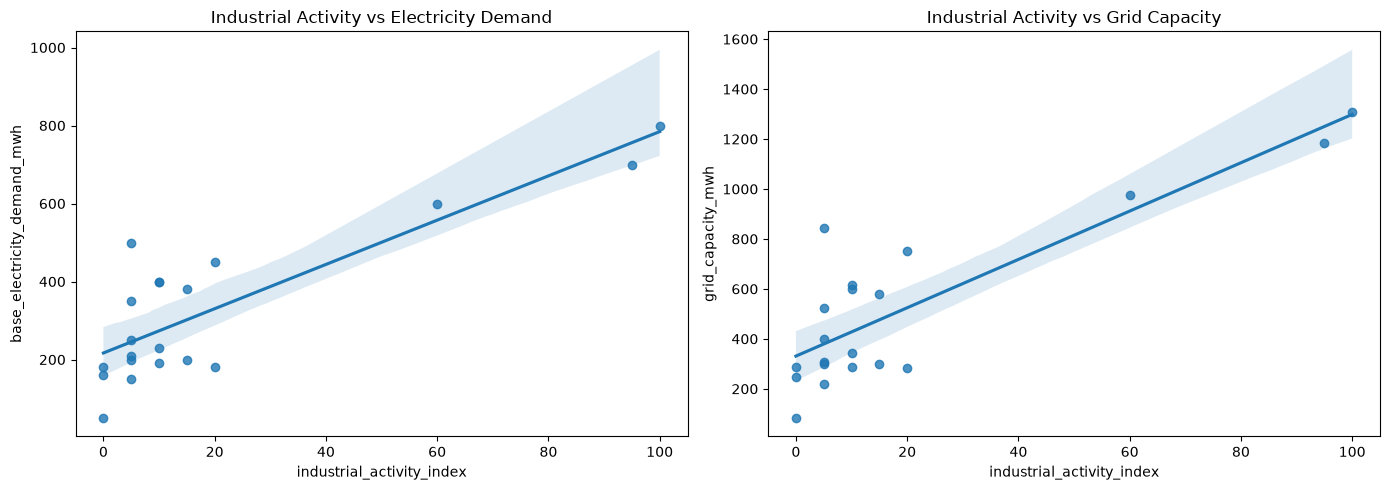

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=districts, x='industrial_activity_index', y='base_electricity_demand_mwh', ax=axes[0])
axes[0].set_title('Industrial Activity vs Electricity Demand')

sns.regplot(data=districts, x='industrial_activity_index', y='grid_capacity_mwh', ax=axes[1])
axes[1].set_title('Industrial Activity vs Grid Capacity')

plt.tight_layout()

#### Insights — industrial activity vs power

- Both `base_electricity_demand_mwh` (r=0.82) and `grid_capacity_mwh` (r=0.85) rise clearly 
  with `industrial_activity_index`, and the regression line fits the points closely with no 
  major outliers — industrial districts are consistently high-power, low-industrial districts 
  are consistently low-power.
- Grid capacity tracks industrial activity slightly more tightly than actual demand does — 
  suggesting capacity was planned around a district's industrial *rating*, with demand following 
  close behind but not perfectly.

Text(0.5, 1.0, 'Commercial Activity vs Public Transport Access')

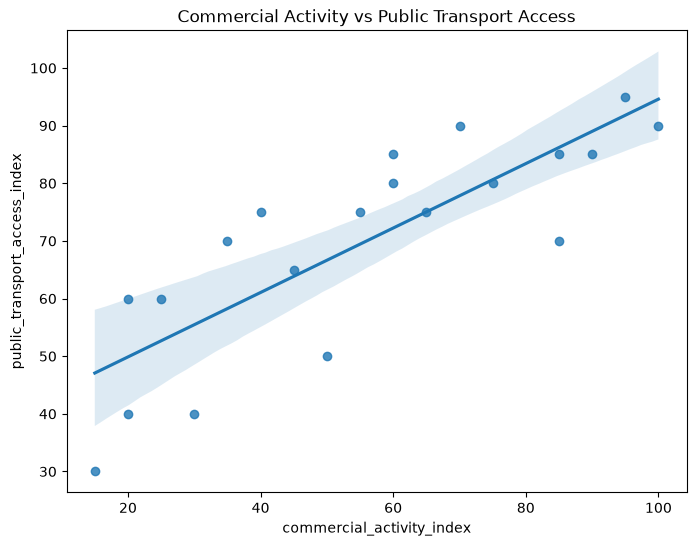

In [16]:
plt.figure(figsize=(8,6))
sns.regplot(data=districts, x='commercial_activity_index', y='public_transport_access_index')
plt.title('Commercial Activity vs Public Transport Access')

#### Insights — commercial activity vs transit access

- A clear positive linear trend (r=0.82) — districts with higher commercial activity 
  consistently have better public transport access, with points sitting close to the fitted line.
- This suggests transit infrastructure in this dataset is allocated based on commercial 
  importance rather than being uniform or population-driven.

<a id="s1-6"></a>

### 1.6 Power supply vs power demand, and a first engineered feature

*Why we run this.* Two of the columns describe the same physical system from opposite sides:
`grid_capacity_mwh` is what the grid can supply, `base_electricity_demand_mwh` is what the district
normally draws. The gap between them is the safety headroom — and it is not in the file, so we
compute it.

- **`groupby(...).agg(sum)`** — total demand and total capacity per district type (both are
  extensive, so summing is correct here).
- **`margin_ratio`** — the *proportion* of capacity sitting unused. Good for comparing districts of
  very different sizes on equal terms.
- **Bar chart** — demand next to capacity, so the absolute scale difference between types is visible
  alongside the ratio.
- **`leftover_capacity_mwh`** — the same idea in absolute MWh. Ratio answers "how stretched is this
  district?"; absolute answers "how many MWh can it actually absorb?"

Note these two are mathematically linked (`margin_ratio = leftover / capacity`), so they are not
independent features — they are two readings of one quantity, kept because each is easier to
interpret in a different context.

In [17]:
result3 = districts.groupby('district_type').agg({'base_electricity_demand_mwh':'sum', 'grid_capacity_mwh':'sum'})
result3

,base_electricity_demand_mwh,grid_capacity_mwh
district_type,,
Commercial,2080,3314.550814
Industrial,1500,2491.133012
Mixed,510,790.936133
Public Services,400,601.233911
Recreation,250,382.075759
Residential,1240,1886.347528
Transport,600,976.210887


In [18]:
# margin_ration answers how much room is left but in a fractional form , يعني فاضل قد ايه من ال grid capacity
result3['margin_ratio'] = (result3['grid_capacity_mwh'] - result3['base_electricity_demand_mwh']) / result3['grid_capacity_mwh'] 
result3.sort_values(by='margin_ratio', ascending=False)

,base_electricity_demand_mwh,grid_capacity_mwh,margin_ratio
district_type,,,
Industrial,1500,2491.133012,0.397864
Transport,600,976.210887,0.385379
Commercial,2080,3314.550814,0.372464
Mixed,510,790.936133,0.355194
Recreation,250,382.075759,0.345680
Residential,1240,1886.347528,0.342645
Public Services,400,601.233911,0.334702


Text(0, 0.5, 'MWh')

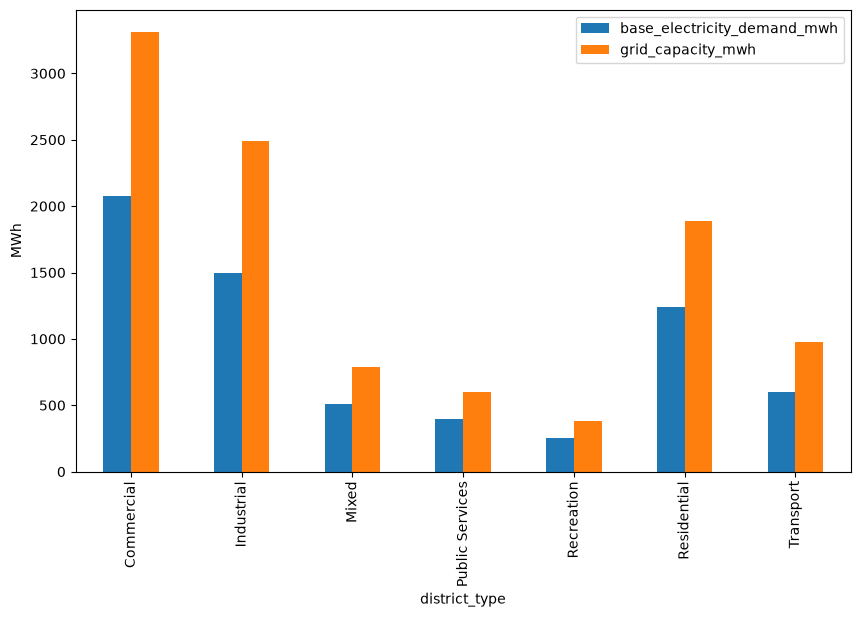

In [19]:
fig, ax1 = plt.subplots(figsize=(10,6))
result3[['base_electricity_demand_mwh','grid_capacity_mwh']].plot(kind='bar', ax=ax1)
ax1.set_ylabel('MWh')

#### Insights — supply headroom by district type

- Every district type shows grid capacity comfortably above demand, with roughly similar 
  proportional headroom across the board (~33-40%) — no type is at risk of overuse.
- Commercial and Industrial types carry the largest absolute demand and capacity (2080/3314.5 
  and 1500/2491.1 MWh respectively) — consistent with the earlier finding that industrial 
  activity strongly predicts grid capacity (r=0.85).
- Recreation and Public Services have the smallest absolute numbers, simply because they 
  represent the fewest districts (1-2 each), not because they're inherently low-demand types.
- The consistent margin across very different absolute scales suggests grid capacity in this 
  dataset was designed as a fixed multiplier of demand, rather than customized per district type.

In [20]:
result3['leftover_capacity_mwh'] = result3['grid_capacity_mwh'] - result3['base_electricity_demand_mwh']
result3.sort_values(by='leftover_capacity_mwh', ascending=False)

,base_electricity_demand_mwh,grid_capacity_mwh,margin_ratio,leftover_capacity_mwh
district_type,,,,
Commercial,2080,3314.550814,0.372464,1234.550814
Industrial,1500,2491.133012,0.397864,991.133012
Residential,1240,1886.347528,0.342645,646.347528
Transport,600,976.210887,0.385379,376.210887
Mixed,510,790.936133,0.355194,280.936133
Public Services,400,601.233911,0.334702,201.233911
Recreation,250,382.075759,0.345680,132.075759


#### Feature Engineering: Grid Margin per District

Added two columns to `districts`, computed at the individual district level (not just per type):

- **`margin_ratio`** = (grid_capacity_mwh - base_electricity_demand_mwh) / grid_capacity_mwh — 
  the proportion of each district's grid capacity that sits unused, as a safety buffer.
- **`leftover_capacity_mwh`** = grid_capacity_mwh - base_electricity_demand_mwh — the 
  absolute spare capacity (in MWh) each district has before hitting its designed limit.

These are kept at district granularity (not aggregated) so they can later be compared against 
real-time demand in the `power_grid` fact table — e.g. flagging moments where actual usage 
eats significantly into a district's baseline headroom.

In [21]:
districts['margin_ratio'] = (districts['grid_capacity_mwh'] - districts['base_electricity_demand_mwh']) / districts['grid_capacity_mwh']
districts['leftover_capacity_mwh'] = districts['grid_capacity_mwh'] - districts['base_electricity_demand_mwh']
districts.head()

,district_id,district_name,district_type,area_km2,population,commercial_activity_index,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh,margin_ratio,leftover_capacity_mwh
0,D01,Downtown,Commercial,5.2,120000,95,10,5,80,95,400,1.5,0.7,23076.923077,617.454012,0.352178,217.454012
1,D02,Financial District,Commercial,3.8,45000,100,5,8,85,90,500,1.2,0.6,11842.105263,843.839288,0.407470,343.839288
2,D03,Industrial Zone,Industrial,15.0,15000,30,100,2,70,40,800,2.0,0.9,1000.000000,1306.398788,0.387630,506.398788
3,D04,North Residential,Residential,12.5,180000,40,5,30,60,75,250,-0.5,1.1,14400.000000,399.916155,0.374869,149.916155
4,D05,South Residential,Residential,14.0,160000,35,10,25,65,70,230,0.0,1.0,11428.571429,342.471072,0.328410,112.471072


<a id="s1-7"></a>

### 1.7 Chapter takeaways

**The dataset is internally consistent.** District type labels match their activity indices closely
(`Commercial` districts average ~91 commercial / ~11 industrial; `Industrial` districts ~97.5
industrial / ~40 commercial). Grouping by `district_type` later in the notebook is therefore
meaningful, not cosmetic.

**Infrastructure here is planned around activity, not population.** Grid capacity, road capacity and
transit access all track the commercial and industrial activity indices far more strongly than they
track population or area. This is an allocation-by-design city, not an organically grown one.

**Density and openness are opposite ends of one spectrum.** `area_km2` correlates with
`wind_multiplier` (0.64) while `population_density` correlates against it (−0.39) — larger, emptier
districts are more wind-exposed. This will show up again in Chapter 2 as measurably higher wind
speeds in Transport and Industrial districts.

**Two engineered features were added** — `margin_ratio` and `leftover_capacity_mwh` — kept at
district granularity so real-time demand from `power_grid.csv` can later be compared against each
district's designed headroom.

> **Pitfall caught here.** `margin_ratio` and a "utilisation percent" framing of the same quantity
> are redundant: one is simply `1 − x` of the other. Only one belongs in a model's feature set.

> **Small-sample caveat to carry forward.** `Recreation`, `Transport` and `Public Services` are
> backed by only one or two districts each. Their "type averages" describe individual districts and
> should never be read as a trend about the type.

---
<a id="ch2"></a>

# Part II — The hourly sensor tables

## 2. `weather.csv` — citywide weather readings

[↑ back to contents](#toc)

**What this file is.** The first of five hourly fact tables: one row per district per hour, roughly
525,000 rows covering three years across all 20 districts.

**What each row carries.**

- **Measurements**: `temperature_c`, `feels_like_c`, `humidity_percent`, `rainfall_mm`,
  `wind_speed_kmh`, `cloud_cover_percent`
- **Derived labels**: `weather_condition` (Clear / Partly Cloudy / Heatwave / Storm / Heavy Rain)
- **Pre-built event flags**: `heatwave_flag`, `heavy_rain_flag`, `storm_flag`
- **Metadata**: `sensor_status` — the column that explains every missing value in this file

**Questions this chapter answers**

1. Why are values missing, and can they be dropped without biasing later per-district analysis?
2. What is the city's seasonal rhythm, and how predictable are extreme events?
3. Do the three event flags actually correspond to the measurements they claim to represent?
4. Do the district design knobs from Chapter 1 (`temp_offset_c`, `green_space_percent`) show up in
   real measured temperature?

This is also where the notebook's standard cleaning sequence appears in full for the first time; the
four chapters that follow use the same shape, so this one is documented in the most detail.

<a id="s2-1"></a>

### 2.1 Loading, types and duplicates

*Why we run this.* Three things must be true before analysis starts: we know what is in the file,
the timestamp is a real datetime (otherwise no resampling, no `.dt` accessor, no time sorting), and
the key `(timestamp, district_id)` identifies exactly one row.

- **`head` / `info` / `shape`** — the opening inventory. `info()` already reveals that six
  measurement columns carry nulls.
- **`timestamp.dtype`** — confirm it loaded as `object` (plain strings), which is why the conversion
  below is needed.
- **`to_datetime`** — convert once, up front. Everything time-based in this chapter depends on it.
- **`info()` / `dtype` again** — verify the conversion actually took effect rather than assuming it.
- **`duplicated(subset=[...])`** — check the composite key is unique. A duplicate here would mean two
  conflicting readings for the same district-hour and would silently distort every later average.

In [22]:
weather = pd.read_csv('data/weather.csv')

In [23]:
weather.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal
1,2023-01-01 00:00:00,D02,-2.475176,-1.545861,48.722873,0.0,4.265831,18.424018,Clear,0,0,0,Normal
2,2023-01-01 00:00:00,D03,-1.561745,-1.703843,65.891753,0.0,5.326696,51.155525,Partly Cloudy,0,0,0,Normal
3,2023-01-01 00:00:00,D04,-5.354549,-4.472566,41.808144,0.0,6.990799,49.194123,Partly Cloudy,0,0,0,Normal
4,2023-01-01 00:00:00,D05,-4.592405,-2.461893,68.152662,0.0,7.783494,12.968903,Clear,0,0,0,Normal


In [24]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            526080 non-null  str    
 1   district_id          526080 non-null  str    
 2   temperature_c        519519 non-null  float64
 3   feels_like_c         519519 non-null  float64
 4   humidity_percent     519519 non-null  float64
 5   rainfall_mm          519519 non-null  float64
 6   wind_speed_kmh       519519 non-null  float64
 7   cloud_cover_percent  519519 non-null  float64
 8   weather_condition    526080 non-null  str    
 9   heatwave_flag        526080 non-null  int64  
 10  heavy_rain_flag      526080 non-null  int64  
 11  storm_flag           526080 non-null  int64  
 12  sensor_status        526080 non-null  str    
dtypes: float64(6), int64(3), str(4)
memory usage: 52.2 MB


#####   temperature_c , feels_like_c, humidity_percent, rainfall_mm, wind_speed_kmh, cloud_cover_percent  have null values

In [25]:
weather.shape

(526080, 13)

#### checking that all rows of timestamp column is in the same format

In [26]:
weather['timestamp'].dtype

<StringDtype(storage='python', na_value=nan)>

In [27]:
weather['timestamp'] = pd.to_datetime(weather['timestamp'])

In [28]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            526080 non-null  datetime64[us]
 1   district_id          526080 non-null  str           
 2   temperature_c        519519 non-null  float64       
 3   feels_like_c         519519 non-null  float64       
 4   humidity_percent     519519 non-null  float64       
 5   rainfall_mm          519519 non-null  float64       
 6   wind_speed_kmh       519519 non-null  float64       
 7   cloud_cover_percent  519519 non-null  float64       
 8   weather_condition    526080 non-null  str           
 9   heatwave_flag        526080 non-null  int64         
 10  heavy_rain_flag      526080 non-null  int64         
 11  storm_flag           526080 non-null  int64         
 12  sensor_status        526080 non-null  str           
dtypes: datetime64[us](1), flo

In [29]:
weather['timestamp'].dtype

dtype('<M8[us]')

In [30]:
weather.duplicated(subset=['timestamp', 'district_id']).sum()

np.int64(0)

<a id="s2-2"></a>

### 2.2 Missing values: finding the mechanism before deleting anything

*Why we run this.* Dropping rows is destructive and irreversible. Before doing it we want answers to
three questions, in order:

1. **Which columns are null, and do they go null together?** If all six measurements fail on the
   same rows, that points to one shared cause rather than six independent problems.
2. **What was the sensor doing at the time?** `sensor_status` is the ground truth on cause.
3. **Is the missingness evenly spread?** If one district or one time of day loses far more readings
   than the others, dropping those rows would bias every per-district comparison later in the
   notebook.

Cell by cell:

- **`isna().any()` / `isna().sum()`** — which columns are affected and how badly.
- **`sensor_status.value_counts()`** — the possible states and their frequency.
- **`sensor_status` of the null rows** — the key diagnostic: it shows the nulls are exactly the
  `Communication-Loss` and `Storm-Affected` rows.
- **The loop over `null_columns`** — a deliberate, explicit proof rather than an assumption. It
  compares the null *index* of each column against `temperature_c`'s null index; an empty conflict
  list means all six columns fail on precisely the same rows.
- **Per-district outage rate** — the bias check.
- **`dropna(subset=['temperature_c'])`** — the actual cleaning step, executed only after the three
  questions above are answered. Because the nulls are row-aligned, dropping on one column drops
  them all.
- **`isna().any()` on the result** — verification that `weather_clean` is now null-free.

#### Nulls Check temperature_c , feels_like_c, humidity_percent, rainfall_mm, wind_speed_kmh, cloud_cover_percent have nulls

In [31]:
weather.isna().any()

timestamp              False
district_id            False
temperature_c           True
feels_like_c            True
humidity_percent        True
rainfall_mm             True
wind_speed_kmh          True
cloud_cover_percent     True
weather_condition      False
heatwave_flag          False
heavy_rain_flag        False
storm_flag             False
sensor_status          False
dtype: bool

In [32]:
weather['temperature_c'].isna().sum()

np.int64(6561)

In [33]:
weather['sensor_status'].value_counts()

sensor_status
Normal                519519
Communication-Loss      5240
Storm-Affected          1321
Name: count, dtype: int64

In [34]:
weather[weather['temperature_c'].isna()]['sensor_status'].value_counts()

sensor_status
Communication-Loss    5240
Storm-Affected        1321
Name: count, dtype: int64

> **Why the loop below instead of just trusting the equal null counts.** Six columns can each
> have 6,561 nulls while being null on *different* rows. Equal counts are suggestive, not proof.
> Comparing the actual index of the null rows is the proof, and it is what lets us drop on a single
> column with confidence.

In [35]:
temp_nulls = weather[weather['temperature_c'].isna()].index
null_columns = ['feels_like_c', 'humidity_percent', 'rainfall_mm', 'wind_speed_kmh', 'cloud_cover_percent']
nulls_conflicts = []
for i in null_columns:
    if not (temp_nulls.equals(weather[weather[i].isna()].index)):
        nulls_conflicts.append(i)

print(nulls_conflicts)

[]


In [36]:
weather.groupby('district_id')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

district_id
D01    0.013572
D02    0.012394
D03    0.012280
D04    0.012203
D05    0.011557
D06    0.013154
D07    0.012318
D08    0.013268
D09    0.012546
D10    0.012318
D11    0.012660
D12    0.013078
D13    0.012584
D14    0.011823
D15    0.012165
D16    0.011937
D17    0.012584
D18    0.011595
D19    0.012241
D20    0.013154
Name: sensor_status, dtype: float64

#### Data Quality Check: Sensor Outage Distribution Across Districts

Checked whether the 6,561 missing weather readings were concentrated in specific districts or 
spread evenly, by computing each district's rate of non-"Normal" `sensor_status`:

- Outage rates ranged from ~1.16% to ~1.36% across all 20 districts — a very narrow spread.
- No district stands out with a meaningfully higher or lower outage rate; sensor reliability 
  is essentially uniform city-wide.
- This confirms the missing values are a general, low-frequency outage pattern (communication 
  loss / storm interference) rather than a localized data quality problem tied to a specific 
  district's sensors.

In [37]:
weather_clean = weather.dropna(subset=['temperature_c'])
weather.shape

(526080, 13)

In [38]:
weather_clean.isna().any()

timestamp              False
district_id            False
temperature_c          False
feels_like_c           False
humidity_percent       False
rainfall_mm            False
wind_speed_kmh         False
cloud_cover_percent    False
weather_condition      False
heatwave_flag          False
heavy_rain_flag        False
storm_flag             False
sensor_status          False
dtype: bool

<a id="s2-3"></a>

### 2.3 Distributions and outliers

*Why we run this.* Univariate analysis — looking at one column at a time — decides how every later
step must be handled. A symmetric column can be summarised by its mean and screened with the IQR
rule; a skewed or zero-inflated one cannot, and treating it as if it could is how false findings get
made.

- **`describe()`** — the numeric summary for all six measurements.
- **Six histograms** — the shapes. Immediately visible: temperature is roughly symmetric, rainfall
  is a spike at zero.
- **Rainfall histogram, rain events only** — re-plotting with `rainfall_mm > 0` removes the zero
  spike that otherwise compresses the entire rest of the distribution into one bar.
- **Percentage of dry hours** — quantifies that spike (~90%), which is what makes the IQR result
  below misleading.
- **`iqr_outliers` loop** — the flagged count per column (helper defined in Chapter 0).
- **`skew()`** — confirms numerically what the histograms show for wind and cloud cover.
- **Boxplots** — all six columns together, for a final visual read on spread and extremes.

In [39]:
weather_clean.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status
0,2023-01-01,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal
1,2023-01-01,D02,-2.475176,-1.545861,48.722873,0.0,4.265831,18.424018,Clear,0,0,0,Normal
2,2023-01-01,D03,-1.561745,-1.703843,65.891753,0.0,5.326696,51.155525,Partly Cloudy,0,0,0,Normal
3,2023-01-01,D04,-5.354549,-4.472566,41.808144,0.0,6.990799,49.194123,Partly Cloudy,0,0,0,Normal
4,2023-01-01,D05,-4.592405,-2.461893,68.152662,0.0,7.783494,12.968903,Clear,0,0,0,Normal


In [40]:
weather_numeric_columns = ['temperature_c',	'feels_like_c',	'humidity_percent',	'rainfall_mm', 'wind_speed_kmh', 'cloud_cover_percent']
weather_clean[weather_numeric_columns].describe()

,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent
count,519519.000000,519519.000000,519519.000000,519519.000000,519519.000000,519519.000000
mean,15.422149,15.976453,57.165794,0.224046,10.360801,36.066847
std,9.655175,9.811287,16.605181,1.164443,7.527080,24.802513
min,-8.571818,-8.827606,10.000000,0.000000,0.000000,0.000000
25%,7.515030,7.998750,45.828456,0.000000,6.288192,18.222685
50%,15.227820,15.729304,56.572001,0.000000,8.894495,32.749490
75%,23.185695,23.715757,67.908072,0.000000,12.354339,49.104366
max,46.174378,49.852034,100.000000,37.499098,118.012067,100.000000


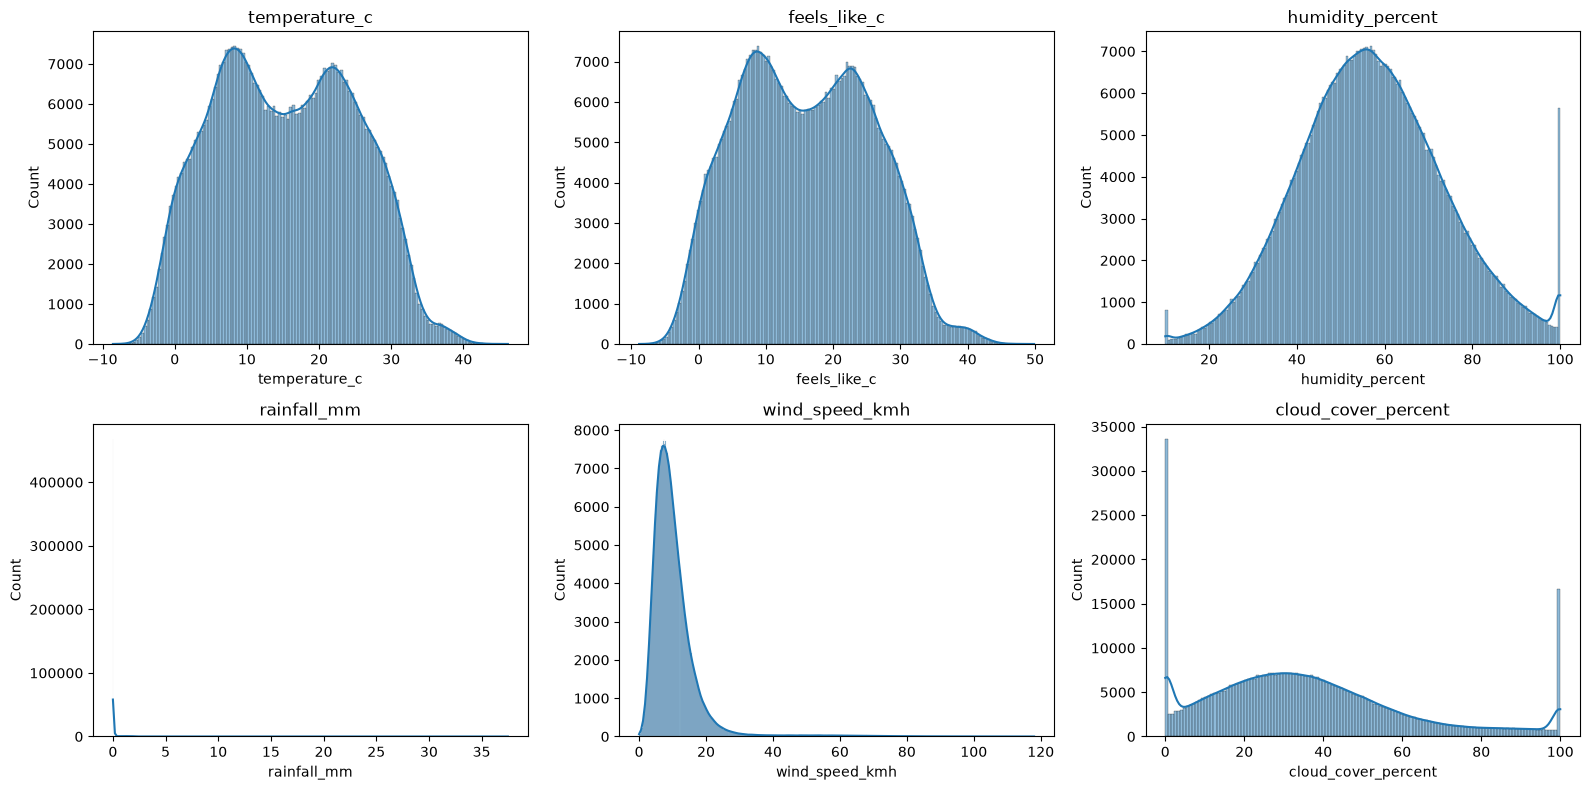

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(weather_numeric_columns):
    sns.histplot(weather_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

Text(0.5, 1.0, 'Rainfall Distribution (rain events only, rainfall_mm > 0)')

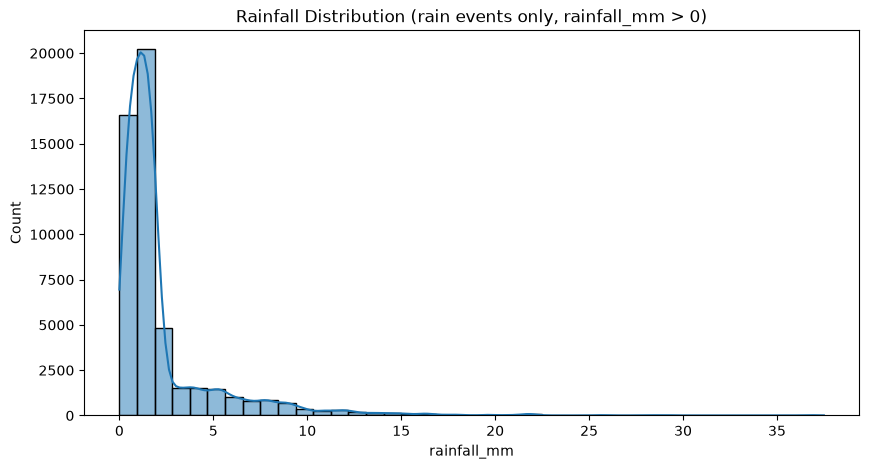

In [42]:
# Distribution of Rainfall days only
plt.figure(figsize=(10,5))
sns.histplot(weather_clean[weather_clean['rainfall_mm'] > 0]['rainfall_mm'], kde=True, bins=40)
plt.title('Rainfall Distribution (rain events only, rainfall_mm > 0)')

In [43]:
# Percentage of days with no rainfall
(weather_clean['rainfall_mm'] == 0).mean() * 100

np.float64(90.12471151199475)

In [44]:
for col in weather_numeric_columns:
    n_out = len(iqr_outliers(weather_clean[col]))
    print(f"{col}: {n_out} outliers ({n_out/len(weather_clean)*100:.2f}%)")

temperature_c: 0 outliers (0.00%)
feels_like_c: 8 outliers (0.00%)
humidity_percent: 1282 outliers (0.25%)
rainfall_mm: 51304 outliers (9.88%)
wind_speed_kmh: 21406 outliers (4.12%)
cloud_cover_percent: 20434 outliers (3.93%)


In [45]:
# both are right skewed
weather_clean[['wind_speed_kmh', 'cloud_cover_percent']].skew()

wind_speed_kmh         4.511511
cloud_cover_percent    0.763218
dtype: float64

Text(0.5, 1.0, 'Boxplots of Weather Measurements')

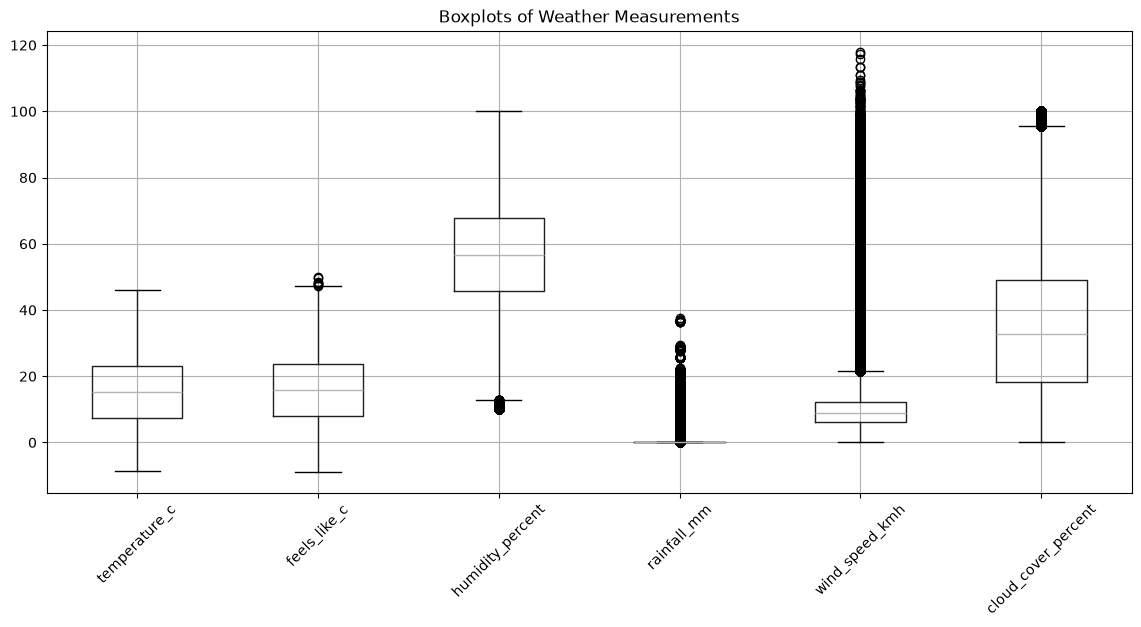

In [46]:
weather_clean[weather_numeric_columns].boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.title('Boxplots of Weather Measurements')

#### Insights — distribution and outliers in the weather measurements

#### Insights: Distribution & Outliers in Weather Measurements

- `temperature_c` and `feels_like_c` show a wide but natural seasonal range (-8.6°C to 
  46.2°C) with zero and near-zero IQR-flagged outliers — the extremes are real seasonal 
  variation across the full year, not anomalies.
- `rainfall_mm` is heavily zero-inflated: with Q1=Q3=0, the IQR method flags 51,304 readings 
  as "outliers," but this is a statistical artifact of a distribution that's mostly zero with 
  a sparse tail of actual rain events, not a data quality issue. As we have 90 percent of the days have no rain
- `wind_speed_kmh` and `cloud_cover_percent` both show large IQR-flagged counts (~20,000-21,000), 
  consistent with right-skewed distributions rather than symmetric ones — most readings cluster 
  at lower/moderate values with a longer tail toward higher values.
- **Takeaway**: the standard IQR outlier rule is only reliable for the roughly symmetric 
  columns (temperature, feels_like); for skewed/zero-inflated columns (rainfall, wind, cloud 
  cover), a high "outlier count" reflects distribution shape, not erroneous data.

**Outlier handling:** No values were removed or capped anywhere in weather.csv. All 
"outliers" flagged by IQR (rainfall, wind speed, cloud cover) were confirmed to be either 
zero-inflation artifacts (rainfall) or genuine extreme-but-real weather events tied to 
storm activity (wind speed) — removing them would have deleted the real signal used in the 
flag-validation insights.

<a id="s2-4"></a>

### 2.4 Trends over time

*Why we run this.* Hourly data is too noisy to read directly — 525,000 points on one axis is a
smear. Aggregating to a daily average per column reveals the seasonal structure underneath, and is
the level at which "does this city have a predictable weather year?" can actually be answered.

- **`resample('D').mean()`** — collapse to one row per day.
- **Temperature plot with heatwave markers** — the daily temperature curve, with
  `heatwave_flag` days overlaid in red. Using `.max()` when resampling the flag means a day counts
  as a heatwave day if *any* hour in it was flagged.
- **Monthly rainfall totals** — rainfall is summed (it accumulates) rather than averaged, and
  monthly rather than daily because rain is episodic.
- **30-day rolling averages of wind and cloud cover** — both are noisy day to day; a rolling mean
  exposes whether they move together seasonally.

In [47]:
# time series trends
weather_daily = weather_clean.set_index('timestamp').resample('D')[weather_numeric_columns].mean()
weather_daily.head()

,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent
timestamp,,,,,,
2023-01-01,3.962504,4.373714,58.957224,0.090105,9.802109,38.140835
2023-01-02,4.397693,4.916750,56.537949,0.081610,9.049223,32.812885
2023-01-03,3.591868,4.096798,56.994808,0.138775,9.172241,34.005690
2023-01-04,3.598831,4.104863,58.531572,0.070103,7.814294,36.715881
2023-01-05,3.269605,3.730571,61.113077,0.247456,9.460721,43.536417


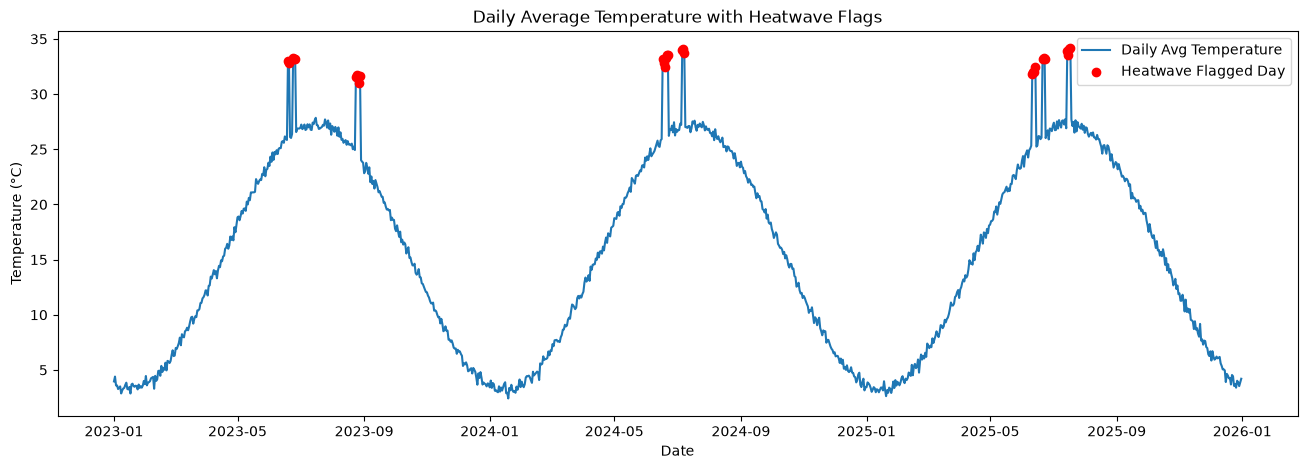

In [48]:
# temperature_c trend over time
heatwave_flag = weather_clean.set_index('timestamp').resample('D')['heatwave_flag'].max()

plt.figure(figsize=(16,5))
plt.plot(weather_daily.index, weather_daily['temperature_c'], label='Daily Avg Temperature')

heatwave_days = heatwave_flag[heatwave_flag == 1].index
plt.scatter(heatwave_days, weather_daily.loc[heatwave_days, 'temperature_c'],
            color='red', label='Heatwave Flagged Day', zorder=5)

plt.title('Daily Average Temperature with Heatwave Flags')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.legend()

# spikes in the plot means the occurence of heatwaves

#### Insights: Seasonal Temperature Cycle & Heatwave Events
- Temperature follows a strong, stable annual cycle (~3-4°C winter low, ~27°C summer high), 
  repeating consistently across all 3 years with no long-term warming trend which gives us a known seasonal load curve
- Distinct short-duration heatwave spikes (reaching 31-34°C) occur every summer, always clustered 
  around the seasonal peak (roughly June-August)
  This recurring annual timing is operationally useful: emergency services and grid operators can 
  anticipate a heightened-risk window each summer rather than treating heatwaves as unpredictable 
- These spikes represent a strong candidate to cross-check directly against `power_grid`'s electricity demand and `emergency_events` around 
  the same dates later in the cross-table analysis.
- No equivalent sharp cold-extreme spikes appear in winter — suggesting heatwaves are a distinct, 
  engineered event type in this dataset rather than symmetric weather noise in both directions.

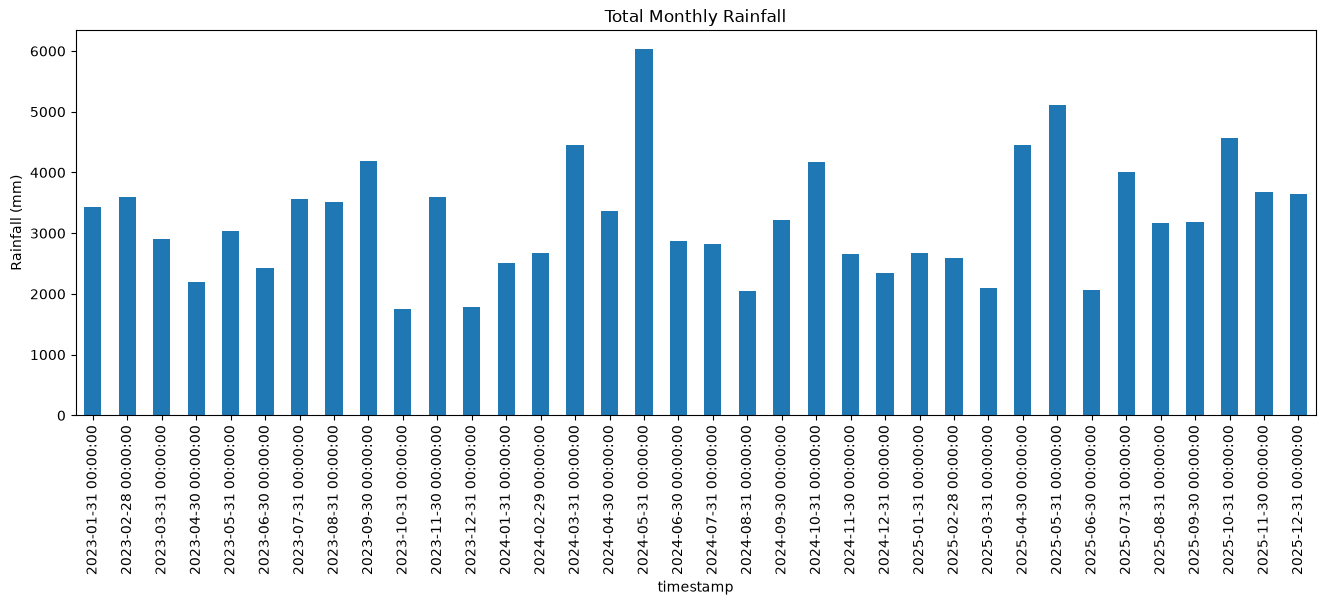

In [49]:
weather_monthly_rain = weather_clean.set_index('timestamp').resample('ME')['rainfall_mm'].sum()
plt.figure(figsize=(16,5))
weather_monthly_rain.plot(kind='bar')
plt.title('Total Monthly Rainfall')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=90)
plt.show()

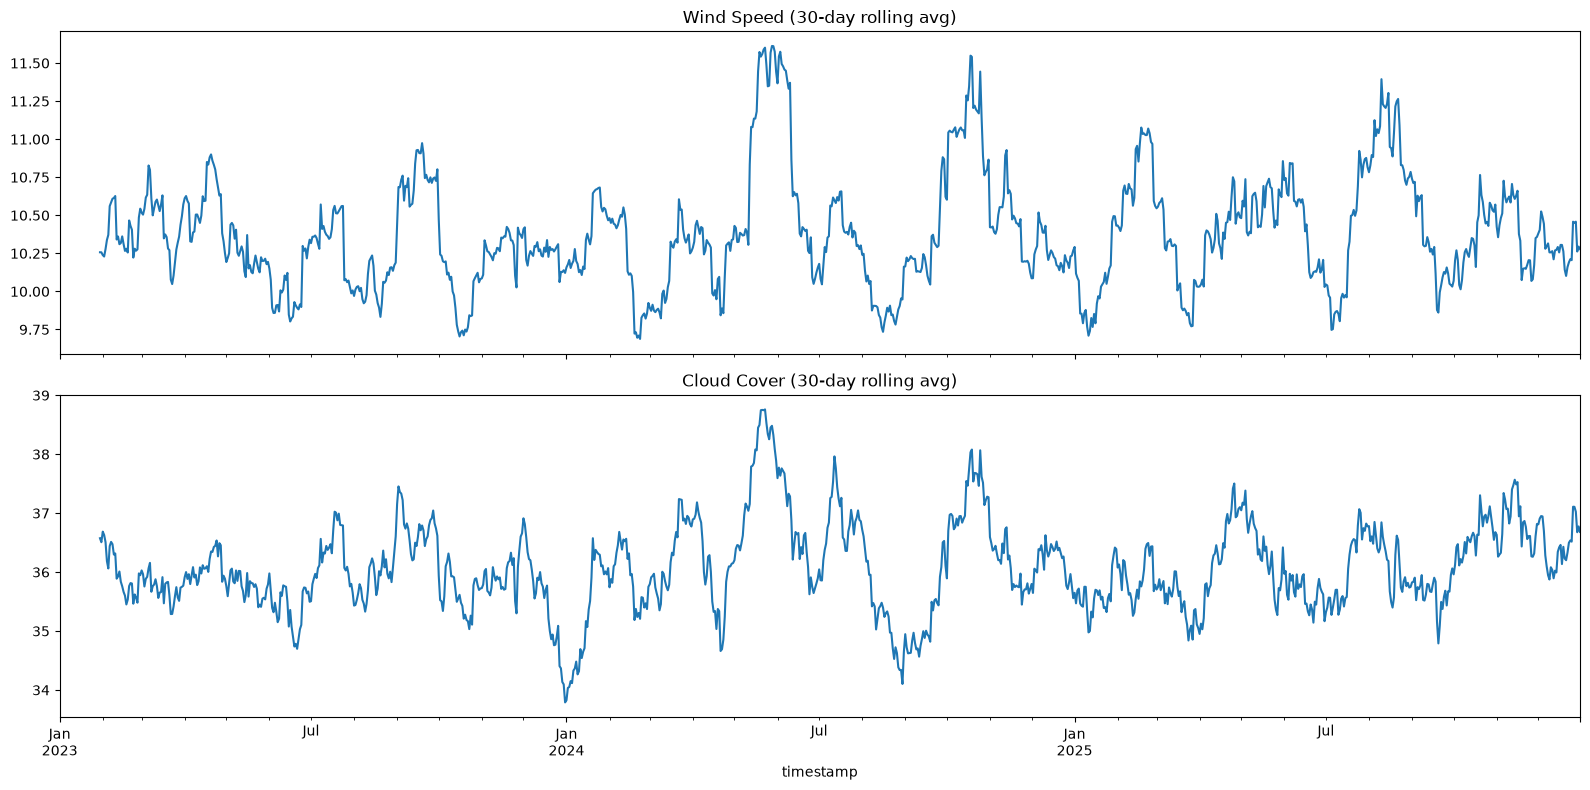

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(16,8), sharex=True)

weather_daily['wind_speed_kmh'].rolling(window=30).mean().plot(ax=axes[0], title='Wind Speed (30-day rolling avg)')
weather_daily['cloud_cover_percent'].rolling(window=30).mean().plot(ax=axes[1], title='Cloud Cover (30-day rolling avg)')

plt.tight_layout()

#### Insights: Rainfall, Wind & Cloud Cover Trends
- Monthly rainfall totals fluctuate irregularly (~1,750-6,050mm) with no clean single seasonal 
  peak like temperature. May 2024 stands out as an extreme month (~6,000mm), a candidate to cross-check 
  against `storm_flag`/`heavy_rain_flag` and, later, against `emergency_events` for flooding-
  related incidents.
- Wind speed and cloud cover move together almost in lockstep — suggesting a shared underlying driver (likely storm activity) rather than independent 
  behavior.


<a id="s2-5"></a>

### 2.5 Weather conditions and relationships between variables

*Why we run this.* Two complementary views of the same question — how does this city's weather
behave as a system?

- **`weather_condition` counts, percentages and bar chart** — how much of the time the city is in
  each state. The percentage version is what makes the numbers interpretable; 7,541 storm readings
  means nothing until it is expressed against 525,000 total.
- **Correlation heatmap** — which measurements move together. This is where the "storm cluster"
  (rain + wind + cloud + humidity) and the independence of temperature from all of them shows up.

In [51]:
weather_clean['weather_condition'].value_counts()

weather_condition
Clear            227644
Partly Cloudy    217832
Rain              38466
Heatwave          12585
Cloudy            10142
Storm              7541
Heavy Rain         5309
Name: count, dtype: int64

In [52]:
# percentage of each weather condition
weather_clean['weather_condition'].value_counts() / weather_clean.shape[0] * 100

weather_condition
Clear            43.818224
Partly Cloudy    41.929554
Rain              7.404157
Heatwave          2.422433
Cloudy            1.952190
Storm             1.451535
Heavy Rain        1.021907
Name: count, dtype: float64

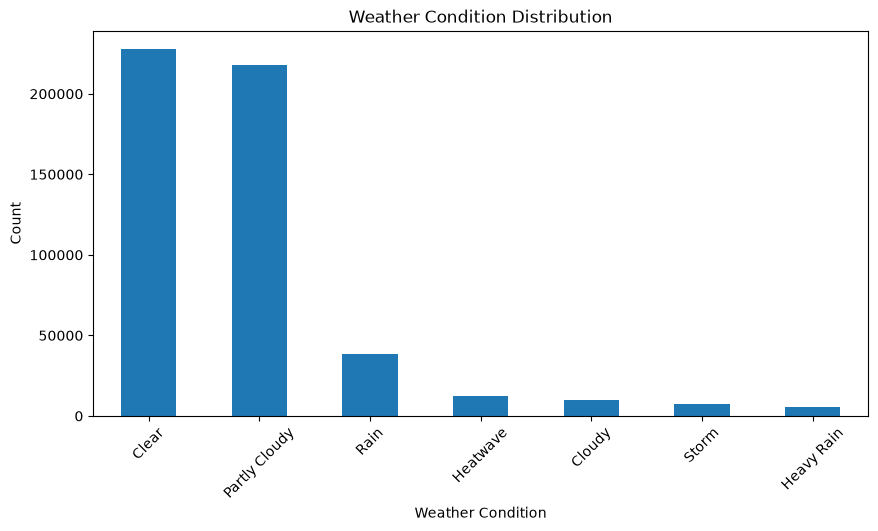

In [53]:
weather_clean['weather_condition'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Weather Condition Distribution')
plt.ylabel('Count')
plt.xlabel('Weather Condition')
plt.xticks(rotation=45)
plt.show()

#### Insights: Weather Condition Distribution
- Clear (43.8%) and Partly Cloudy (41.9%) together account for ~86% of all readings — normal, 
  non-disruptive conditions dominate the vast majority of the time.
- Disruptive/extreme conditions are comparatively rare but non-trivial in absolute terms: 
  Heatwave (12,585 readings), Storm (7,541), and Heavy Rain (5,309) together represent roughly 
  5% of all readings — infrequent, but frequent enough that emergency services and grid 
  operators should have standing response plans rather than treating them as one-off events.
- This distribution supports the earlier finding that extreme heat (heatwave spikes) and 
  extreme rain (storm season) are the two distinct disruption patterns worth monitoring 
  operationally, each with its own seasonal timing.

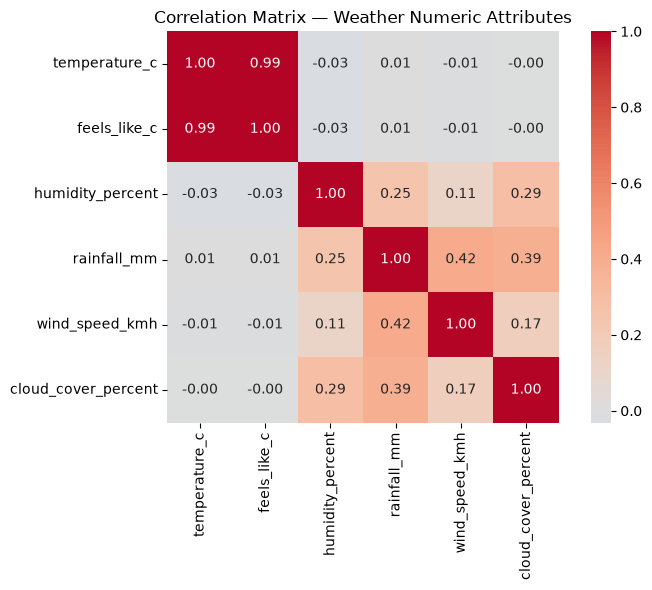

In [54]:
corr_matrix = weather_clean[weather_numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Weather Numeric Attributes')
plt.tight_layout()

#### Insights: Correlations Between Weather Variables

- `temperature_c` and `feels_like_c` correlate almost perfectly (0.99), as expected since 
  feels-like temperature is derived from raw temperature — confirms data consistency rather 
  than revealing a new pattern.
- Temperature is essentially unrelated to humidity, rainfall, wind, or cloud cover (all near 
  zero, -0.03 to 0.01) — heat events and storm events are independent phenomena in this city.
- `rainfall_mm` is the most connected variable — moderately correlated with `wind_speed_kmh` 
  (0.42), `cloud_cover_percent` (0.39), and `humidity_percent` (0.25). This forms a coherent 
  "storm cluster": rain events tend to arrive together with wind, cloud cover, and humidity 
  increases, consistent with the wind/cloud co-movement seen in the time-trend plots.
- **Business takeaway**: since heat and storm risk are statistically independent, infrastructure 
  planning should treat summer heatwave preparedness and storm/rain preparedness as two separate 
  operational windows rather than a single "bad weather season," and can reasonably expect 
  wind/humidity/cloud-cover readings to jointly signal an incoming rain event.

<a id="s2-6"></a>

### 2.6 Flag validation: heatwave, heavy rain, storm

*Why we run this.* `heatwave_flag`, `heavy_rain_flag` and `storm_flag` were not measured — someone
derived them. Before any later chapter uses them to segment data, we check each one against the raw
measurement it is supposed to represent. For each flag the question is the same: *do flagged rows
genuinely differ from unflagged ones on the variable that matters?*

- **`groupby(flag).describe()`** — the numeric comparison, with the full distribution rather than
  just the means, so overlap between the two groups is visible.
- **Boxplots** — the same comparison visually.
- **Note on the rainfall boxplots** — they are filtered to `rainfall_mm > 0`. Including the ~90% of
  dry hours would flatten both boxes onto zero and hide the real difference between ordinary rain
  and heavy rain.
- **`storm_flag` against two variables at once** — storms are tested against rainfall *and* wind
  speed, because the hypothesis is that a storm is a compound event rather than just intense rain.

In [55]:
weather_clean.groupby('heatwave_flag')['temperature_c'].describe()

,count,mean,std,min,25%,50%,75%,max
heatwave_flag,,,,,,,,
0,505343.0,14.931956,9.303646,-8.571818,7.329479,14.745646,22.584158,38.388448
1,14176.0,32.896432,4.109093,20.997535,29.494482,32.806342,36.378070,46.174378


Text(0.5, 1.0, 'Temperature Distribution: Heatwave Flagged vs Not')

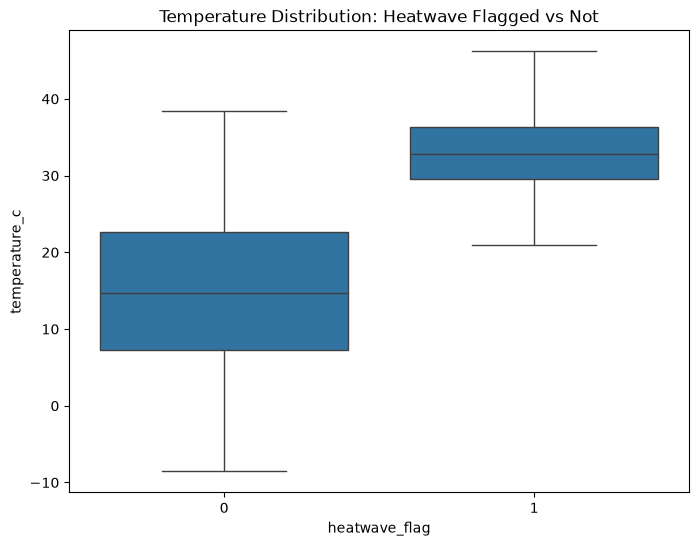

In [56]:
plt.figure(figsize=(8,6))
sns.boxplot(data=weather_clean, x='heatwave_flag', y='temperature_c')
plt.title('Temperature Distribution: Heatwave Flagged vs Not')

In [57]:
weather_clean.groupby('heavy_rain_flag')['rainfall_mm'].describe()

,count,mean,std,min,25%,50%,75%,max
heavy_rain_flag,,,,,,,,
0,506669.0,0.082487,0.327017,0.0,0.000000,0.000000,0.00000,2.666294
1,12850.0,5.805662,4.319684,0.0,2.846727,4.901006,7.69269,37.499098


Text(0.5, 1.0, 'Rainfall Distribution (non-zero only): Heavy Rain Flagged vs Not')

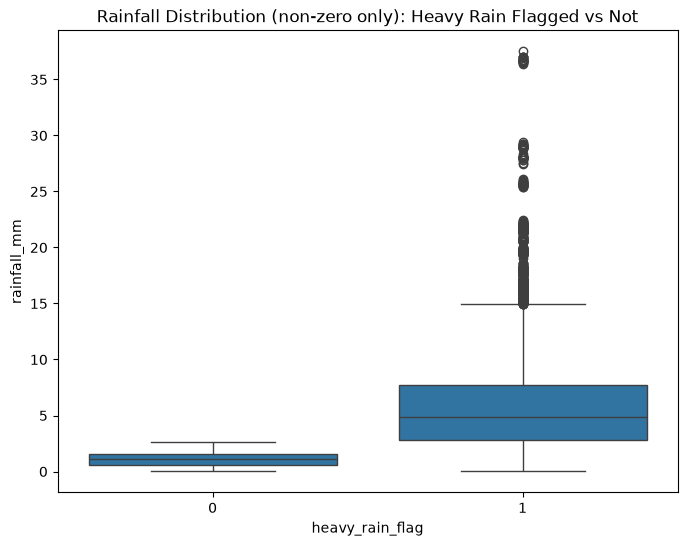

In [58]:
plt.figure(figsize=(8,6))
sns.boxplot(data=weather_clean[weather_clean['rainfall_mm'] > 0], x='heavy_rain_flag', y='rainfall_mm')
plt.title('Rainfall Distribution (non-zero only): Heavy Rain Flagged vs Not')

In [59]:
weather_clean.groupby('storm_flag')[['rainfall_mm', 'wind_speed_kmh']].describe()

rainfall_mm                                                         \
                 count      mean       std  min       25%       50%       75%   
storm_flag                                                                      
0             511978.0  0.140564  0.801539  0.0  0.000000  0.000000  0.000000   
1               7541.0  5.891839  4.147282  0.0  3.002727  4.933566  7.840082   

                      wind_speed_kmh                                  \
                  max          count       mean        std       min   
storm_flag                                                             
0           37.499098       511978.0   9.711874   4.931869   0.00000   
1           29.411014         7541.0  54.418189  16.800548  17.23977   

                                                         
                  25%        50%        75%         max  
storm_flag                                               
0            6.249160   8.815016  12.156261   57.306231  
1           42.138574  53.392762  65.220376  118.012067

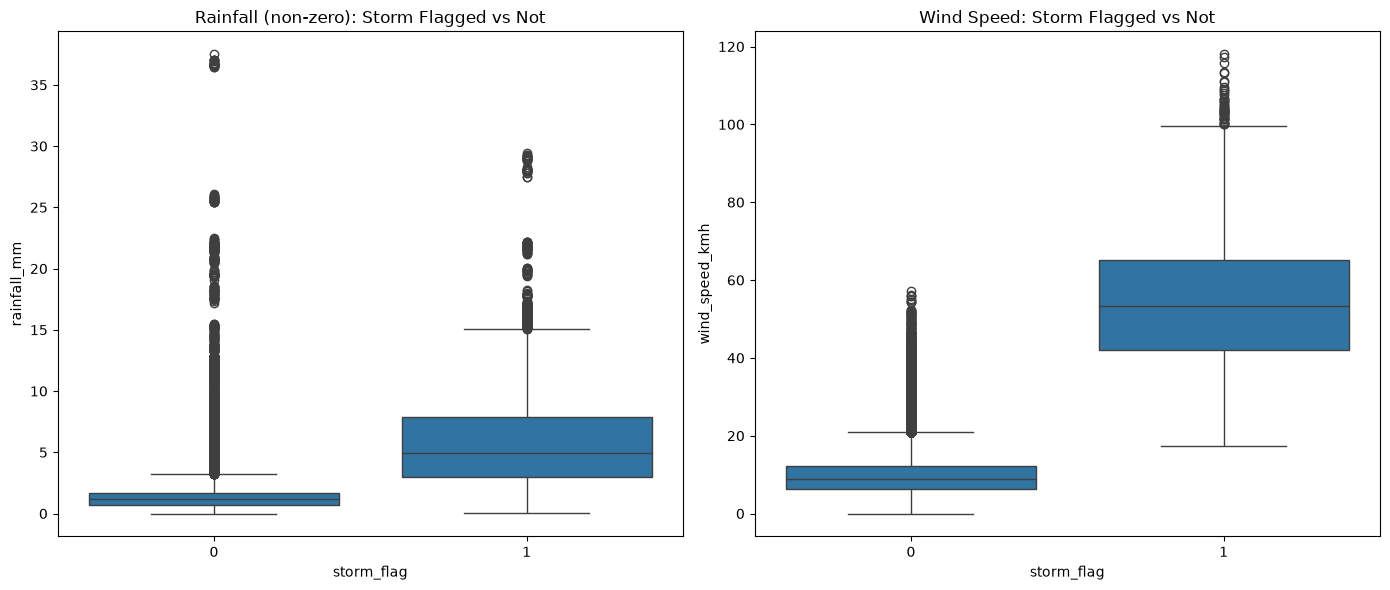

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(data=weather_clean[weather_clean['rainfall_mm'] > 0], x='storm_flag', y='rainfall_mm', ax=axes[0])
axes[0].set_title('Rainfall (non-zero): Storm Flagged vs Not')

sns.boxplot(data=weather_clean, x='storm_flag', y='wind_speed_kmh', ax=axes[1])
axes[1].set_title('Wind Speed: Storm Flagged vs Not')

plt.tight_layout()

#### Insights: Flag Validation Summary — Heatwave, Heavy Rain & Storm

- All three flags behave as reliable, threshold-based indicators rather than noisy labels — 
  each shows a clear, consistent separation between flagged and non-flagged conditions on the 
  variable(s) it's meant to represent.
- `heatwave_flag` is driven purely by temperature (flagged avg 32.9°C vs 14.9°C non-flagged).
- `heavy_rain_flag` is driven purely by rainfall intensity (flagged avg ~5mm vs ~1.1mm for 
  ordinary light rain, once zero-inflation is accounted for).
- `storm_flag` is a compound event, defined by both elevated rainfall (avg ~5.9mm, similar to 
  heavy rain) AND sharply elevated wind speed (avg ~54.4 km/h vs ~9.7 km/h non-flagged — the 
  strongest separation of the three flags). This confirms storms as a distinct `wind + rain`
  event type, not just an intensified version of either heatwave or heavy rain alone.
- **Business takeaway**: these three flags map to three operationally distinct risk types — 
  heat response (grid cooling load, health risk), rain response (drainage, flooding), and 
  storm response (structural/wind damage, combined with flooding). 

<a id="s2-7"></a>

### 2.7 District context: microclimates and the urban heat island

*Why we run this.* Chapter 1 found two district-level design knobs that claim to affect weather:
`temp_offset_c` (an explicit per-district temperature adjustment) and `green_space_percent`. This
section tests both against three years of actual readings — the first cross-table merge in the
notebook.

- **`merge(districts, on='district_id')`** — a left join attaching all 20 district attributes to
  every weather row. `how='left'` preserves all weather rows; the null check afterwards confirms no
  district_id failed to match.
- **Mean temperature per district vs `temp_offset_c`** — sorted by the offset, so a monotonic
  relationship becomes visible directly in the table.
- **Weather averages by `district_type`** — do different zone types experience measurably different
  weather?
- **Green space vs temperature correlation** — aggregated to district level first (20 rows), because
  `green_space_percent` is a static district property; correlating it row-by-row against 525,000
  hourly readings would just measure the same 20 values repeated thousands of times.

In [61]:
weather_merged = weather_clean.merge(districts, on='district_id', how='left')
weather_merged.shape

(519519, 29)

In [62]:
weather_merged.isna().sum()

timestamp                        0
district_id                      0
temperature_c                    0
feels_like_c                     0
humidity_percent                 0
rainfall_mm                      0
wind_speed_kmh                   0
cloud_cover_percent              0
weather_condition                0
heatwave_flag                    0
heavy_rain_flag                  0
storm_flag                       0
sensor_status                    0
district_name                    0
district_type                    0
area_km2                         0
population                       0
commercial_activity_index        0
industrial_activity_index        0
green_space_percent              0
road_capacity_index              0
public_transport_access_index    0
base_electricity_demand_mwh      0
temp_offset_c                    0
wind_multiplier                  0
population_density               0
grid_capacity_mwh                0
margin_ratio                     0
leftover_capacity_mw

In [63]:
weather_merged

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,...,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh,margin_ratio,leftover_capacity_mwh
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.000000,2.755095,46.435298,Partly Cloudy,0,...,5,80,95,400,1.5,0.7,23076.923077,617.454012,0.352178,217.454012
1,2023-01-01 00:00:00,D02,-2.475176,-1.545861,48.722873,0.000000,4.265831,18.424018,Clear,0,...,8,85,90,500,1.2,0.6,11842.105263,843.839288,0.407470,343.839288
2,2023-01-01 00:00:00,D03,-1.561745,-1.703843,65.891753,0.000000,5.326696,51.155525,Partly Cloudy,0,...,2,70,40,800,2.0,0.9,1000.000000,1306.398788,0.387630,506.398788
3,2023-01-01 00:00:00,D04,-5.354549,-4.472566,41.808144,0.000000,6.990799,49.194123,Partly Cloudy,0,...,30,60,75,250,-0.5,1.1,14400.000000,399.916155,0.374869,149.916155
4,2023-01-01 00:00:00,D05,-4.592405,-2.461893,68.152662,0.000000,7.783494,12.968903,Clear,0,...,25,65,70,230,0.0,1.0,11428.571429,342.471072,0.328410,112.471072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519514,2025-12-31 23:00:00,D16,-1.261698,-0.666163,60.830995,0.663662,8.914146,100.000000,Rain,0,...,25,85,75,200,0.2,1.0,2000.000000,299.170225,0.331484,99.170225
519515,2025-12-31 23:00:00,D17,-0.662302,-1.335669,80.285183,0.354334,7.383650,100.000000,Rain,0,...,20,80,70,380,0.5,0.9,2769.230769,579.903013,0.344718,199.903013
519516,2025-12-31 23:00:00,D18,-0.382823,-0.844826,76.184470,0.356022,12.736382,91.339311,Rain,0,...,30,60,75,180,-0.8,1.3,13636.363636,284.614039,0.367565,104.614039
519517,2025-12-31 23:00:00,D19,-2.058800,-3.345184,100.000000,0.268990,12.599144,49.721780,Rain,0,...,45,45,40,160,-1.0,1.2,10000.000000,249.277801,0.358146,89.277801


In [64]:
weather_merged.groupby('district_id')[['temperature_c']].mean().merge(
    districts[['district_id', 'temp_offset_c']], on='district_id'
).sort_values('temp_offset_c').reset_index(drop=True)

,district_id,temperature_c,temp_offset_c
0,D13,13.680369,-1.5
1,D19,14.186631,-1.0
2,D18,14.394900,-0.8
3,D04,14.673891,-0.5
4,D12,14.680940,-0.5
5,D20,14.677956,-0.5
6,D09,14.889803,-0.3
7,D07,14.979509,-0.2
8,D05,15.177199,0.0
9,D16,15.378541,0.2


In [65]:
weather_merged.groupby('district_type')[weather_numeric_columns].mean()

,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent
district_type,,,,,,
Commercial,16.180138,16.738616,57.189595,0.225062,7.705781,36.104781
Industrial,15.934753,16.484574,57.124775,0.225415,12.497601,35.979301
Mixed,15.223882,15.775626,57.182242,0.223468,9.721790,36.090277
Public Services,15.674997,16.223565,57.294490,0.226006,9.377980,35.917055
Recreation,14.529732,15.084645,57.234975,0.224855,11.453948,36.152420
Residential,14.847829,15.401643,57.101164,0.221894,11.274411,36.059649
Transport,16.181493,16.739042,57.200123,0.227307,14.590463,36.003909


In [66]:
temperature_green_space = weather_merged.groupby('district_id', as_index=False)[['temperature_c']].mean().merge(
    districts[['district_id', 'green_space_percent']], on='district_id'
)
temperature_green_space[['temperature_c', 'green_space_percent']].corr()

,temperature_c,green_space_percent
temperature_c,1.000000,-0.791152
green_space_percent,-0.791152,1.000000


#### Insights: District-Level Weather Validation

- `temp_offset_c` (engineered in `districts.csv`) shows a near-perfect monotonic relationship 
  with real average `temperature_c` per district — confirming this engineered feature reflects 
  a genuine, consistent microclimate effect rather than being a disconnected static value.
- District type shows modest but sensible differences in weather: wind speed is highest in 
  Transport (14.6 km/h) and Industrial (12.5 km/h) districts and lowest in Commercial 
  (7.7 km/h) — consistent with the earlier finding that larger, more open districts 
  (area_km2 correlating with wind_multiplier) are more wind-exposed.
- `green_space_percent` correlates strongly and negatively with average temperature 
  (r=-0.79) — real evidence of an urban heat island effect: districts with less green space 
  run measurably hotter.
- **Business takeaway**: both `temp_offset_c` and `green_space_percent` are validated, 
  trustworthy predictors of a district's real temperature behavior — either would be a 
  reasonable input feature for a downstream model forecasting temperature or heat-related 
  grid/health risk at the district level, without needing further transformation.

<a id="s2-8"></a>

### 2.8 Chapter takeaways

**Missing data is fully explained and safely removable.** 6,561 rows (1.25%) had all six
measurements null simultaneously, every one of them a `Communication-Loss` or `Storm-Affected`
sensor row. Outage rates ranged only from 1.16% to 1.36% across the 20 districts, so dropping them
carries no per-district bias. `weather_clean` is the frame used everywhere downstream.

**The city has two independent disruption seasons.** Temperature runs a stable annual cycle (~3 °C
winter to ~27 °C summer) with heatwave spikes of 31–34 °C every summer. Rain, wind and cloud form a
separate correlated "storm cluster" peaking February–April. Temperature is essentially uncorrelated
with all three (r ≈ 0), so heat preparedness and storm preparedness are two distinct operational
windows, not one bad-weather season.

**All three flags validate.** `heatwave_flag` tracks temperature (32.9 °C vs 14.9 °C),
`heavy_rain_flag` tracks rainfall intensity, and `storm_flag` is a genuine compound event requiring
both elevated rainfall *and* sharply elevated wind (54.4 km/h vs 9.7 km/h — the strongest separation
of the three). Overlapping ranges between flagged and unflagged rows suggest the flags use
multi-variable or duration-based rules rather than a single hard threshold.

**The district design knobs are real.** `temp_offset_c` maps monotonically onto measured average
temperature, and `green_space_percent` correlates −0.79 with it — measurable evidence of an urban
heat island effect. Both are validated, trustworthy inputs for any downstream temperature model.

**No values were removed or capped.** Every IQR-flagged extreme was either a zero-inflation artifact
(rainfall) or a genuine storm-driven reading.

> **Pitfalls caught in this chapter.**
>
> - **The 51,000 false-positive "outliers" on rainfall.** Applying the IQR rule to a column that is
>   90% zero puts Q1 = Q3 = 0, so every single rain event gets flagged as extreme. Restricting the
>   boxplots and the IQR reading to non-zero rain events resolved it. This same fix recurs in every
>   later chapter.
> - **Misreading the sign of a correlation.** The r = −0.79 between green space and temperature was
>   initially read as a *weak* relationship. A negative sign indicates direction, not weakness:
>   −0.79 is a strong inverse relationship.

---
<a id="ch3"></a>

## 3. `traffic.csv` — hourly road conditions

[↑ back to contents](#toc)

**What this file is.** Hourly road conditions per district, same grain and span as `weather.csv`.

**What each row carries.**

- **Core flow measurements**: `traffic_volume`, `average_speed_kmh`, `congestion_index`
- **Rare-event counters**: `accident_count`, `road_incident_count`, `special_event_impact`
- **A derived severity score**: `weather_impact_score`
- **Pre-built flags**: `rush_hour_flag`, `weekend_flag`, `accident_flag`
- **Metadata**: `sensor_status`

**What makes this chapter different from Chapter 2.** Most of the columns here are not raw
measurements — they are engineered. So the real work is *validation*: does `congestion_index`
behave like a sensible derived metric, does `rush_hour_flag` fire when it should, does
`weather_impact_score` actually reflect the weather? Almost nothing new gets engineered; a lot gets
checked.

The second difference is **zero-inflation**. Four columns sit at zero (or at a baseline of 1.0) in
over 90% of rows. They need different statistical handling from the continuous flow columns, and
every step below splits them out accordingly.

**Questions this chapter answers**

1. Do volume, speed and congestion describe one phenomenon or three?
2. Can the three flags be trusted at face value for downstream segmentation?
3. Is congestion driven by road capacity (supply) or by traffic demand?
4. Does bad weather measurably change traffic, and is `weather_impact_score` a fair proxy for it?

<a id="s3-1"></a>

### 3.1 Loading, types and duplicates

*Why we run this.* Same opening sequence as Chapter 2, with two additions specific to this file.

- **`head` / `shape` / `info`** — the inventory.
- **`to_datetime` + `astype('Int64')`** — the count-like columns are cast to a nullable integer type.
  Ordinary `int64` cannot hold nulls, so pandas would have loaded them as floats, giving `2.0`
  accidents and fractional axis ticks in histograms. `Int64` (capital I) keeps them integers while
  still allowing the sensor-outage nulls that this file has.
- **`duplicated().sum()`** — unlike `weather.csv`, this file contains genuine full-row duplicates.
- **Inspecting the duplicates before deleting** — confirming they are exact repeats rather than
  legitimate distinct readings that happen to look similar.
- **`drop_duplicates` + re-check** — remove, then verify the count is zero.

In [67]:
traffic = pd.read_csv('data/traffic.csv')

In [68]:
traffic.head(10)

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status
0,2024-09-18 17:00:00,D13,645.0,49.146283,25.226010,0.0,0,0.0,1.0,0.0,1.0,0.0,Normal
1,2023-07-08 17:00:00,D08,1321.0,39.828605,25.148830,0.0,0,0.0,0.0,1.0,1.4,0.0,Normal
2,2023-02-28 15:00:00,D17,1948.0,45.808054,27.286539,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
3,2024-11-18 03:00:00,D11,416.0,54.326914,11.527077,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
4,2024-08-31 10:00:00,D20,771.0,53.696496,14.911365,0.0,0,0.0,0.0,1.0,1.0,0.0,Normal
5,2024-07-29 01:00:00,D08,374.0,57.747494,3.469757,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
6,2023-09-21 03:00:00,D17,327.0,55.172585,6.103569,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
7,2025-10-02 00:00:00,D18,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,Communication-Loss
8,2023-08-01 06:00:00,D14,1459.0,45.124513,28.806914,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
9,2025-02-02 17:00:00,D07,1338.0,46.583809,23.229729,0.0,0,0.0,0.0,1.0,1.0,0.0,Normal


In [69]:
traffic.shape

(527132, 13)

In [70]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 527132 entries, 0 to 527131
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             527132 non-null  str    
 1   district_id           527132 non-null  str    
 2   traffic_volume        521867 non-null  float64
 3   average_speed_kmh     521867 non-null  float64
 4   congestion_index      521867 non-null  float64
 5   accident_count        521867 non-null  float64
 6   accident_flag         527132 non-null  int64  
 7   road_incident_count   521867 non-null  float64
 8   rush_hour_flag        521867 non-null  float64
 9   weekend_flag          521867 non-null  float64
 10  weather_impact_score  521867 non-null  float64
 11  special_event_impact  521867 non-null  float64
 12  sensor_status         527132 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 52.3 MB


In [71]:
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'], errors='coerce')
traffic_numeric_cols = ['traffic_volume', 'accident_count', 'road_incident_count', 'rush_hour_flag', 'weekend_flag']
for col in traffic_numeric_cols:
    traffic[col] = pd.to_numeric(traffic[col], errors='coerce').astype('Int64')
# Int64 is Nullable int, int64 can't store null values

In [72]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 527132 entries, 0 to 527131
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             527132 non-null  datetime64[us]
 1   district_id           527132 non-null  str           
 2   traffic_volume        521867 non-null  Int64         
 3   average_speed_kmh     521867 non-null  float64       
 4   congestion_index      521867 non-null  float64       
 5   accident_count        521867 non-null  Int64         
 6   accident_flag         527132 non-null  int64         
 7   road_incident_count   521867 non-null  Int64         
 8   rush_hour_flag        521867 non-null  Int64         
 9   weekend_flag          521867 non-null  Int64         
 10  weather_impact_score  521867 non-null  float64       
 11  special_event_impact  521867 non-null  float64       
 12  sensor_status         527132 non-null  str           
dtypes: Int64(5

In [73]:
traffic.duplicated().sum()

np.int64(1052)

In [74]:
traffic[traffic.duplicated(keep=False)].sort_values(['timestamp','district_id']).head(20)

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status
41905,2023-01-01 03:00:00,D04,332,55.409004,6.349926,0,0,0,0,1,1.0,0.0,Normal
324801,2023-01-01 03:00:00,D04,332,55.409004,6.349926,0,0,0,0,1,1.0,0.0,Normal
281656,2023-01-01 06:00:00,D13,288,58.598892,8.165202,0,0,0,0,1,1.0,0.0,Normal
492622,2023-01-01 06:00:00,D13,288,58.598892,8.165202,0,0,0,0,1,1.0,0.0,Normal
8982,2023-01-02 21:00:00,D16,1333,51.629891,20.650561,0,0,0,0,0,1.0,0.0,Normal
150482,2023-01-02 21:00:00,D16,1333,51.629891,20.650561,0,0,0,0,0,1.0,0.0,Normal
359892,2023-01-05 02:00:00,D01,593,55.768954,15.414295,0,0,0,0,0,1.0,0.0,Normal
475475,2023-01-05 02:00:00,D01,593,55.768954,15.414295,0,0,0,0,0,1.0,0.0,Normal
339522,2023-01-06 19:00:00,D13,766,52.330248,24.697221,0,0,0,1,0,1.0,0.0,Normal
465680,2023-01-06 19:00:00,D13,766,52.330248,24.697221,0,0,0,1,0,1.0,0.0,Normal


In [75]:
traffic.drop_duplicates(inplace=True)

In [76]:
traffic.shape
traffic.duplicated().sum()

np.int64(0)

<a id="s3-2"></a>

### 3.2 Missing values and bias checks

*Why we run this.* Identical logic to §2.2 — diagnose before dropping — with one extra check. In
`weather.csv` we tested whether missingness clustered by *district*. Here we also test whether it
clusters by *hour of day*, because a large part of this chapter is about time-of-day patterns, and
losing readings disproportionately at (say) 3 a.m. would distort every hourly average.

- **`isna()` / null counts / `sensor_status` breakdown** — the same three diagnostics as before.
- **The conflict loop** — proves all nine affected columns go null on exactly the same rows.
- **Per-district outage rate** — spatial bias check.
- **Per-hour outage rate** — temporal bias check, via `.dt.hour`.
- **`dropna` + sort by timestamp + `reset_index`** — clean, then put the frame in chronological order
  so time-based operations behave predictably.

#### Null checks

In [77]:
traffic.isna().any()

timestamp               False
district_id             False
traffic_volume           True
average_speed_kmh        True
congestion_index         True
accident_count           True
accident_flag           False
road_incident_count      True
rush_hour_flag           True
weekend_flag             True
weather_impact_score     True
special_event_impact     True
sensor_status           False
dtype: bool

In [78]:
traffic['traffic_volume'].isna().sum()

np.int64(5258)

In [79]:
traffic['sensor_status'].value_counts()

sensor_status
Normal                520822
Communication-Loss      5174
Outage-Affected           84
Name: count, dtype: int64

In [80]:
traffic[traffic['traffic_volume'].isna()]['sensor_status'].value_counts()

sensor_status
Communication-Loss    5174
Outage-Affected         84
Name: count, dtype: int64

In [81]:
traffic_null_columns = ['traffic_volume', 'average_speed_kmh', 'congestion_index', 'accident_count', 
                        'road_incident_count', 'rush_hour_flag', 'weekend_flag', 'weather_impact_score', 'special_event_impact']
traffic_volumne_nulls = traffic[traffic['traffic_volume'].isna()].index
traffic_nulls_conflicts = []
for i in traffic_null_columns:
    if not (traffic_volumne_nulls.equals(traffic[traffic[i].isna()].index)):
        traffic_nulls_conflicts.append(i)

print(traffic_nulls_conflicts)

[]


In [82]:
traffic.groupby('district_id')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

district_id
D01    0.010759
D02    0.009846
D03    0.009960
D04    0.009504
D05    0.009922
D06    0.009504
D07    0.009656
D08    0.009884
D09    0.009770
D10    0.009770
D11    0.010417
D12    0.009694
D13    0.009884
D14    0.009656
D15    0.010075
D16    0.009846
D17    0.011291
D18    0.010607
D19    0.009884
D20    0.009960
Name: sensor_status, dtype: float64

In [83]:
traffic.assign(hour=traffic['timestamp'].dt.hour).groupby('hour')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

hour
0     0.009443
1     0.009900
2     0.010265
3     0.010356
4     0.011040
5     0.009489
6     0.009580
7     0.010584
8     0.010173
9     0.009489
10    0.009945
11    0.009672
12    0.009991
13    0.010036
14    0.010584
15    0.009763
16    0.009261
17    0.009535
18    0.010447
19    0.010082
20    0.010447
21    0.010858
22    0.009763
23    0.009170
Name: sensor_status, dtype: float64

#### Null Diagnosis — District-Level Bias Check, Hourly Bias Check

Before dropping the 5,258 sensor-outage-driven null rows, checked whether missingness 
is concentrated in specific districts or cluster by time-of-day (which would bias later per-district comparisons): <br>
**Decision:** Missingness is uniform across both `district_id` and `hour`. The 5,258 
null rows can be dropped with no downstream bias risk to per-district or time-based 
analysis

In [84]:
traffic_clean = traffic.dropna(subset=['traffic_volume'])
traffic_clean.shape

(520822, 13)

In [85]:
traffic_clean.isna().any()

timestamp               False
district_id             False
traffic_volume          False
average_speed_kmh       False
congestion_index        False
accident_count          False
accident_flag           False
road_incident_count     False
rush_hour_flag          False
weekend_flag            False
weather_impact_score    False
special_event_impact    False
sensor_status           False
dtype: bool

In [86]:
traffic_clean = traffic_clean.sort_values('timestamp').reset_index(drop=True)

In [87]:
traffic_clean.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status
0,2023-01-01,D01,441,57.620606,6.675445,0,0,0,0,1,1.0,0.0,Normal
1,2023-01-01,D20,161,54.801388,7.794341,0,0,0,0,1,1.0,0.0,Normal
2,2023-01-01,D06,234,59.582867,5.674948,0,0,0,0,1,1.0,0.0,Normal
3,2023-01-01,D04,296,54.826364,15.872370,0,0,0,0,1,1.0,0.0,Normal
4,2023-01-01,D18,241,55.734349,8.085675,0,0,0,0,1,1.0,0.0,Normal


<a id="s3-3"></a>

### 3.3 Distributions: normal-range vs zero-inflated columns

*Why we run this.* The columns in this file fall into two statistically different families, and
plotting them the same way would hide the shape of both:

- **Normal-range**: `traffic_volume`, `average_speed_kmh`, `congestion_index` — continuous, varying
  every hour.
- **Inflated**: `accident_count`, `road_incident_count`, `special_event_impact` (zero-inflated) and
  `weather_impact_score` (inflated at a baseline of 1.0) — rare events layered on top of normal
  traffic.

Cell by cell:

- **`describe()`** — the full numeric summary. The inflated columns give themselves away immediately:
  every quartile reads 0.
- **Share of rows at `weather_impact_score == 1.0`** — quantifies the baseline inflation (97.3%).
- **Three histograms of the normal-range columns** — read for skew direction and range.
- **Four histograms of the inflated columns, filtered to non-baseline rows** — plotting them
  unfiltered would produce a single bar at zero and nothing else. Filtering shows the actual
  distribution of the events when they do occur.

In [88]:
traffic_numeric_cols = ['traffic_volume', 'average_speed_kmh', 'congestion_index', 'accident_count', 'road_incident_count', 'weather_impact_score', 'special_event_impact']
traffic_clean[traffic_numeric_cols].describe()

,traffic_volume,average_speed_kmh,congestion_index,accident_count,road_incident_count,weather_impact_score,special_event_impact
count,520822.0,520822.000000,520822.000000,520822.0,520822.0,520822.000000,520822.000000
mean,1443.547822,46.558668,29.089288,0.035861,0.086047,1.021081,0.007318
std,1134.811056,11.634205,24.549297,0.191708,0.294917,0.134871,0.112987
min,47.0,5.000000,0.000000,0.0,0.0,1.000000,0.000000
25%,402.0,41.194982,9.333610,0.0,0.0,1.000000,0.000000
50%,1287.0,49.086562,23.792693,0.0,0.0,1.000000,0.000000
75%,2035.0,55.422752,40.371386,0.0,0.0,1.000000,0.000000
max,13504.0,67.759866,120.000000,4.0,4.0,2.000000,2.500000


In [89]:
(traffic_clean['weather_impact_score'] == 1.0).mean() * 100

np.float64(97.28045282265342)

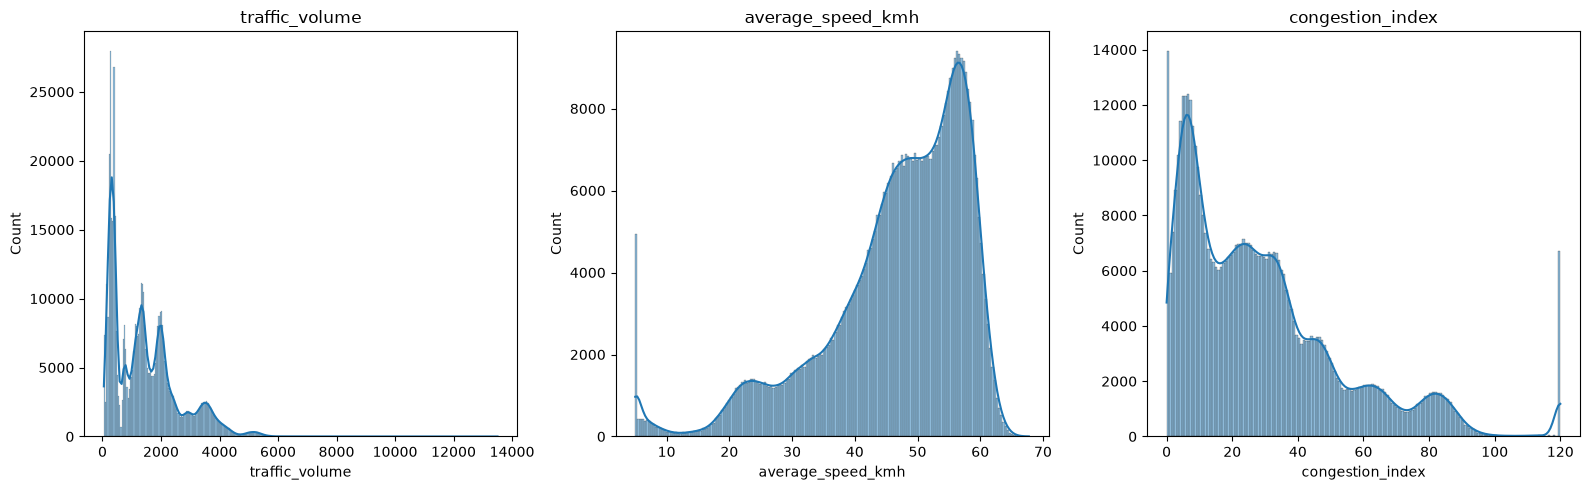

In [90]:
normal_cols = ['traffic_volume', 'average_speed_kmh', 'congestion_index']
inflated_cols = ['accident_count', 'road_incident_count', 'special_event_impact', 'weather_impact_score']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(normal_cols):
    sns.histplot(traffic_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

#### Insights: Normal-Range Traffic Metrics — traffic_volume, average_speed_kmh, congestion_index

- `traffic_volume` ranges widely (47 to 13,504) with the mean (1,443.5) sitting noticeably 
  above the median (1,287) — right-skewed, consistent with a handful of very high-volume 
  peak-hour readings pulling the tail up. Worth revisiting once we split by `rush_hour_flag` 
- `average_speed_kmh` is close to symmetric but slightly left-skewed (mean 46.56 < median 
  49.09) — the tail toward low speeds runs longer than the tail toward high speeds, which 
  matches real driving: speed can collapse toward zero in heavy congestion, but it has a 
  hard physical ceiling near free-flow speed (max recorded is only 67.76 km/h).
- `congestion_index` is right-skewed (mean 29.09 > median 23.79) — most readings sit at 
  low-to-moderate congestion, with a tail of severe-congestion events pulling the mean up. 
  One thing to flag: the max value is 120, exceeding the 0-100 range you'd normally expect 
  from a "normalized" index — will be revisited with a closer look in the outlier step.

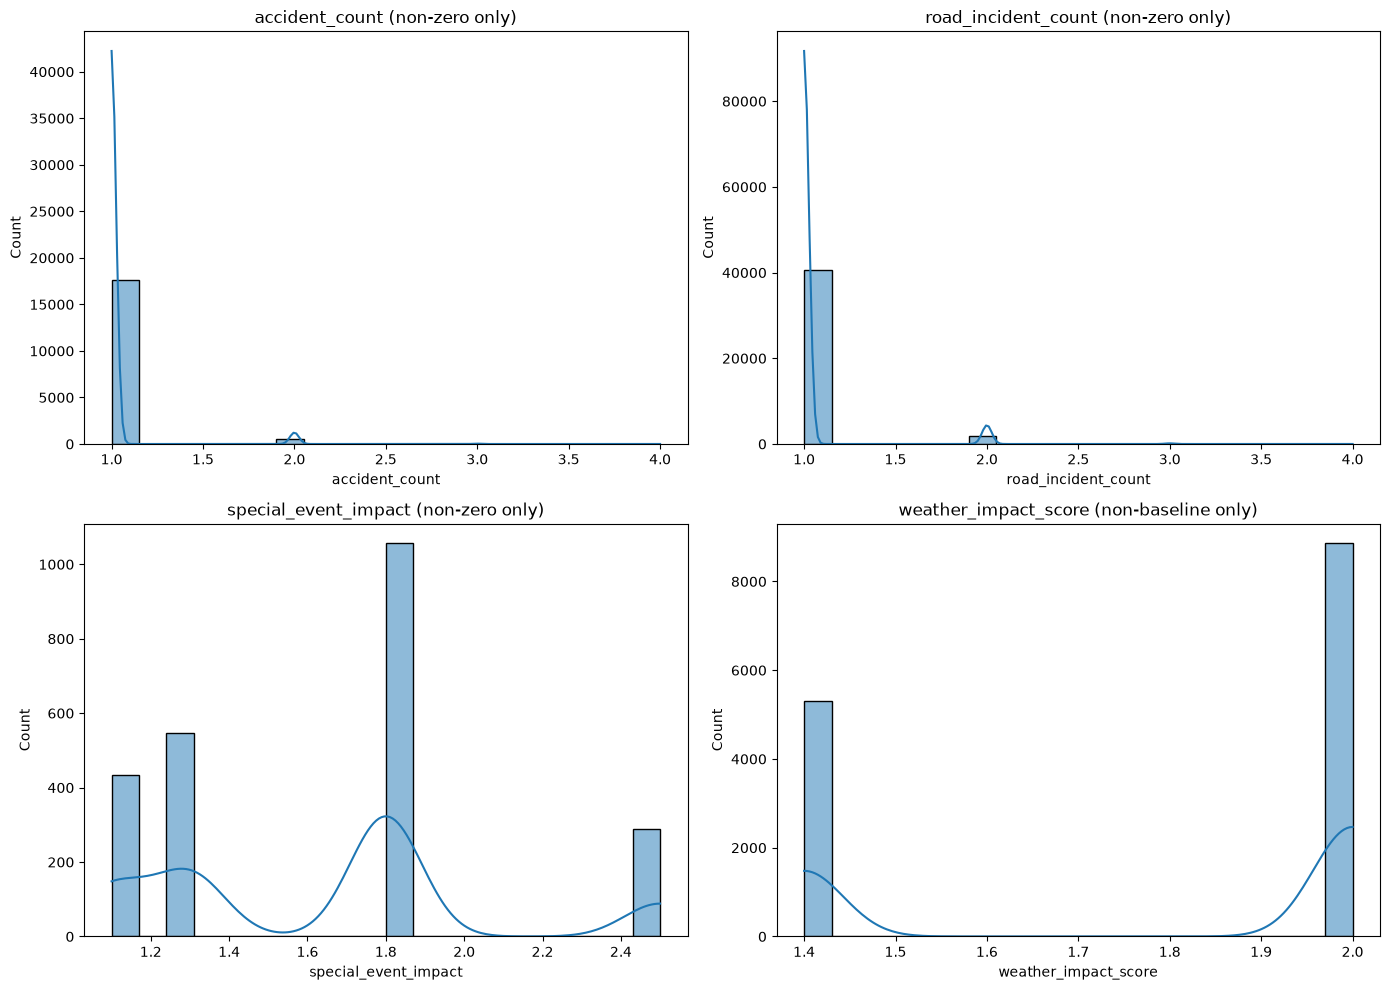

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(['accident_count', 'road_incident_count', 'special_event_impact']):
    sns.histplot(traffic_clean[traffic_clean[col] > 0][col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f'{col} (non-zero only)')

sns.histplot(traffic_clean[traffic_clean['weather_impact_score'] > 1.0]['weather_impact_score'], 
             kde=True, bins=20, ax=axes[3])
axes[3].set_title('weather_impact_score (non-baseline only)')

plt.tight_layout()

#### Insights: Zero/One-Inflated Traffic Metrics — accident_count, road_incident_count, special_event_impact, weather_impact_score

- `accident_count` and `road_incident_count` are almost entirely zero — every quartile up 
  to the 75th percentile reads 0, and only the mean (0.036 and 0.086 respectively) and max 
  (4 for both) reveal that accidents/incidents happen at all. These behave as rare events 
  layered on top of normal traffic flow, not a continuously varying quantity
- `special_event_impact` follows the same pattern even more extremely — with a mean of just 
  0.007 and quartiles all at 0, well over 99% of rows show no event effect, spiking up to 
  2.5 on the rare day a real event hits a district.
- `weather_impact_score` is the mirror image: instead of zero-inflated, it's **baseline-
  inflated at 1.0** — confirmed at 97.28% of rows. A value of 1.0 reads as "no weather 
  effect" (a 1× multiplier on traffic), so only ~2.72% of readings show weather actually 
  distorting traffic conditions (mean 1.02, max 2.0). Same underlying shape as the 
  accident/incident columns, just recentered at 1 instead of 0.

<a id="s3-4"></a>

### 3.4 Outliers and the decision not to remove them

*Why we run this.* Standard screening, read with the two-family split of §3.3 in mind. The question
is never "does the IQR rule flag these?" but "is what it flags an error or a real event?"

- **`iqr_outliers` loop** — flagged counts per column.
- **`skew()`** — the direction of the tail, which explains *why* each column produces the outlier
  count it does.
- **Boxplots of the normal-range columns only** — a boxplot of a 96%-zero column is a flat line at
  zero with everything above it marked as an outlier, which is visually true and analytically
  useless.

In [92]:
for col in traffic_numeric_cols:
    n_out = len(iqr_outliers(traffic_clean[col]))
    print(f"{col}: \t{n_out} outliers ({n_out/len(traffic_clean)*100:.2f}%)")

traffic_volume: 	6596 outliers (1.27%)
average_speed_kmh: 	15904 outliers (3.05%)
congestion_index: 	13762 outliers (2.64%)
accident_count: 	18129 outliers (3.48%)
road_incident_count: 	42721 outliers (8.20%)
weather_impact_score: 	14164 outliers (2.72%)
special_event_impact: 	2326 outliers (0.45%)


In [93]:
# skewness: 0 -> symmetric distribution, +ve -> right skewed, -ve -> left skewed
traffic_clean[traffic_numeric_cols].skew()

traffic_volume           1.009649
average_speed_kmh       -1.240107
congestion_index         1.274971
accident_count           5.481848
road_incident_count      3.464529
weather_impact_score      6.72413
special_event_impact    16.381743
dtype: Float64

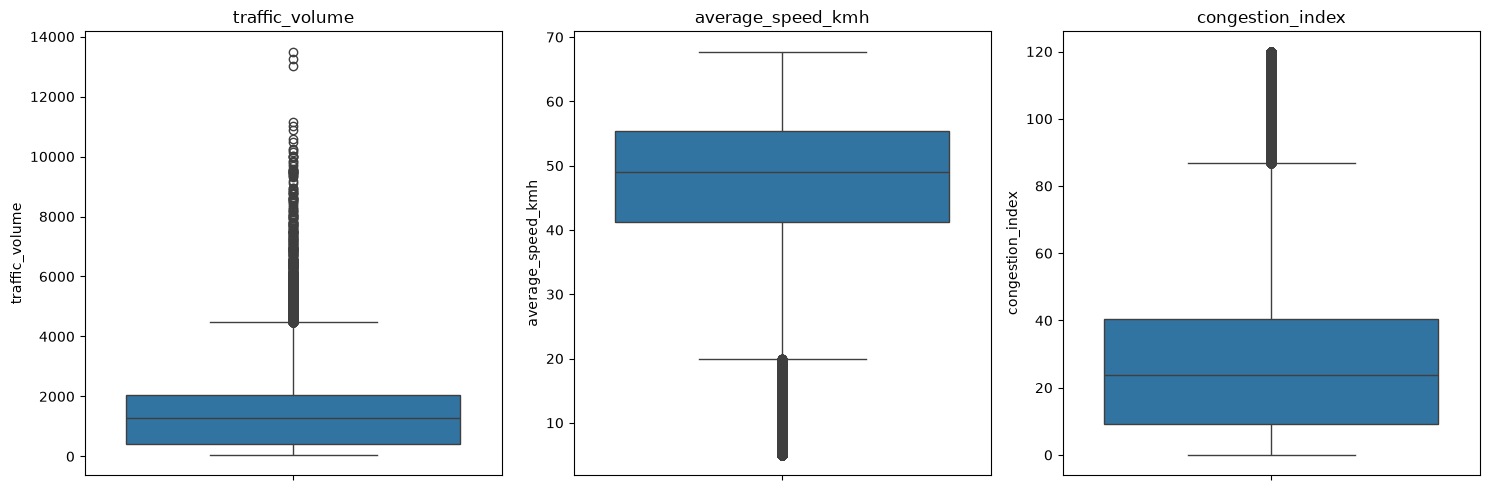

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(normal_cols):
    sns.boxplot(y=traffic_clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

#### Insights: Distribution, Outliers & Handling Decision — traffic.csv Numeric Metrics

**What the extremes represent operationally:**
- `traffic_volume`'s right-skew (1.01) and small outlier tail (1.27%, up to 13,504) 
  correspond to the city's genuine peak-load hours 
- `average_speed_kmh`'s left-skew (-1.24) tells the same story from the opposite side: 
  speed has nowhere to spike upward (free-flow is a hard ceiling), but it can collapse 
  toward gridlock, and 3.05% of readings do — likely the same hours driving the volume 
  and congestion tails above.
- `congestion_index`'s right-skew (1.27) reinforces this: 2.64% of readings sit in 
  severe-congestion territory (up to 120 on the index), and these three tails almost 
  certainly overlap in time and district — worth confirming directly in validating flags section
- `accident_count`, `road_incident_count`, `weather_impact_score`, and 
  `special_event_impact` behave as rare-event indicators layered on top of routine 
  traffic (90%+ of rows at zero/baseline). Their "outliers" (2.72%–8.20%) aren't 
  anomalies — they're every accident, incident, weather disruption, and city event 
  the dataset actually recorded.

**Decision:** No values are removed or capped anywhere in `traffic.csv`. Across every 
numeric column, what IQR flags as an "outlier" is either a genuine peak-congestion event 
(the first three columns) or the rare-but-real operational event a monitoring system 
exists to catch (the remaining four). Removing either would strip out the signal that 
matters most for downstream traffic-management analysis — rush-hour severity, 
whether safety flags actually correspond to worse conditions, and whether road 
capacity holds up under real demand .

<a id="s3-5"></a>

### 3.5 The daily traffic cycle

*Why we run this.* Traffic is fundamentally a time-of-day phenomenon. Averaging each metric by hour
of day across three years gives the city's characteristic daily curve, and sets up the flag
validation in §3.6 — we need to know when rush hour actually is before checking whether
`rush_hour_flag` fires then.

- **`.dt.hour` + `groupby('hour')`** — the 24-point daily profile for volume, speed and congestion.
- **Three separate subplots, not one** — volume runs in the thousands while speed and congestion are
  two-digit numbers. On a shared axis the latter two would flatten into straight lines at the
  bottom; on separate axes each shape is readable.
- **Means grouped by `rush_hour_flag` and by `weekend_flag`** — the same metrics split by the two
  time flags, as a first look before validating them properly.

In [95]:
traffic_clean['hour'] = traffic_clean['timestamp'].dt.hour
hourly_avg = traffic_clean.groupby('hour')[['traffic_volume', 'average_speed_kmh', 'congestion_index']].mean()
hourly_avg

,traffic_volume,average_speed_kmh,congestion_index
hour,,,
0,303.102842,56.669915,6.308714
1,303.011289,56.818352,6.245673
2,302.994791,56.878504,6.236565
3,302.873415,56.898402,6.256957
4,302.698635,56.821363,6.217975
5,302.60538,56.837746,6.228804
6,1516.166697,45.802426,30.841079
7,2463.56303,37.787785,48.914010
8,2464.05775,37.683016,48.998235


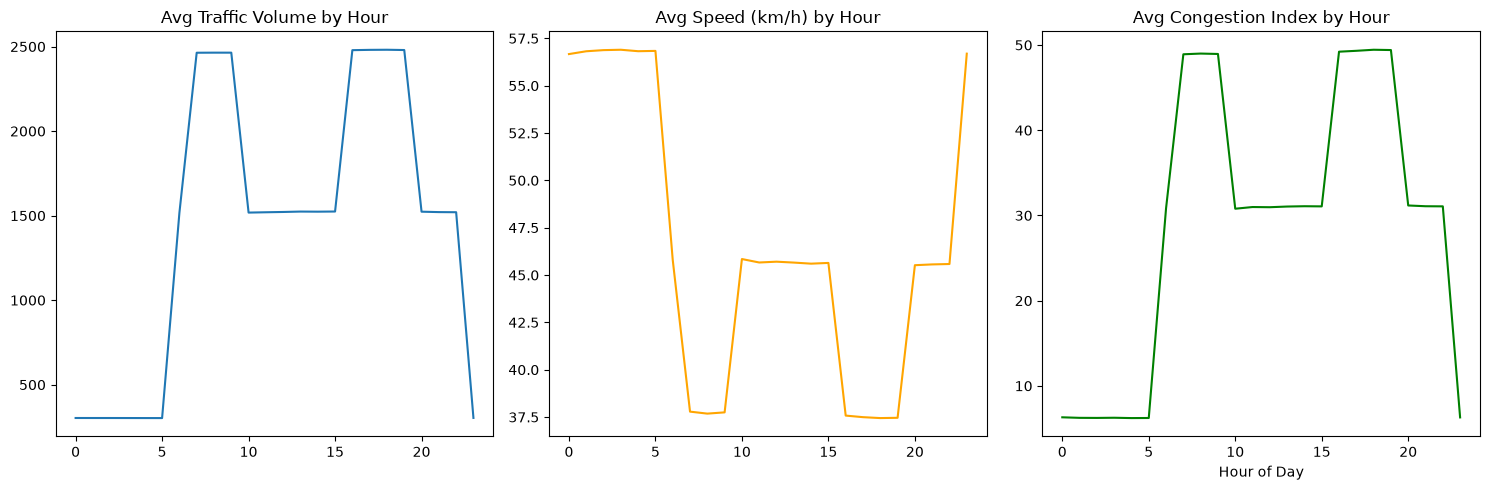

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(hourly_avg.index, hourly_avg['traffic_volume'])
axes[0].set_title('Avg Traffic Volume by Hour')

axes[1].plot(hourly_avg.index, hourly_avg['average_speed_kmh'], color='orange')
axes[1].set_title('Avg Speed (km/h) by Hour')

axes[2].plot(hourly_avg.index, hourly_avg['congestion_index'], color='green')
axes[2].set_title('Avg Congestion Index by Hour')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()

In [97]:
rush_hour_traffic = traffic_clean.groupby('rush_hour_flag')[['traffic_volume', 'average_speed_kmh', 'congestion_index']].mean()
rush_hour_traffic
# the traffic_volume mean for the rush hour (2,996) is higher than any single hour's raw average (max was 2,481 at hour 18)

,traffic_volume,average_speed_kmh,congestion_index
rush_hour_flag,,,
0,1034.732669,50.102614,21.127628
1,2996.007572,33.100668,59.323383


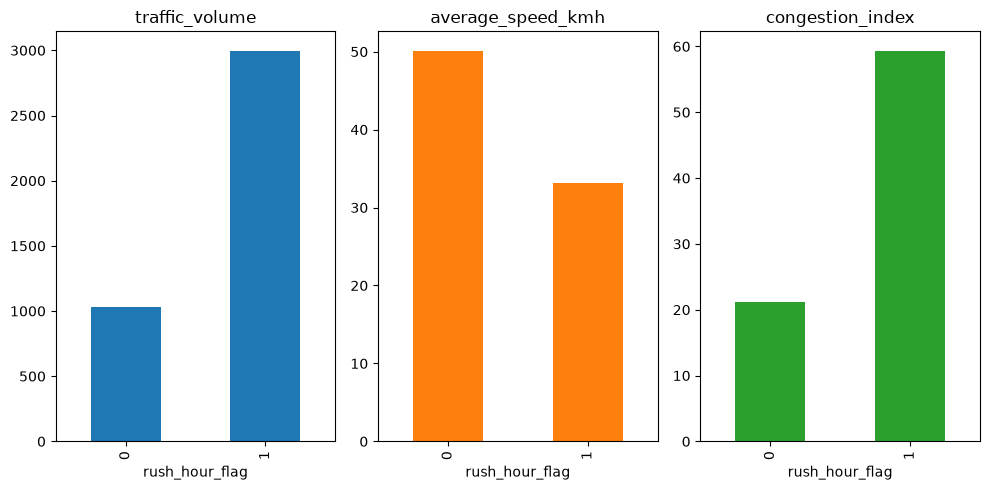

In [98]:
rush_hour_traffic.plot(kind='bar', figsize=(10,5), subplots=True, layout=(1,3), legend=False)
plt.tight_layout()

In [99]:
weekend_traffic = traffic_clean.groupby('weekend_flag')[['traffic_volume', 'average_speed_kmh', 'congestion_index']].mean()
weekend_traffic

,traffic_volume,average_speed_kmh,congestion_index
weekend_flag,,,
0,1663.956637,44.618888,33.426221
1,891.896513,51.413655,18.234573


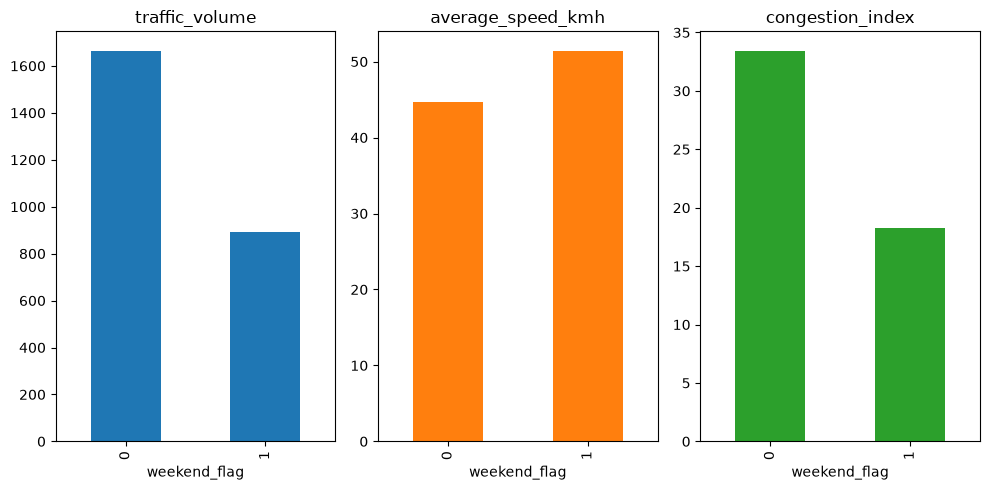

In [100]:
weekend_traffic.plot(kind='bar', figsize=(10,5), subplots=True, layout=(1,3), legend=False)
plt.tight_layout()

<a id="s3-6"></a>

### 3.6 Flag validation: rush hour, weekend, accident

*Why we run this.* Three flags, three different questions — and, as it turns out, three different
verdicts. For each one we try to recover the rule that generated it, then check whether the flag is
operationally meaningful.

- **`groupby('hour')['rush_hour_flag'].mean()`** — reconstructs the flag's time window. A mean of
  0.715 within hours 7–9 / 16–19 and 0 outside them says the window is right but the flag does not
  always fire inside it.
- **`crosstab(rush_hour_flag, weekend_flag, normalize='index')`** — tests the second half of the
  suspected rule: is rush hour weekday-only? (It is: 100%.)
- **Congestion boxplot by `rush_hour_flag`** — whether the flag, when it does fire, marks genuinely
  worse conditions.
- **`groupby('day_of_week')['weekend_flag'].mean()`** — recovers the weekend rule exactly
  (Saturday = 5, Sunday = 6).
- **Volume boxplot by `weekend_flag`** — the operational difference between weekday and weekend.
- **`crosstab(accident_flag, accident_count > 0)`** — a direct 1-to-1 consistency test between the
  flag and its underlying counter.
- **Means grouped by `accident_flag`** — whether accident hours look different in volume, speed and
  congestion.

In [101]:
# does rush_hour_flag=1 line up exactly with hours 7-9 and 16-19?
traffic_clean.groupby('hour')['rush_hour_flag'].mean()
# this means that 71.5% of all rows, rush_hour_flag=1 is set during hours 7-9 and 16-19, but not always. 
# There are some cases where rush_hour_flag=1 is set outside of those hours, and some cases where rush_hour_flag= 0 during those hours

hour
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
5          0.0
6          0.0
7      0.71505
8     0.714661
9     0.714674
10         0.0
11         0.0
12         0.0
13         0.0
14         0.0
15         0.0
16    0.714648
17    0.714338
18    0.714305
19    0.714687
20         0.0
21         0.0
22         0.0
23         0.0
Name: rush_hour_flag, dtype: Float64

In [102]:
# is rush_hour_flag=1 restricted to weekdays only?
pd.crosstab(traffic_clean['rush_hour_flag'], traffic_clean['weekend_flag'], normalize='index')
# we did this to know the exact definition of rush hours, is it for weekdays only or for weekends too
# The result shows that 100% of rush_hour_flag=1 rows are on weekdays (weekend_flag=0), and 0% are on weekends (weekend_flag=1). 

weekend_flag,0,1
rush_hour_flag,,
0,0.639342,0.360658
1,1.000000,0.000000


Text(0.5, 1.0, 'Congestion Index: Rush Hour Flagged vs Not')

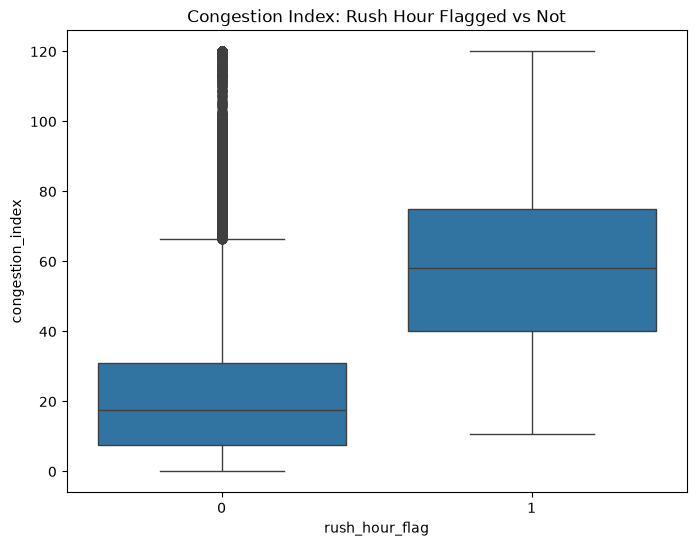

In [103]:
plt.figure(figsize=(8,6))
sns.boxplot(data=traffic_clean, x='rush_hour_flag', y='congestion_index')
plt.title('Congestion Index: Rush Hour Flagged vs Not')

- **`rush_hour_flag`** is directionally reliable but not deterministic. It never fires 
  outside hours 7-9/16-19 and never fires on a weekend — so it correctly captures weekday
  But within that it's only active ~71.5% of the time, meaning 
  roughly 3 in 10 weekday rush-hour readings go unflagged for reasons the data itself 
  doesn't explain. Where it IS active, though, it's a strong signal: median congestion 
  more than triples (58 vs 17) compared to non-flagged hours. The takeaway for the business: 
  trust this flag as a *marker of reliably bad conditions*, but not as a complete inventory 
  of all bad conditions — a wide spread of high-congestion outliers (up to 120) still shows 
  up even when the flag is off, meaning other forces (accidents, weather, one-off events) 
  are driving congestion spikes independently of the clock.

In [104]:
traffic_clean['day_of_week'] = traffic_clean['timestamp'].dt.dayofweek  # Monday=0 ... Sunday=6
traffic_clean.groupby('day_of_week')['weekend_flag'].mean()
# this shows that weeken flag is for saturday and sunday (5,6)

day_of_week
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    1.0
6    1.0
Name: weekend_flag, dtype: Float64

Text(0.5, 1.0, 'Traffic Volume: Weekend Flagged vs Not')

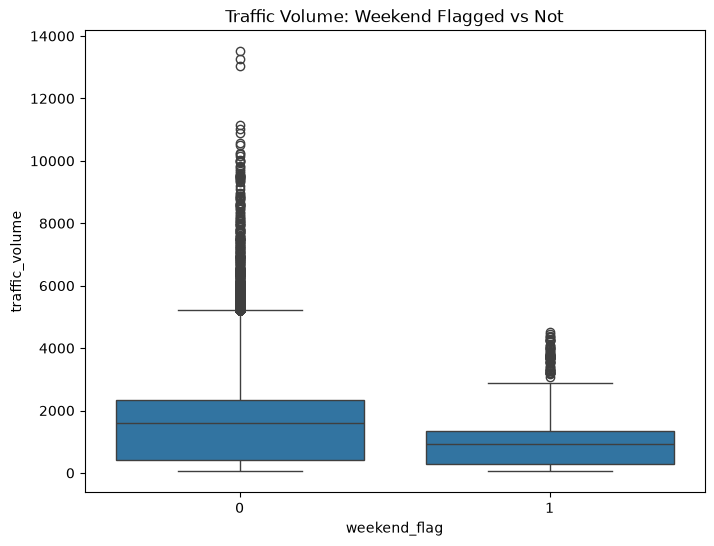

In [105]:
plt.figure(figsize=(8,6))
sns.boxplot(data=traffic_clean, x='weekend_flag', y='traffic_volume')
plt.title('Traffic Volume: Weekend Flagged vs Not')

- **`weekend_flag`** is a fully reliable, deterministic label — it matches `day_of_week` 
  with zero exceptions (Mon-Fri always 0, Sat-Sun always 1). Operationally, weekends aren't 
  just quieter on average (median volume ~900 vs ~1,550 on weekdays) — they essentially never 
  produce the extreme traffic volumes weekdays do (outlier ceiling ~4,500 vs the dataset 
  max of 13,504 on weekdays). 

In [106]:
pd.crosstab(traffic_clean['accident_flag'], traffic_clean['accident_count'] > 0)

accident_count,False,True
accident_flag,,
0,502693,0
1,0,18129


In [107]:
traffic_clean.groupby('accident_flag')[['traffic_volume', 'average_speed_kmh', 'congestion_index']].mean()

,traffic_volume,average_speed_kmh,congestion_index
accident_flag,,,
0,1428.753154,46.805763,28.653569
1,1853.784268,39.707056,41.171196


- **`accident_flag`** is fully reliable — a perfect 1-to-1 match with `accident_count > 0`, 
  no ambiguity anywhere. It's also operationally meaningful: flagged rows run 30% higher 
  volume, 15% lower speed, and 44% higher congestion than unflagged rows.

**Bottom line:** two of the three flags (`weekend_flag`, `accident_flag`) can be trusted at 
face value for any downstream segmentation. `rush_hour_flag` should be treated as a strong 
but incomplete proxy for high-congestion conditions — useful for isolating the reliably 
bad commute windows, but not a substitute for congestion_index itself when the goal is 
catching *every* high-congestion event.

<a id="s3-7"></a>

### 3.7 Weekday vs weekend structure

*Why we run this.* §3.6 established that rush hour is weekday-only *by definition*. This section
checks it *empirically* from the raw volumes: if we split the daily curve by weekday and weekend, do
weekends actually lack a rush-hour peak, or are they just a scaled-down version of the same shape?

`groupby(['hour','weekend_flag']).unstack()` produces one column per group so both curves can be
drawn on the same axes and compared directly.

In [108]:
hourly_by_weekend = traffic_clean.groupby(['hour', 'weekend_flag'])['traffic_volume'].mean().unstack()
hourly_by_weekend.columns = ['Weekday', 'Weekend']
hourly_by_weekend

,Weekday,Weekend
hour,,
0,331.752949,231.385124
1,331.570287,231.406109
2,331.535415,231.553367
3,331.333204,231.627422
4,331.31407,231.116136
5,331.32267,230.869986
6,1658.551751,1160.215541
7,2983.041398,1159.991748
8,2984.381917,1160.852043


Text(0.5, 0, 'Hour of Day')

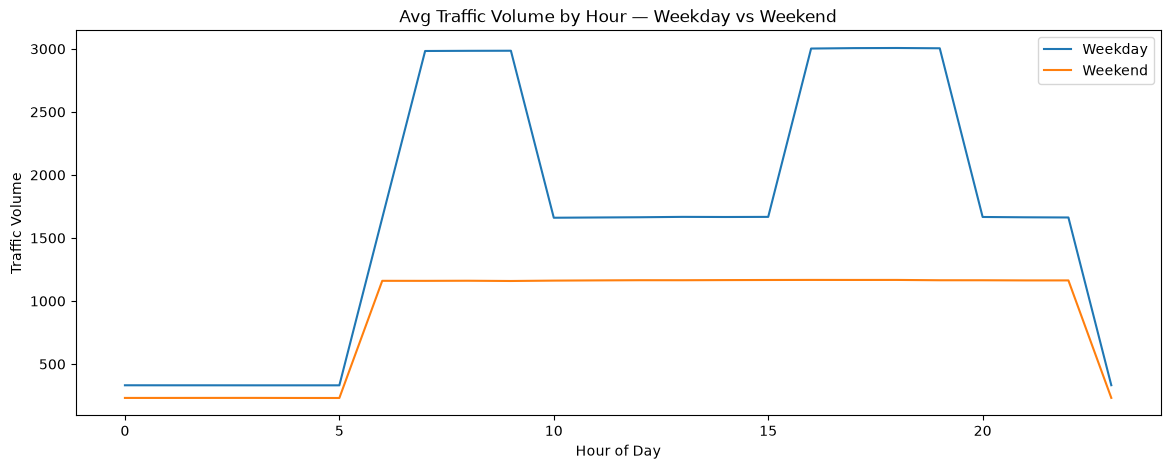

In [109]:
hourly_by_weekend.plot(figsize=(14,5))
plt.title('Avg Traffic Volume by Hour — Weekday vs Weekend')
plt.ylabel('Traffic Volume')
plt.xlabel('Hour of Day')

#### Insights: Weekday vs Weekend Traffic Cycle

- Weekdays retain a sharp double-peak commuter structure — a night trough (~330), a 
  midday plateau (~1,660), and two rush spikes (~2,985–3,006) at the morning (7-9) and 
  evening (16-19) commute windows.
- Weekends show a fundamentally different shape, not just a scaled-down version of the 
  weekday one: the curve is essentially **flat across the entire daytime** (~1,160-1,167 
  from hour 6 through hour 22), with no rush-hour bump at all. The 7-9 and 16-19 windows 
  aren't even mildly elevated relative to the rest of the day.
- This directly confirms the earlier flag validation from a different angle: "rush hour" 
  as a concept is exclusively tied to weekday commuting. Any capacity planning or 
  congestion-mitigation strategy built around rush-hour timing should apply strictly to 
  weekdays — using it on weekends would be solving for a peak that doesn't exist.

<a id="s3-8"></a>

### 3.8 How the traffic variables relate to each other

*Why we run this.* The heatmap answers whether the flow metrics are three independent facts or three
views of one, and gives a first (deliberately incomplete) reading on the rare-event columns.

**Read the rare-event rows of this matrix with caution.** Pearson correlation measures linear
co-movement, which is close to meaningless for a column that is zero 96% of the time — the
coefficient gets dominated by the mass of zeros. The near-zero correlation between `accident_count`
and `congestion_index` is a limitation of the tool, not evidence that accidents do not affect
congestion; §3.6's group means answer that question properly.

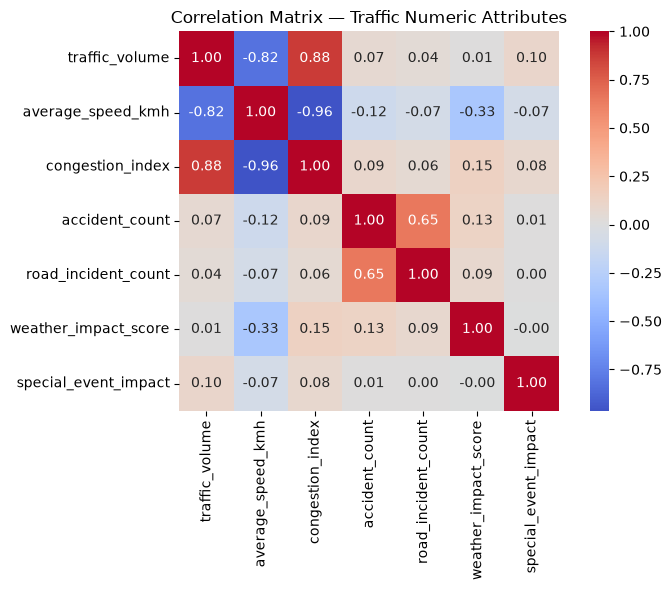

In [110]:
traffic_corr_matrix = traffic_clean[traffic_numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(traffic_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Traffic Numeric Attributes')
plt.tight_layout()

#### Insights: Correlation Matrix — Traffic Numeric Attributes

**Congestion, volume, and speed move as one system:**
- `congestion_index` and `average_speed_kmh` show a near-perfect inverse relationship 
  (r=-0.96). Higher congestion almost mechanically means slower traffic.
- `traffic_volume` reinforces the same story from a third angle: strongly positive with 
  congestion (r=0.88), strongly negative with speed (r=-0.82). All three variables are 
  effectively describing one underlying phenomenon — how busy the road is. This validates `congestion_index` as a reliable derived 
  metric

**Accidents and incidents cluster together, but correlate weakly with congestion:**
- `accident_count` and `road_incident_count` show a real, moderate-strong relationship 
  (r=0.65) — whatever conditions produce one tend to produce the other at the same time, 
  suggesting they 're symptoms of the same risky driving conditions.
- Both show only a weak linear correlation with `congestion_index` (0.09 and 0.06) and 
  `traffic_volume` (0.07 and 0.04). Taken at face value this reads as "accidents barely 
  affect congestion" 
  
**Weather has a real but modest speed effect; special events show no linear signal:**
- `weather_impact_score` correlates moderately with `average_speed_kmh` (r=-0.33) — bad 
  weather measurably slows traffic — but only weakly with `congestion_index` (r=0.15), 
  suggesting weather acts more as a speed/safety hazard than a volume-driver.
- `special_event_impact` shows essentially no linear relationship with anything (r=0.00 
  to 0.10) — but given it's also a rare-event, heavily-zero-inflated column

**Bottom line:** the core traffic-flow relationship (volume-congestion-speed) is strong, 
consistent, and safe to build downstream analysis on directly. The rare-event columns 
(accidents, incidents, special events) need to be evaluated through group comparisons 
rather than correlation coefficients — their true operational impact is likely understated 
by this heatmap alone.

<a id="s3-9"></a>

### 3.9 District context and weather validation

*Why we run this.* Two cross-table questions that `traffic.csv` cannot answer alone:

**(a) Is congestion a supply problem or a demand problem?** `road_capacity_index` lives in
`districts.csv`, so we merge, aggregate traffic to district level (20 rows — the level at which a
static district property can be correlated meaningfully), and test capacity against congestion.

**(b) Is `weather_impact_score` trustworthy?** It claims to quantify weather disruption, so we join
the real weather measurements for the same district-hour and check. Note the merge here is an
`inner` join on both `timestamp` *and* `district_id`, and deliberately pulls only the four weather
columns the question needs — merging everything would double the frame's width for no benefit.

- **Merge + null check** — confirm every traffic row found its district.
- **District-level aggregation and correlation** — capacity vs congestion, speed and volume.
- **`regplot`** — the shape behind the capacity/congestion correlation.
- **Traffic–weather merge, correlations, and storm-flag group mean** — the three checks on
  `weather_impact_score`.
- **Averages by `district_type`** — whether zoning type shows real traffic differences.

In [111]:
traffic_merged = traffic_clean.merge(districts, on='district_id', how='left')
traffic_merged.shape

(520822, 31)

In [112]:
traffic_merged.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,...,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh,margin_ratio,leftover_capacity_mwh
0,2023-01-01,D01,441,57.620606,6.675445,0,0,0,0,1,...,5,80,95,400,1.5,0.7,23076.923077,617.454012,0.352178,217.454012
1,2023-01-01,D20,161,54.801388,7.794341,0,0,0,0,1,...,60,55,30,190,-0.5,1.1,5000.000000,289.333384,0.343318,99.333384
2,2023-01-01,D06,234,59.582867,5.674948,0,0,0,0,1,...,20,55,60,200,0.2,1.0,14000.000000,297.799726,0.328408,97.799726
3,2023-01-01,D04,296,54.826364,15.872370,0,0,0,0,1,...,30,60,75,250,-0.5,1.1,14400.000000,399.916155,0.374869,149.916155
4,2023-01-01,D18,241,55.734349,8.085675,0,0,0,0,1,...,30,60,75,180,-0.8,1.3,13636.363636,284.614039,0.367565,104.614039


In [113]:
traffic_merged[['road_capacity_index', 'district_type']].isna().sum()

road_capacity_index    0
district_type          0
dtype: int64

In [114]:
district_traffic = traffic_merged.groupby('district_id', as_index=False)[
    ['traffic_volume', 'average_speed_kmh', 'congestion_index']
].mean()

district_traffic = district_traffic.merge(
    districts[['district_id', 'road_capacity_index', 'district_type']], on='district_id'
)

district_traffic.sort_values('road_capacity_index').reset_index(drop=True)


,district_id,traffic_volume,average_speed_kmh,congestion_index,road_capacity_index,district_type
0,D11,1723.262274,30.065882,66.338047,30,Mixed
1,D13,353.711335,54.442933,11.422069,40,Recreation
2,D19,977.012364,47.150766,27.748484,45,Residential
3,D09,1636.395669,41.002027,41.573453,50,Mixed
4,D20,1027.697258,48.882797,23.862178,55,Residential
5,D06,1408.771513,44.965595,32.659101,55,Residential
6,D07,1828.391171,42.256855,38.715357,60,Residential
7,D04,1945.859062,41.129556,41.261986,60,Residential
8,D18,1481.074236,45.503518,31.475648,60,Mixed
9,D05,1723.528511,44.448070,33.807968,65,Residential


In [115]:
district_traffic[['road_capacity_index', 'traffic_volume', 'average_speed_kmh', 'congestion_index']].corr()

,road_capacity_index,traffic_volume,average_speed_kmh,congestion_index
road_capacity_index,1.000000,0.236388,0.466788,-0.468186
traffic_volume,0.236388,1.000000,-0.683071,0.681429
average_speed_kmh,0.466788,-0.683071,1.000000,-0.999994
congestion_index,-0.468186,0.681429,-0.999994,1.000000


Text(0.5, 1.0, 'Road Capacity Index vs Avg Congestion Index (per district)')

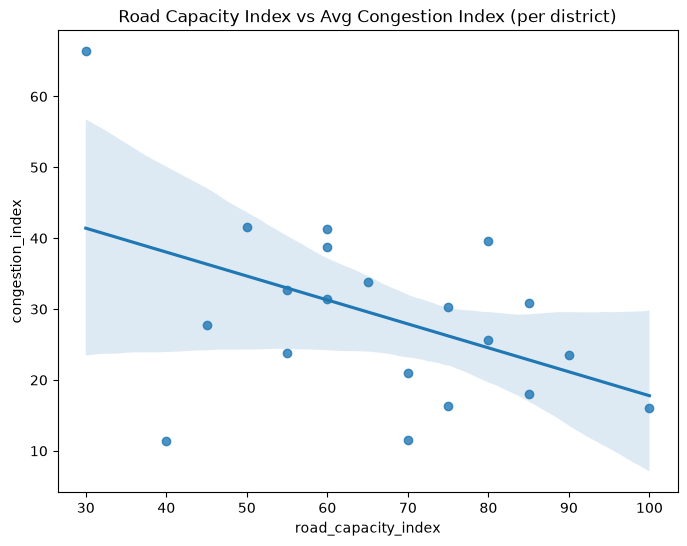

In [116]:
plt.figure(figsize=(8,6))
sns.regplot(data=district_traffic, x='road_capacity_index', y='congestion_index')
plt.title('Road Capacity Index vs Avg Congestion Index (per district)')

**Road capacity partially explains congestion, but demand dominates:**
- `road_capacity_index` correlates moderately with `congestion_index` (r=-0.47) and 
  `average_speed_kmh` (r=0.47) at the district level — real, but well short of the 
  near-perfect relationship congestion has with speed itself (r≈-1.00). Capacity is 
  one input to congestion, not the deciding factor: D01 has a comparatively high 
  capacity index (80) yet still runs high congestion (39.6), because it also carries 
  the highest traffic volume in the city (2,489). Infrastructure planning based on 
  capacity alone would miss the demand side of the equation.

In [117]:
traffic_weather = traffic_merged.merge(
    weather_clean[['timestamp', 'district_id', 'rainfall_mm', 'wind_speed_kmh', 'storm_flag', 'heavy_rain_flag']],
    on=['timestamp', 'district_id'], how='inner'
)
traffic_weather[['rainfall_mm', 'wind_speed_kmh']].isna().sum()

rainfall_mm       0
wind_speed_kmh    0
dtype: int64

In [118]:
traffic_weather.shape

(514316, 35)

In [119]:
traffic_weather.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,...,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh,margin_ratio,leftover_capacity_mwh,rainfall_mm,wind_speed_kmh,storm_flag,heavy_rain_flag
0,2023-01-01,D01,441,57.620606,6.675445,0,0,0,0,1,...,1.5,0.7,23076.923077,617.454012,0.352178,217.454012,0.0,2.755095,0,0
1,2023-01-01,D20,161,54.801388,7.794341,0,0,0,0,1,...,-0.5,1.1,5000.000000,289.333384,0.343318,99.333384,0.0,6.849491,0,0
2,2023-01-01,D06,234,59.582867,5.674948,0,0,0,0,1,...,0.2,1.0,14000.000000,297.799726,0.328408,97.799726,0.0,7.956170,0,0
3,2023-01-01,D04,296,54.826364,15.872370,0,0,0,0,1,...,-0.5,1.1,14400.000000,399.916155,0.374869,149.916155,0.0,6.990799,0,0
4,2023-01-01,D18,241,55.734349,8.085675,0,0,0,0,1,...,-0.8,1.3,13636.363636,284.614039,0.367565,104.614039,0.0,7.920973,0,0


In [120]:
traffic_weather[['weather_impact_score', 'rainfall_mm', 'wind_speed_kmh']].corr()

,weather_impact_score,rainfall_mm,wind_speed_kmh
weather_impact_score,1.000000,0.714314,0.672924
rainfall_mm,0.714314,1.000000,0.415268
wind_speed_kmh,0.672924,0.415268,1.000000


In [121]:
traffic_weather.groupby('storm_flag')['weather_impact_score'].mean()

storm_flag
0    1.004149
1    2.000000
Name: weather_impact_score, dtype: float64

**`weather_impact_score` is a trustworthy, deliberately-designed metric:**
- Strong correlation with both `rainfall_mm` (0.71) and `wind_speed_kmh` (0.67) confirms 
  it genuinely reflects real weather conditions, not an arbitrary score.
- Storm-flagged rows average exactly 2.0 showing the metric was 
  explicitly designed to max out under severe weather. This score can be used downstream 
  as a reliable weather-severity proxy without needing to re-derive it from raw weather 
  data each time.

In [122]:
traffic_by_district_type = traffic_merged.groupby('district_type')[
    ['traffic_volume', 'average_speed_kmh', 'congestion_index']
].mean()
traffic_by_district_type.sort_values('congestion_index', ascending=False)

,traffic_volume,average_speed_kmh,congestion_index
district_type,,,
Mixed,1613.590843,38.857183,46.462278
Residential,1485.252068,44.805234,33.010016
Commercial,1917.205016,46.162404,29.972338
Public Services,1148.553282,50.139815,21.010775
Transport,1252.782892,52.330975,16.088147
Recreation,776.698862,52.937348,14.749220
Industrial,789.713194,53.301042,13.952075


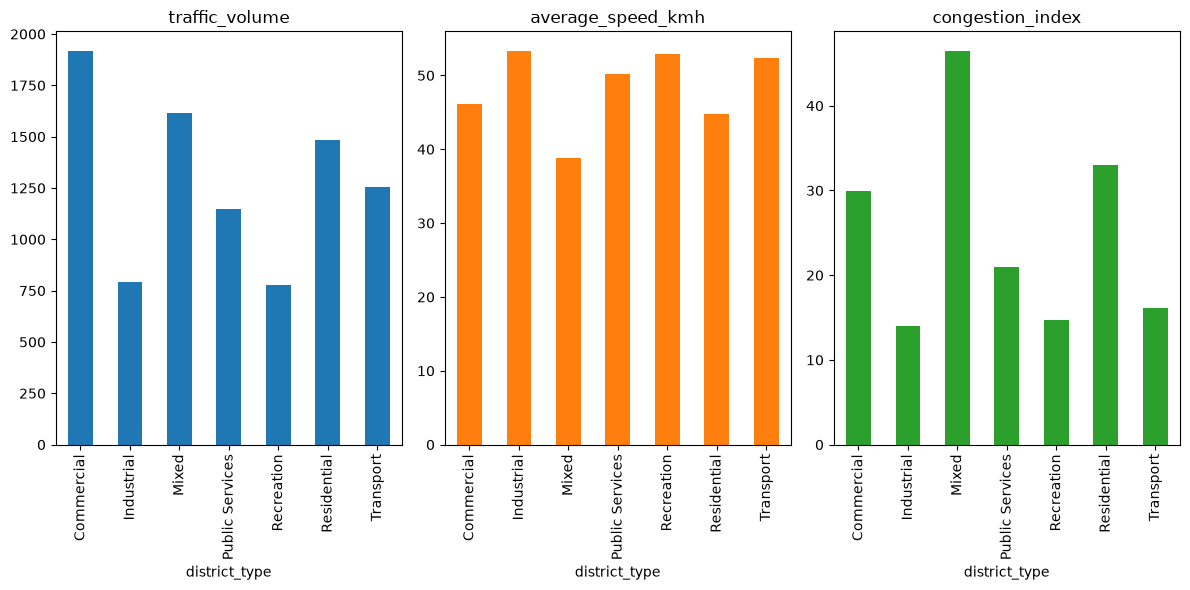

In [123]:
traffic_by_district_type.plot(kind='bar', figsize=(12,6), subplots=True, layout=(1,3), legend=False)
plt.tight_layout()

**District type shows real traffic differences, with one caveat:**
- Mixed districts show the highest average congestion (46.5) and lowest average speed 
  (38.9 km/h) of any type, ahead of Residential (33.0) and Commercial (30.0) — despite 
  Commercial carrying more raw volume (1,917 vs Mixed's 1,614). This suggests Mixed 
  zoning's congestion issue is more about road/traffic-flow design than sheer car count.
- Caveat: only 3 districts fall into the Mixed category, and their individual congestion 
  values range widely (31.5 to 66.3) — this average is heavily influenced by a single 
  high-congestion outlier (D11) rather than reflecting a consistent citywide pattern 
  across many Mixed districts. 
- Industrial and Recreation districts are the least congested (14.0 and 14.7) and 
  fastest-moving (53.3 and 52.9 km/h) — consistent with lower population density and 
  less commuter-driven demand in these zones.

**Bottom line:** congestion in this city is primarily a demand-driven phenomenon 
(traffic-volume, time-of-day, weekday commuting) with road capacity and district type acting 
as secondary, moderating factors rather than root causes.

<a id="s3-10"></a>

### 3.10 Chapter takeaways

**Volume, speed and congestion are one phenomenon, not three.** `congestion_index` and
`average_speed_kmh` correlate at −0.96, with `traffic_volume` reinforcing both (0.88 / −0.82). All
three describe how busy the road is, which also validates `congestion_index` as a sound derived
metric.

**The flags are pre-engineered, and they do not all hold up equally.** `weekend_flag` and
`accident_flag` are 100% reliable and can be trusted at face value. `rush_hour_flag` is
directionally correct — it never fires outside hours 7–9 / 16–19 and never on a weekend — but only
fires ~71.5% of the time inside its own window. Treat it as a marker of *reliably* bad conditions,
not as a complete inventory of all bad conditions.

**Rush hour is a weekday commuting phenomenon, confirmed twice.** Weekends are flat across the whole
day (~1,160 vehicles/hour from 06:00 to 22:00) with no bump at all, while weekdays show the
classic double peak (~3,000). Any capacity plan built around rush-hour timing applies to weekdays
only.

**Congestion is demand-driven, not capacity-driven.** `road_capacity_index` explains congestion only
moderately at district level (r = −0.47). D01 has a high capacity index (80) and still runs high
congestion (39.6) because it carries the city's highest volume. Building for capacity alone misses
the demand side.

**`weather_impact_score` is a trustworthy designed metric.** It correlates 0.71 with rainfall and
0.67 with wind speed, and hits exactly 2.0 — its ceiling — on every storm-flagged row. It can be
reused downstream as a weather-severity proxy without re-deriving it.

**No values were dropped or capped.** Every flagged extreme is either a real peak-traffic condition
or a genuine rare event.

> **Pitfalls caught in this chapter.**
>
> - **Fractional ticks on a count histogram read as a dtype bug.** The odd x-axis on the
>   accident/incident histograms was a `bins=20` artifact on discrete data — the columns were
>   correctly `Int64` all along. The fix is `discrete=True`, not a re-cast.
> - **A squashed boxplot read as a plotting error.** Speed and congestion looked flat next to
>   traffic volume purely because of a shared axis two orders of magnitude too large. Separate
>   subplots, one y-axis each.
> - **Nearly concluding "accidents don't affect congestion" from r = 0.09.** Pearson correlation is
>   the wrong instrument for a 96%-zero column; the real relationship lives in the group means.
>
> **A feature considered and rejected.** A `volume_capacity_ratio` column would test the demand-vs-
> capacity question more directly. It was left out because the district-level correlation plus the
> D01 counter-example already settled the question for this file's purposes.

---
<a id="ch4"></a>

## 4. `power_grid.csv` — electricity demand, generation and stress

[↑ back to contents](#toc)

**What this file is.** Hourly electricity data per district: how much power was drawn, how much came
from renewables, how strained the grid was, and whether an outage occurred.

**What each row carries.**

- **Demand and strain**: `electricity_demand_mwh`, `grid_load_percent`, `grid_stress_index`
- **Generation**: `solar_generation_mwh`, `wind_generation_mwh`,
  `total_renewable_generation_mwh`, `renewable_generation_percent`
- **Static reference**: `grid_capacity_mwh` — also present in `districts.csv`, which we test for
  redundancy
- **Outages**: `outage_flag`, `outage_duration_minutes`
- **Metadata**: `sensor_status`

**What makes this chapter distinctive.** Two of the renewable columns are zero-inflated for entirely
different physical reasons — solar because the sun sets, wind because wind is intermittent — and
separating those two mechanisms explains most of the odd distribution shapes in this file. It is
also where a U-shaped relationship (demand rising at both temperature extremes) first defeats a
straight correlation coefficient.

**Questions this chapter answers**

1. Does this file add information beyond `districts.csv`, or duplicate it?
2. Why is `grid_load_percent` bimodal when its skew is almost zero?
3. Are solar and wind intermittency linked, or independent?
4. Does demand track temperature, heat, or something else entirely?

<a id="s4-1"></a>

### 4.1 Loading, types, duplicates and a redundancy check

*Why we run this.* The standard opening, plus one check unique to this file. `grid_capacity_mwh`
appears both here and in `districts.csv`. Either it varies over time here (making it new
information) or it is a static copy (making it redundant). We test it directly rather than assume.

- **`head` / `shape` / `info` / `to_datetime`** — the inventory and the timestamp conversion.
- **Two duplicate checks** — on the composite key and on full rows.
- **The capacity comparison** — take the distinct `(district_id, grid_capacity_mwh)` pairs from this
  file, merge them against `districts.csv` with explicit suffixes, and difference the two columns. A
  difference of 0.0 for all 20 districts proves the column is a static copy carrying nothing new.

In [124]:
power_grid = pd.read_csv('data/power_grid.csv')

In [125]:
power_grid.head(10)

,timestamp,district_id,electricity_demand_mwh,grid_capacity_mwh,solar_generation_mwh,wind_generation_mwh,total_renewable_generation_mwh,renewable_generation_percent,grid_load_percent,grid_stress_index,outage_flag,outage_duration_minutes,sensor_status
0,2023-01-01 00:00:00,D01,249.143374,617.454012,0.0,0.0,0.0,0.0,40.350110,0.350110,0,0.0,Normal
1,2023-01-01 00:00:00,D02,306.555550,843.839288,0.0,0.0,0.0,0.0,36.328665,0.000000,0,0.0,Normal
2,2023-01-01 00:00:00,D03,451.257617,1306.398788,0.0,0.0,0.0,0.0,34.542103,0.000000,0,0.0,Normal
3,2023-01-01 00:00:00,D04,171.874027,399.916155,0.0,0.0,0.0,0.0,42.977515,2.977515,0,0.0,Normal
4,2023-01-01 00:00:00,D05,160.629531,342.471072,0.0,0.0,0.0,0.0,46.903095,6.903095,0,0.0,Normal
5,2023-01-01 00:00:00,D06,141.992722,297.799726,0.0,0.0,0.0,0.0,47.680609,7.680609,0,0.0,Normal
6,2023-01-01 00:00:00,D07,144.996481,307.549390,0.0,0.0,0.0,0.0,47.145755,7.145755,0,0.0,Normal
7,2023-01-01 00:00:00,D08,270.692062,749.944816,0.0,0.0,0.0,0.0,36.094931,0.000000,0,0.0,Normal
8,2023-01-01 00:00:00,D09,131.237398,288.050176,0.0,0.0,0.0,0.0,45.560603,5.560603,0,0.0,Normal
9,2023-01-01 00:00:00,D10,352.351755,976.210887,0.0,0.0,0.0,0.0,36.093815,0.000000,0,0.0,Normal


In [126]:
power_grid.shape

(526080, 13)

In [127]:
power_grid.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   timestamp                       526080 non-null  str    
 1   district_id                     526080 non-null  str    
 2   electricity_demand_mwh          520604 non-null  float64
 3   grid_capacity_mwh               520604 non-null  float64
 4   solar_generation_mwh            520604 non-null  float64
 5   wind_generation_mwh             520604 non-null  float64
 6   total_renewable_generation_mwh  520604 non-null  float64
 7   renewable_generation_percent    520604 non-null  float64
 8   grid_load_percent               520604 non-null  float64
 9   grid_stress_index               520604 non-null  float64
 10  outage_flag                     526080 non-null  int64  
 11  outage_duration_minutes         520604 non-null  float64
 12  sensor_status              

In [128]:
power_grid['timestamp'] = pd.to_datetime(power_grid['timestamp'], errors='coerce')

In [129]:
power_grid['timestamp'].dtype

dtype('<M8[us]')

In [130]:
power_grid.duplicated(subset=['timestamp', 'district_id']).sum()

np.int64(0)

In [131]:
power_grid.duplicated().sum()

np.int64(0)

In [132]:
capacity_compare = power_grid[['district_id', 'grid_capacity_mwh']].drop_duplicates().merge(
    districts[['district_id', 'grid_capacity_mwh']], on='district_id', suffixes=('_power', '_districts')
)
capacity_compare['diff'] = capacity_compare['grid_capacity_mwh_power'] - capacity_compare['grid_capacity_mwh_districts']
capacity_compare

# grid_capacity_mwh in power_grid is a redundant column

,district_id,grid_capacity_mwh_power,grid_capacity_mwh_districts,diff
0,D01,617.454012,617.454012,0.0
1,D02,843.839288,843.839288,0.0
2,D03,1306.398788,1306.398788,0.0
3,D04,399.916155,399.916155,0.0
4,D05,342.471072,342.471072,0.0
5,D06,297.799726,297.799726,0.0
6,D07,307.549390,307.549390,0.0
7,D08,749.944816,749.944816,0.0
8,D09,288.050176,288.050176,0.0
9,D10,976.210887,976.210887,0.0


<a id="s4-2"></a>

### 4.2 Missing values

*Why we run this.* Third file, same mechanism — but it is verified again rather than assumed, and
this time with an extra shortcut check.

- **Null counts and the `sensor_status` breakdown** — same two diagnostics as before.
- **The conflict loop** — proves all nine affected columns null out together.
- **Per-district outage rate** — bias check.
- **The equality assertion** — `power_grid[sensor_status == 'Normal'].shape[0] == power_grid.dropna().shape[0]`
  is a single-line proof that "rows with a normal sensor" and "rows with no nulls" are exactly the
  same set. If that returns `True`, dropping nulls is provably equivalent to keeping only healthy
  sensor readings.
- **`dropna().reset_index(drop=True)` + verification.**

One asymmetry worth noting: `outage_flag` has zero nulls while `outage_duration_minutes` loses 5,476
readings — the flag survives the sensor outage while the measured duration does not.

#### Nulls check

In [133]:
power_grid.isna().any()

timestamp                         False
district_id                       False
electricity_demand_mwh             True
grid_capacity_mwh                  True
solar_generation_mwh               True
wind_generation_mwh                True
total_renewable_generation_mwh     True
renewable_generation_percent       True
grid_load_percent                  True
grid_stress_index                  True
outage_flag                       False
outage_duration_minutes            True
sensor_status                     False
dtype: bool

In [134]:
power_grid.isna().sum()

timestamp                            0
district_id                          0
electricity_demand_mwh            5476
grid_capacity_mwh                 5476
solar_generation_mwh              5476
wind_generation_mwh               5476
total_renewable_generation_mwh    5476
renewable_generation_percent      5476
grid_load_percent                 5476
grid_stress_index                 5476
outage_flag                          0
outage_duration_minutes           5476
sensor_status                        0
dtype: int64

In [135]:
power_grid['sensor_status'].value_counts()

sensor_status
Normal                520604
Communication-Loss      5403
Outage-Affected           73
Name: count, dtype: int64

In [136]:
power_grid[power_grid['electricity_demand_mwh'].isna()]['sensor_status'].value_counts()

sensor_status
Communication-Loss    5403
Outage-Affected         73
Name: count, dtype: int64

In [137]:
power_grid_electricity_demand_nulls = power_grid[power_grid['electricity_demand_mwh'].isna()].index
power_grid_null_columns = ['electricity_demand_mwh', 'grid_capacity_mwh', 'solar_generation_mwh', 'wind_generation_mwh', 'total_renewable_generation_mwh', 
                           'renewable_generation_percent', 'grid_load_percent', 'grid_stress_index', 'outage_duration_minutes']
power_grid_nulls_conflicts = []
for i in power_grid_null_columns:
    if not (power_grid_electricity_demand_nulls.equals(power_grid[power_grid[i].isna()].index)):
        power_grid_nulls_conflicts.append(i)

print(power_grid_nulls_conflicts)

[]


In [138]:
power_grid.groupby('district_id')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

district_id
D01    0.010569
D02    0.010683
D03    0.008972
D04    0.010911
D05    0.010189
D06    0.011177
D07    0.010379
D08    0.010151
D09    0.010303
D10    0.011063
D11    0.009314
D12    0.010113
D13    0.011139
D14    0.010683
D15    0.009390
D16    0.010341
D17    0.009504
D18    0.011177
D19    0.011101
D20    0.011025
Name: sensor_status, dtype: float64

In [139]:
# extra check before dropping nulls
power_grid[power_grid['sensor_status'] == 'Normal'].shape[0] == power_grid.dropna().shape[0]

True

In [140]:
power_grid_clean = power_grid.dropna().reset_index(drop=True)
power_grid_clean.isna().sum()

timestamp                         0
district_id                       0
electricity_demand_mwh            0
grid_capacity_mwh                 0
solar_generation_mwh              0
wind_generation_mwh               0
total_renewable_generation_mwh    0
renewable_generation_percent      0
grid_load_percent                 0
grid_stress_index                 0
outage_flag                       0
outage_duration_minutes           0
sensor_status                     0
dtype: int64

In [141]:
power_grid_clean.shape

(520604, 13)

#### Insights: Consistency, dtypes & Null Handling
- No duplicates found on either full-row or `(timestamp, district_id)` checks — every 
  reading is unique and there's exactly one true value per district per hour, as expected.
- `grid_capacity_mwh` is confirmed **identical** to `districts.csv`'s static value for 
  every district (diff = 0.0 across all 20) — this column is redundant here, carrying no 
  new information beyond what districts.csv already provides.
- All 9 nulled columns share an identical null count (5,476), Missingness is evenly spread across 
  districts (~0.9%–1.1%), so no district is disproportionately affected.
- `outage_flag` has zero nulls despite `outage_duration_minutes` losing 5,476 readings
- **Decision:** drop all null rows - the loss 
  is fully sensor-outage-driven, uniform across districts, and not tied to any specific 
  time or condition worth preserving as a separate category.

<a id="s4-3"></a>

### 4.3 Distributions and the two renewable regimes

*Why we run this.* The renewable columns are heavily zero-inflated, and before plotting anything we
want to know *why*. There are two candidate explanations with very different implications: a
deterministic cause (solar output is zero at night, by physics) or random intermittency (wind
sometimes does not blow). If both columns were driven by the same cause, they would be one signal;
if not, they are two.

- **`describe()`** — the numeric summary for all seven metrics.
- **Mean solar generation by hour** — the decisive test for solar: a clean on/off pattern at the
  daylight boundary means deterministic, not intermittent.
- **Zero-rates for solar and wind** — nearly identical (~59.5%), which is exactly what makes the next
  cell necessary.
- **Mean wind generation by hour** — flat across all 24 hours, so wind's zeros have no time pattern.
- **`crosstab` of solar-zero against wind-zero** — the direct independence test. If the two were
  linked, the zeros would coincide; they do not.
- **Histograms, split into normal and renewable groups** — the renewables are plotted non-zero-only
  for the same reason rainfall was in Chapter 2.
- **Share of `grid_stress_index` at exactly zero** — quantifies a *partial* zero-inflation (17.5%),
  different in kind from the near-total zero-dominance of rare-event columns.
- **Mean total renewables split by whether solar is producing** — quantifies the day/night gap that
  creates the bimodal shape in the combined renewable columns.

In [142]:
power_numeric_cols = ['electricity_demand_mwh', 'grid_load_percent', 'grid_stress_index',
                       'solar_generation_mwh', 'wind_generation_mwh', 
                       'total_renewable_generation_mwh', 'renewable_generation_percent']
power_grid_clean[power_numeric_cols].describe()

,electricity_demand_mwh,grid_load_percent,grid_stress_index,solar_generation_mwh,wind_generation_mwh,total_renewable_generation_mwh,renewable_generation_percent
count,520604.000000,520604.000000,520604.000000,520604.000000,520604.000000,520604.000000,520604.000000
mean,310.462419,61.591634,22.509907,37.588660,5.706406,43.295066,12.448638
std,201.774534,17.407242,16.490248,63.633119,17.122530,66.783807,14.657437
min,24.633552,28.958578,0.000000,0.000000,0.000000,0.000000,0.000000
25%,171.433814,47.835687,8.115470,0.000000,0.000000,0.000000,0.000000
50%,241.601721,62.849630,23.003998,0.000000,0.000000,7.763824,3.605984
75%,414.566035,74.386589,34.612063,57.683419,3.840269,63.525117,25.328366
max,1197.905003,197.071775,100.000000,391.785804,261.093908,556.687553,82.437858


#### Zero-inflation checks

In [143]:
power_grid_clean['hour'] = power_grid_clean['timestamp'].dt.hour
power_grid_clean.groupby('hour')['solar_generation_mwh'].mean()

# inflated by daylight

hour
0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
5      0.000000
6      0.000000
7      0.000000
8     90.803083
9     90.500607
10    90.061785
11    89.804359
12    90.069283
13    90.930945
14    90.923527
15    89.490702
16    89.554171
17    89.957196
18     0.000000
19     0.000000
20     0.000000
21     0.000000
22     0.000000
23     0.000000
Name: solar_generation_mwh, dtype: float64

In [144]:
(power_grid_clean['solar_generation_mwh'] == 0).mean() * 100

np.float64(59.59481678972885)

In [145]:
(power_grid_clean['wind_generation_mwh'] == 0).mean() * 100

np.float64(59.29516484698543)

In [146]:
power_grid_clean.groupby('hour')['wind_generation_mwh'].mean()

hour
0     5.883332
1     5.600520
2     5.323676
3     4.796110
4     5.165340
5     5.251032
6     5.605622
7     5.923830
8     5.602311
9     5.262619
10    5.209099
11    5.890333
12    5.505259
13    6.316732
14    5.812267
15    5.573405
16    5.769027
17    5.952193
18    6.091410
19    6.058408
20    6.521067
21    6.245518
22    5.609254
23    5.985688
Name: wind_generation_mwh, dtype: float64

In [147]:
# are solar==0 and wind==0 the same rows, or independent?
pd.crosstab(power_grid_clean['solar_generation_mwh'] == 0, power_grid_clean['wind_generation_mwh'] == 0)

wind_generation_mwh,False,True
solar_generation_mwh,,
False,84233,126118
True,127678,182575


#### wind zero-inflation is totally independent of that of solar generation

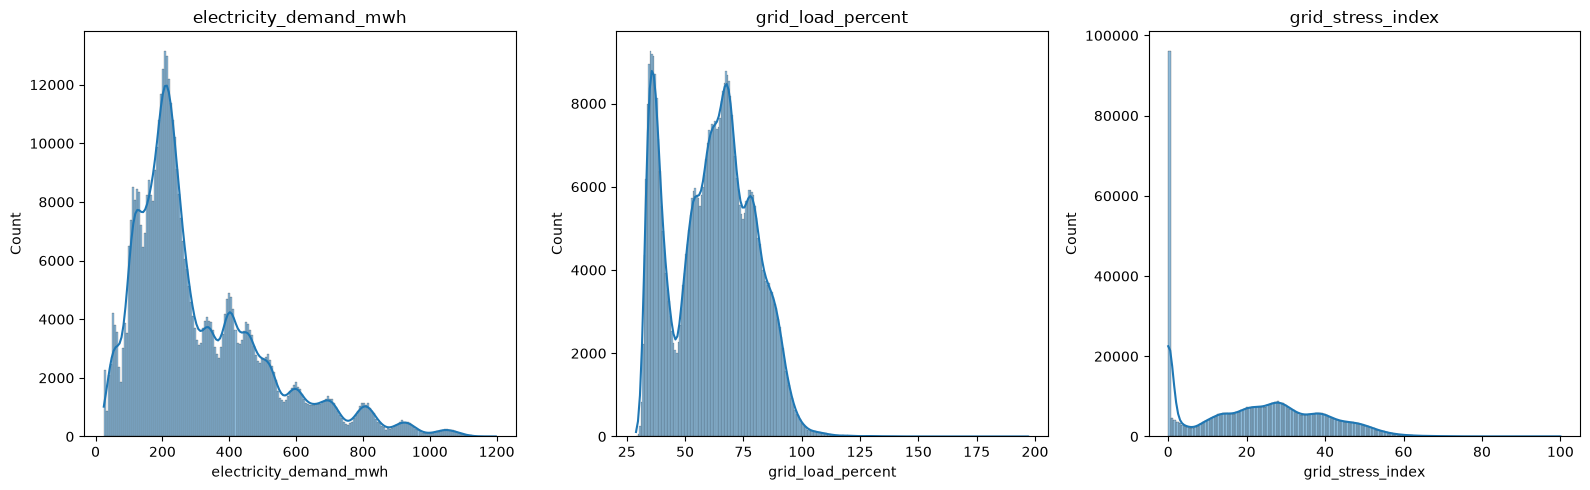

In [148]:
normal_cols = ['electricity_demand_mwh', 'grid_load_percent', 'grid_stress_index']
renewable_cols = ['solar_generation_mwh', 'wind_generation_mwh', 'total_renewable_generation_mwh', 'renewable_generation_percent']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(normal_cols):
    sns.histplot(power_grid_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

In [149]:
(power_grid_clean['grid_stress_index'] == 0).mean() * 100

np.float64(17.513311461302642)

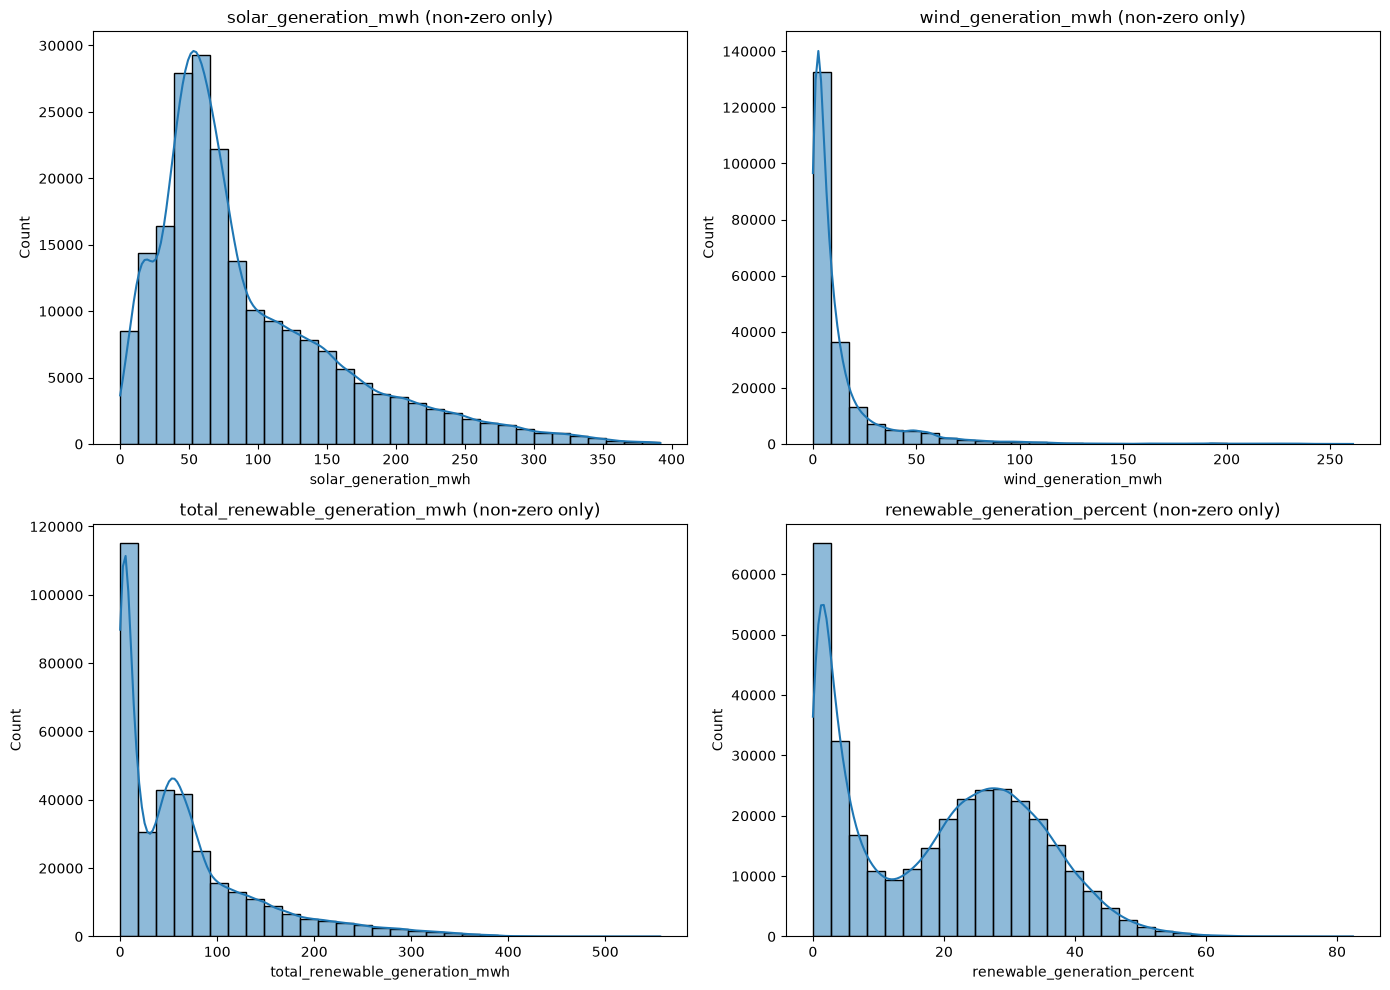

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(renewable_cols):
    sns.histplot(power_grid_clean[power_grid_clean[col] > 0][col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} (non-zero only)')
plt.tight_layout()

In [151]:
power_grid_clean.groupby(power_grid_clean['solar_generation_mwh'] > 0)['total_renewable_generation_mwh'].mean()

solar_generation_mwh
False     5.976067
True     98.337977
Name: total_renewable_generation_mwh, dtype: float64

<a id="s4-4"></a>

### 4.4 Outliers

*Why we run this.* Same screening as previous chapters, and here the interpretation is dominated by
the zero-inflation just established: when 59% of a column is zero, the IQR fences sit close to zero,
so ordinary generation gets flagged as "extreme".

- **`skew()`** — the tail direction per column.
- **`iqr_outliers` loop** — flagged counts, read against the skew and zero-rate of each column.

In [152]:
power_grid_clean[power_numeric_cols].skew()

electricity_demand_mwh            1.264132
grid_load_percent                 0.048897
grid_stress_index                 0.225356
solar_generation_mwh              2.129291
wind_generation_mwh               6.522707
total_renewable_generation_mwh    2.138058
renewable_generation_percent      0.806084
dtype: float64

In [153]:
for col in power_numeric_cols:
    n_out = len(iqr_outliers(power_grid_clean[col]))
    print(f"{col}: {n_out} outliers ({n_out/len(power_grid_clean)*100:.2f}%)")

electricity_demand_mwh: 21915 outliers (4.21%)
grid_load_percent: 540 outliers (0.10%)
grid_stress_index: 631 outliers (0.12%)
solar_generation_mwh: 41659 outliers (8.00%)
wind_generation_mwh: 73377 outliers (14.09%)
total_renewable_generation_mwh: 37888 outliers (7.28%)
renewable_generation_percent: 134 outliers (0.03%)


#### Insights: Distribution, Skew & Outliers

**Demand and load reveal a hidden two-regime structure:**
- `electricity_demand_mwh` is right-skewed (1.26) with 4.2% flagged outliers
- `grid_load_percent`, despite looking clearly bimodal in the histogram (peaks near ~35% 
  and ~68%), has almost zero skew (0.05) and very few outliers (0.10%) — a reminder that 
  skew only measures tail lean, not the number of humps. The two peaks likely correspond 
  to two distinct operating regimes (day vs. night, or a district-level split) — the exact 
  driver is still open and should be confirmed once we look at the time-of-day pattern.
- `grid_stress_index` is similarly close to symmetric (0.23) with few outliers (0.12%), 
  even though 17.5% of rows sit at exactly zero — this is a partial, not extreme, 
  zero-inflation: a real, wide, smooth distribution up to 100 exists alongside the spike, 
  unlike the near-total zero-dominance seen in rare-event columns.

**Renewables are split into two physically distinct regimes, not randomly noisy:**
- `solar_generation_mwh` is zero exactly during non-daylight hours (confirmed directly: 
  0 output for hours 0-7 and 18-23, ~90 MWh average for hours 8-17) — a deterministic 
  daylight cutoff, not intermittency.
- `wind_generation_mwh` is independently zero-inflated (~59%) for an unrelated reason — 
  confirmed to have no hourly pattern at all (flat mean across all 24 hours) and no 
  correlation with solar's zero/non-zero state 
- `total_renewable_generation_mwh` and `renewable_generation_percent` are bimodal because 
  they combine both sources: nighttime rows (solar=0) average only 5.98 MWh of renewable 
  output (wind alone), while daytime rows average 98.34 MWh (wind + solar stacked) — 
  a >16x jump between the two regimes, fully explaining the two-hump shape.

**Outlier decision:** no values removed or capped.<br> `electricity_demand_mwh`'s outliers 
represent genuine peak-demand hours worth preserving for capacity analysis.<br> The very high 
outlier rates on `wind_generation_mwh` (14.1%), `solar_generation_mwh` (8.0%), and 
`total_renewable_generation_mwh` (7.3%) are statistical artifacts of their zero-inflated 
distributions <br>IQR fences sit close to zero, so ordinary non-zero generation gets flagged 
as "extreme" even though it isn't. `grid_load_percent` and `grid_stress_index`'s low outlier 
rates (0.10%, 0.12%) reflect that their apparent complexity (bimodality, partial 
zero-inflation) is well-contained within a normal-looking spread, not genuine extremes.

<a id="s4-5"></a>

### 4.5 Trends over time

*Why we run this.* §4.3 left one question open: `grid_load_percent` is visibly bimodal, but why?
Time of day is the obvious candidate, and this section tests it. The monthly view then asks a
separate question — is electricity demand seasonal, and if so, does it peak in winter (heating) or
summer (cooling)?

- **`.dt.hour` and `.dt.month`** — the two grouping keys.
- **Hourly and monthly aggregations** — demand and load by hour, demand by month, solar by hour.
- **Three plots** — the daily demand profile, the annual demand profile and the solar day/night
  switch.

In [154]:
power_grid_clean['hour'] = power_grid_clean['timestamp'].dt.hour
power_grid_clean['month'] = power_grid_clean['timestamp'].dt.month

In [155]:
hourly = power_grid_clean.groupby('hour')[['electricity_demand_mwh', 'grid_load_percent', 'solar_generation_mwh']].mean()
hourly

,electricity_demand_mwh,grid_load_percent,solar_generation_mwh
hour,,,
0,192.302073,38.586681,0.000000
1,191.988375,38.533772,0.000000
2,191.580977,38.405099,0.000000
3,191.459737,38.339940,0.000000
4,191.213919,38.216315,0.000000
5,191.254186,38.211803,0.000000
6,274.187726,54.413851,0.000000
7,274.787873,54.514419,0.000000
8,275.432342,54.760802,90.803083


In [156]:
monthly = power_grid_clean.groupby('month')[['electricity_demand_mwh', 'grid_load_percent']].mean()
monthly

,electricity_demand_mwh,grid_load_percent
month,,
1,315.944793,63.408251
2,313.544729,62.749682
3,307.413537,60.922720
4,301.101261,59.040169
5,304.249902,59.590458
6,319.620830,63.942725
7,321.524451,64.393845
8,315.407828,62.684603
9,304.228585,59.590913


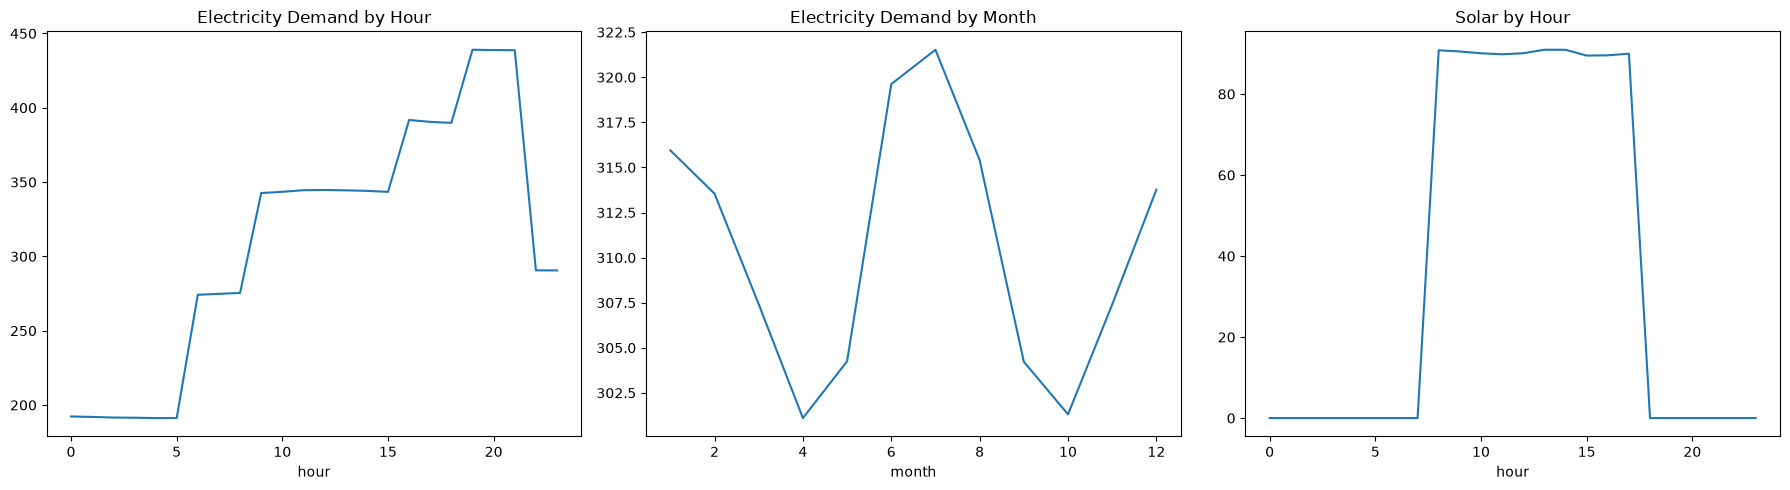

In [157]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
hourly['electricity_demand_mwh'].plot(ax=axes[0], title='Electricity Demand by Hour')
monthly['electricity_demand_mwh'].plot(ax=axes[1], title='Electricity Demand by Month')
hourly['solar_generation_mwh'].plot(ax=axes[2], title='Solar by Hour')
plt.tight_layout()

#### Insights: Time Trends — power_grid.csv

- `Electricity Demand` follows a step pattern tied to activity blocks (night low ~192, morning ramp, 
  midday plateau ~344, evening peak ~439 at hour 19) rather than one smooth curve — this 
  explains grid_load_percent's earlier bimodality: low-demand night hours cluster 
  separately from the broad mid/high-demand daytime block.
- `Electricity Demand` is seasonal with TWO peaks: winter (Jan ~316) and summer (Jul ~322), both above 
  the spring/fall troughs (Apr/Sep ~301). Both heating and cooling load drive demand up
- `Solar` output is a clean on/off switch tied to daylight (0 outside 8-17, ~90 within), 
  confirming the earlier hourly check visually.

<a id="s4-6"></a>

### 4.6 Relationships between the grid variables

*Why we run this.* Seven numeric columns describing one physical system, several of which are likely
to be near-duplicates. The heatmap identifies which pairs are genuinely redundant (so only one
belongs in a downstream model) and which are independent.

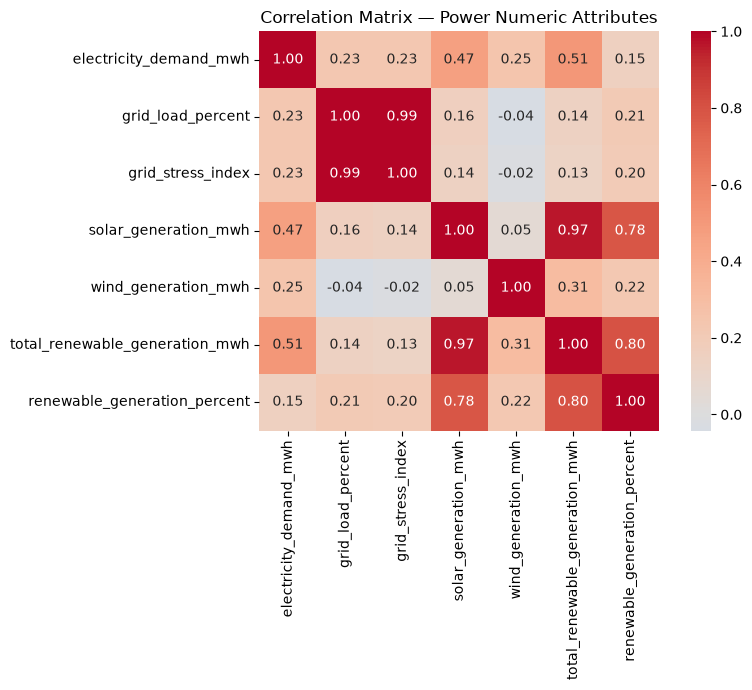

In [158]:
power_corr_matrix = power_grid_clean[power_numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(power_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Power Numeric Attributes')
plt.tight_layout()

#### Insights: Correlation Matrix — power_grid.csv

- `grid_load_percent` and `grid_stress_index` are near-identical (r=0.99) — confirmed as 
  the same underlying "grid strain" signal, redundant with each other.
- `electricity_demand_mwh` only weakly correlates with load/stress (0.23 each) 
- `solar_generation_mwh` drives `total_renewable_generation_mwh` (0.97); wind is a minor, 
  largely independent contributor (≤0.31 with everything).
- Electrical Demand correlates moderately with solar (0.47) — likely coincidental daytime overlap 
  (both peak roughly 8am-5pm/9pm), not a causal link.

<a id="s4-7"></a>

### 4.7 Flag validation: outages

*Why we run this.* Same two-part test used for every flag in this notebook: (a) is it internally
consistent with its own paired column, and (b) does it correspond to genuinely different conditions?

- **Means by `outage_flag`** — are outages associated with elevated load, stress and demand?
- **`crosstab` against `outage_duration_minutes > 0`** — the 1-to-1 consistency check.

The interesting result is the contrast with `traffic.csv`'s `accident_flag`, which showed a large
conditions gap. A weak gap here points to a different underlying cause.

In [159]:
power_grid_clean.groupby('outage_flag')[['grid_load_percent', 'grid_stress_index', 'electricity_demand_mwh']].mean()

,grid_load_percent,grid_stress_index,electricity_demand_mwh
outage_flag,,,
0,61.587460,22.505770,310.461185
1,68.598299,29.453588,312.532798


In [160]:
pd.crosstab(power_grid_clean['outage_flag'], power_grid_clean['outage_duration_minutes'] > 0)

outage_duration_minutes,False,True
outage_flag,,
0,520294,0
1,0,310


#### Insights: Flag Validation 

- `outage_duration_minutes` is perfectly paired with `outage_flag` (1-to-1, no exceptions) — reliable.
- Outages correspond to only mildly elevated load (68.6 vs 61.6) and stress (29.5 vs 22.5) — 
  a real but weak effect
  Outages appear more driven by equipment/random failure than by grid strain alone.

<a id="s4-8"></a>

### 4.8 District and weather context

*Why we run this.* Two cross-table questions.

**(a) Does the district-level relationship from Chapter 1 hold in the real hourly data?**
`districts.csv` showed `industrial_activity_index` correlating 0.82 with *baseline* demand. Here we
aggregate three years of *actual* demand per district and test the same pair — a cross-file
confirmation rather than a new finding.

**(b) Does temperature drive demand?** We merge in temperature and `heatwave_flag` for the matching
district-hour and test the relationship two ways: as a correlation with the continuous variable, and
as a group comparison on the flag. The two disagree, and that disagreement is the finding — a
correlation coefficient cannot see a U-shaped relationship, because the rise at the cold end and the
rise at the hot end cancel out.

In [161]:
power_district = power_grid_clean.groupby('district_id', as_index=False)['electricity_demand_mwh'].mean().merge(
    districts[['district_id', 'district_type', 'industrial_activity_index']], on='district_id'
)
power_district

,district_id,electricity_demand_mwh,district_type,industrial_activity_index
0,D01,375.283568,Commercial,10
1,D02,466.052517,Commercial,5
2,D03,738.125068,Industrial,100
3,D04,238.223234,Residential,5
4,D05,220.464545,Residential,10
5,D06,193.354174,Residential,15
6,D07,202.445478,Residential,5
7,D08,420.355877,Commercial,20
8,D09,175.002485,Mixed,0
9,D10,556.390780,Transport,60


In [162]:
power_district[['industrial_activity_index', 'electricity_demand_mwh']].corr()

,industrial_activity_index,electricity_demand_mwh
industrial_activity_index,1.000000,0.841279
electricity_demand_mwh,0.841279,1.000000


In [163]:
power_weather = power_grid_clean.merge(
    weather_clean[['district_id', 'timestamp', 'temperature_c', 'heatwave_flag']], on=['district_id', 'timestamp'], how='inner'
)
power_weather

,timestamp,district_id,electricity_demand_mwh,grid_capacity_mwh,solar_generation_mwh,wind_generation_mwh,total_renewable_generation_mwh,renewable_generation_percent,grid_load_percent,grid_stress_index,outage_flag,outage_duration_minutes,sensor_status,hour,month,temperature_c,heatwave_flag
0,2023-01-01 00:00:00,D01,249.143374,617.454012,0.0,0.000000,0.000000,0.000000,40.350110,0.350110,0,0.0,Normal,0,1,-2.114558,0
1,2023-01-01 00:00:00,D02,306.555550,843.839288,0.0,0.000000,0.000000,0.000000,36.328665,0.000000,0,0.0,Normal,0,1,-2.475176,0
2,2023-01-01 00:00:00,D03,451.257617,1306.398788,0.0,0.000000,0.000000,0.000000,34.542103,0.000000,0,0.0,Normal,0,1,-1.561745,0
3,2023-01-01 00:00:00,D04,171.874027,399.916155,0.0,0.000000,0.000000,0.000000,42.977515,2.977515,0,0.0,Normal,0,1,-5.354549,0
4,2023-01-01 00:00:00,D05,160.629531,342.471072,0.0,0.000000,0.000000,0.000000,46.903095,6.903095,0,0.0,Normal,0,1,-4.592405,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514115,2025-12-31 23:00:00,D16,195.659593,299.170225,0.0,0.000000,0.000000,0.000000,65.400757,25.400757,0,0.0,Normal,23,12,-1.261698,0
514116,2025-12-31 23:00:00,D17,334.867970,579.903013,0.0,0.000000,0.000000,0.000000,57.745513,17.745513,0,0.0,Normal,23,12,-0.662302,0
514117,2025-12-31 23:00:00,D18,170.702369,284.614039,0.0,3.582555,3.582555,2.086491,59.976792,19.976792,0,0.0,Normal,23,12,-0.382823,0
514118,2025-12-31 23:00:00,D19,171.154912,249.277801,0.0,3.041694,3.041694,1.766835,68.660311,28.660311,0,0.0,Normal,23,12,-2.058800,0


In [164]:
power_weather.groupby('heatwave_flag')['electricity_demand_mwh'].mean()

heatwave_flag
0    309.525873
1    342.164408
Name: electricity_demand_mwh, dtype: float64

In [165]:
power_weather[['temperature_c', 'electricity_demand_mwh']].corr()

,temperature_c,electricity_demand_mwh
temperature_c,1.000000,0.122393
electricity_demand_mwh,0.122393,1.000000


#### Insights: District & Weather Context 

- `industrial_activity_index` strongly predicts electricity demand (r=0.84) at the 
  district level — confirming the same relationship found in districts.csv (r=0.82). 
  Industrial districts are reliably the heaviest power consumers.
- Heatwave days show clearly elevated demand (342.2 vs 309.5, ~10.5% higher) — confirms 
  cooling load exists. But raw temperature correlates weakly (0.12) — because demand 
  rises at BOTH hot and cold extremes (per dual seasonal peaks), so a straight-line 
  correlation cancels out the U-shaped relationship. Temperature's effect is real but not 
  linear — heatwave_flag captures it better than raw temperature does.

<a id="s4-9"></a>

### 4.9 Chapter takeaways

**`grid_capacity_mwh` is fully redundant here** — identical to `districts.csv`'s static value for
all 20 districts (difference 0.0 everywhere). Drop it from any modelling frame built on this file.

**Load and stress are near-duplicate signals** (r = 0.99), but `electricity_demand_mwh` relates only
weakly to either (r = 0.23). This is a real structural difference from `traffic.csv`, where volume,
congestion and speed were all tightly bound: here, demand alone does not predict grid strain.

**Two independent renewable stories.** Solar is a deterministic daylight switch (0 outside hours
8–17, ~90 MWh within). Wind is random intermittency with no time pattern at all (flat mean across all
24 hours) and no relationship to solar's on/off state. Their combination is what makes
`total_renewable_generation_mwh` bimodal: 5.98 MWh average at night versus 98.34 MWh in daylight, a
16× jump.

**Demand has a genuine dual structure** — a step pattern by hour (night trough ~192 → evening peak
~439) and a dual seasonal peak (winter ~316 *and* summer ~322, both above the spring/autumn troughs
~301). Both heating and cooling drive demand.

**Outages are equipment-driven, not strain-driven.** `outage_flag` and `outage_duration_minutes` pair
perfectly, but outages correspond to only ~7 points of extra load and stress — far weaker than
traffic's accident effect.

**Industrial activity strongly predicts demand** (r = 0.84), closely matching the r = 0.82 found in
`districts.csv` — a clean cross-file confirmation.

**No values were dropped or capped.**

> **Pitfalls caught in this chapter.**
>
> - **Misreading the capacity comparison.** The 40-row result (20 matched + 20 NaN) came from
>   `grid_capacity_mwh` having its own nulls in `power_grid`, not from the column varying over time.
>   Once matched correctly it is fully static.
> - **Nearly concluding solar and wind were linked** because their zero-rates are almost identical
>   (~59.5%). A crosstab conditioned on time of day showed the rates barely move — coincidence, not
>   a shared cause.
> - **Bimodal ≠ skewed.** `grid_load_percent` looked clearly two-humped but had a skew of 0.05. Skew
>   measures tail lean, not the number of humps; the bimodality had to be traced to the hourly step
>   pattern instead.
> - **A U-shape hiding inside a weak correlation.** Demand correlates only 0.12 with temperature
>   despite heatwave days showing clearly higher demand (342 vs 310) — the same "wrong tool" problem
>   as `accident_count` in Chapter 3.

---
<a id="ch5"></a>

## 5. `air_quality.csv` — six pollutants and an AQI index

[↑ back to contents](#toc)

**What this file is.** Hourly air quality per district: five individual pollutants, a composite
index, and a categorical health band.

**What each row carries.**

- **Pollutants**: `pm25`, `pm10` (particulates), `no2`, `co` (combustion gases), `o3` (ozone)
- **Composite index**: `synthetic_aqi`
- **Derived label**: `air_quality_category` (Good → Very Unhealthy)
- **Pre-built flag**: `pollution_alert_flag`
- **Metadata**: `sensor_status`

**The organising idea of this chapter.** Five of the six pollutants are *directly emitted* —
something burns, the sensor detects it. `o3` is not: it forms photochemically, from sunlight acting
on other gases. That single physical difference turns out to explain why `o3`'s distribution shape,
its daily cycle, its seasonality and its correlations all look unlike everything else in the file.

**Questions this chapter answers**

1. Which pollutants share a source, and which are independent?
2. Can the `air_quality_category` banding rule be recovered exactly from `synthetic_aqi`?
3. What actually drives pollution in this city — industry, traffic, or weather?
4. Does `o3`'s visual dominance of the AQI time series mean it dominates AQI's value?

<a id="s5-1"></a>

### 5.1 Loading, types, duplicates and categories

*Why we run this.* The standard opening plus a categorical decision.

- **`head` / `shape` / `info` / `to_datetime`** — inventory and timestamp conversion.
- **Two duplicate checks, inspection, then `drop_duplicates`** — this file has the same 1,052
  full-row duplicates that `traffic.csv` had, which itself is informative: the same duplication
  artifact appearing in two files points to the data generation process rather than two unrelated
  problems.
- **`air_quality_category.value_counts()` and `category_order`** — the five bands have a natural
  severity order that alphabetical sorting would scramble ("Good" would land between "Very
  Unhealthy" and "Moderate"). Defining the order here and casting to an ordered `Categorical` after
  cleaning makes every later groupby, sort and plot come out in severity order automatically.

In [166]:
air_quality = pd.read_csv('data/air_quality.csv')

In [167]:
air_quality.head(10)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal
5,2025-05-28 00:00:00,D20,10.788017,22.500426,15.822771,22.926125,0.776106,26.0,Good,0,Normal
6,2023-09-01 20:00:00,D10,19.496830,37.542131,23.851285,40.002182,0.773935,48.0,Good,0,Normal
7,2024-03-23 23:00:00,D06,10.852200,22.266415,15.478677,8.552250,0.498035,27.0,Good,0,Normal
8,2024-02-20 04:00:00,D14,13.758044,18.978176,16.987760,9.429161,0.522662,34.0,Good,0,Normal
9,2024-03-04 06:00:00,D08,33.876804,59.456649,32.797248,29.351694,1.222775,84.0,Moderate,0,Normal


In [168]:
air_quality.shape

(527132, 11)

In [169]:
air_quality.info()

<class 'pandas.DataFrame'>
RangeIndex: 527132 entries, 0 to 527131
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             527132 non-null  str    
 1   district_id           527132 non-null  str    
 2   pm25                  521691 non-null  float64
 3   pm10                  521691 non-null  float64
 4   no2                   521691 non-null  float64
 5   o3                    521691 non-null  float64
 6   co                    521691 non-null  float64
 7   synthetic_aqi         521691 non-null  float64
 8   air_quality_category  527132 non-null  str    
 9   pollution_alert_flag  527132 non-null  int64  
 10  sensor_status         527132 non-null  str    
dtypes: float64(6), int64(1), str(4)
memory usage: 44.2 MB


In [170]:
air_quality['timestamp'] = pd.to_datetime(air_quality['timestamp'], errors='coerce')

In [171]:
air_quality['timestamp'].dtype

dtype('<M8[us]')

In [172]:
air_quality.duplicated(subset=['timestamp', 'district_id']).sum()

np.int64(1052)

In [173]:
air_quality.duplicated().sum()

np.int64(1052)

In [174]:
air_quality[air_quality.duplicated(keep=False)].sort_values(['timestamp','district_id']).head(20)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
127317,2023-01-01 00:00:00,D06,12.798320,22.786933,14.812070,0.000000,0.684891,31.0,Good,0,Normal
327901,2023-01-01 00:00:00,D06,12.798320,22.786933,14.812070,0.000000,0.684891,31.0,Good,0,Normal
74526,2023-01-01 03:00:00,D10,20.211162,38.594401,26.541720,4.260413,0.444005,50.0,Good,0,Normal
413467,2023-01-01 03:00:00,D10,20.211162,38.594401,26.541720,4.260413,0.444005,50.0,Good,0,Normal
4004,2023-01-01 05:00:00,D09,5.174749,8.823847,11.668120,7.417345,0.421315,14.0,Good,0,Normal
331776,2023-01-01 05:00:00,D09,5.174749,8.823847,11.668120,7.417345,0.421315,14.0,Good,0,Normal
370057,2023-01-02 09:00:00,D09,12.639998,23.479548,21.359899,37.684304,0.835439,37.0,Good,0,Normal
392658,2023-01-02 09:00:00,D09,12.639998,23.479548,21.359899,37.684304,0.835439,37.0,Good,0,Normal
271337,2023-01-04 09:00:00,D07,14.137095,25.275345,27.679037,42.316518,0.984625,42.0,Good,0,Normal
410015,2023-01-04 09:00:00,D07,14.137095,25.275345,27.679037,42.316518,0.984625,42.0,Good,0,Normal


In [175]:
air_quality.drop_duplicates(inplace=True)

In [176]:
air_quality.shape

(526080, 11)

In [177]:
air_quality.duplicated(subset=['timestamp', 'district_id']).sum()

np.int64(0)

In [178]:
air_quality['air_quality_category'].value_counts()

air_quality_category
Good                              322795
Moderate                          174039
Unhealthy for Sensitive Groups     21011
Unhealthy                           5869
Very Unhealthy                      2366
Name: count, dtype: int64

In [179]:
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy']

<a id="s5-2"></a>

### 5.2 Missing values

*Why we run this.* Fourth consecutive file, same mechanism, verified the same way: null counts, the
`sensor_status` cross-check, the conflict loop proving all six pollutant columns fail together, the
per-district bias check, and the `Normal`-rows equality assertion. Then drop, sort chronologically,
and cast the category column to its ordered type.

#### Null checks

In [180]:
air_quality.isna().any()

timestamp               False
district_id             False
pm25                     True
pm10                     True
no2                      True
o3                       True
co                       True
synthetic_aqi            True
air_quality_category    False
pollution_alert_flag    False
sensor_status           False
dtype: bool

In [181]:
air_quality.isna().sum()

timestamp                  0
district_id                0
pm25                    5425
pm10                    5425
no2                     5425
o3                      5425
co                      5425
synthetic_aqi           5425
air_quality_category       0
pollution_alert_flag       0
sensor_status              0
dtype: int64

In [182]:
air_quality['sensor_status'].value_counts()

sensor_status
Normal                520655
Communication-Loss      5323
Outage-Affected          102
Name: count, dtype: int64

In [183]:
air_quality[air_quality['pm25'].isna()]['sensor_status'].value_counts()

sensor_status
Communication-Loss    5323
Outage-Affected        102
Name: count, dtype: int64

In [184]:
air_null_cols = ['pm25', 'pm10', 'no2', 'o3', 'co', 'synthetic_aqi']
air_pm25_nulls = air_quality[air_quality['pm25'].isna()].index
air_nulls_conflicts = []
for i in air_null_cols:
    if not (air_pm25_nulls.equals(air_quality[air_quality[i].isna()].index)):
        air_nulls_conflicts.append(i)
print(air_nulls_conflicts)

[]


In [185]:
air_quality.groupby('district_id')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

district_id
D01    0.009846
D02    0.011215
D03    0.010227
D04    0.010759
D05    0.009808
D06    0.010189
D07    0.010036
D08    0.009808
D09    0.010379
D10    0.009618
D11    0.011367
D12    0.011671
D13    0.010227
D14    0.011025
D15    0.009162
D16    0.010721
D17    0.009694
D18    0.010151
D19    0.010721
D20    0.009618
Name: sensor_status, dtype: float64

In [186]:
air_quality[air_quality['sensor_status'] == 'Normal'].shape[0] == air_quality.dropna().shape[0]

True

In [187]:
air_quality_clean = air_quality.dropna().sort_values('timestamp').reset_index(drop=True)
air_quality_clean.isna().sum()

timestamp               0
district_id             0
pm25                    0
pm10                    0
no2                     0
o3                      0
co                      0
synthetic_aqi           0
air_quality_category    0
pollution_alert_flag    0
sensor_status           0
dtype: int64

In [188]:
air_quality_clean['air_quality_category'] = pd.Categorical(air_quality_clean['air_quality_category'], categories=category_order, ordered=True)

In [189]:
air_quality_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 520655 entries, 0 to 520654
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             520655 non-null  datetime64[us]
 1   district_id           520655 non-null  str           
 2   pm25                  520655 non-null  float64       
 3   pm10                  520655 non-null  float64       
 4   no2                   520655 non-null  float64       
 5   o3                    520655 non-null  float64       
 6   co                    520655 non-null  float64       
 7   synthetic_aqi         520655 non-null  float64       
 8   air_quality_category  520655 non-null  category      
 9   pollution_alert_flag  520655 non-null  int64         
 10  sensor_status         520655 non-null  str           
dtypes: category(1), datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 40.2 MB


#### Insights: Consistency, dtypes & Null Handling 

- 1,052 full-row duplicates found and dropped — identical count to traffic.csv's duplicate 
  total, suggesting both files share the same underlying duplication artifact from data 
  generation rather than two unrelated issues.
- `air_quality_category` holds 5 distinct values (Good, Moderate, Unhealthy for Sensitive 
  Groups, Unhealthy, Very Unhealthy) in a clear severity order, with the overwhelming 
  majority of readings falling in Good (61%) or Moderate (33%) — only ~6% of readings 
  reach any Unhealthy tier. Cast as an ordered categorical so severity comparisons and 
  plot ordering behave correctly downstream, rather than defaulting to alphabetical order.
- All 6 numeric pollutant/index columns (`pm25`, `pm10`, `no2`, `o3`, `co`, 
  `synthetic_aqi`) share an identical null count (5,425) — the 
  same sensor-outage pattern seen in weather.csv, traffic.csv, and power_grid.csv. 
  Missingness is evenly distributed across districts (~0.9%-1.2%), with no conflicts 
  between which rows are null across the 6 columns.
- **Decision:** drop all null rows — the pattern is fully outage-driven, uniform across 
  districts, and not tied to any specific pollutant, time, or condition worth preserving 
  separately. This is the fourth consecutive file showing the same sensor-outage-null 
  mechanism, reinforcing that it's a deliberate, consistent feature of how this dataset 
  was generated rather than a one-off data quality issue.

<a id="s5-3"></a>

### 5.3 Distributions, skew and outliers

*Why we run this.* This is where `o3` first separates itself from the rest. We are looking for shape
families: pollutants that share a distribution shape probably share a source and a formation
mechanism.

- **`describe()` and six histograms** — the shapes. Five sharp-peaked right-skewed distributions,
  and one smooth hump.
- **`skew()`** — puts numbers on it (1.6–2.5 for the emission pollutants, 0.39 for `o3`).
- **Share of `o3` at exactly zero** — a small 2.17% spike that needs explaining.
- **Mean `o3` by hour** — explains it: the zeros sit at deep-night hours when photochemical
  formation stops. This also confirms `o3` follows a smooth solar curve rather than the hard on/off
  switch seen with solar generation in Chapter 4.
- **`iqr_outliers` loop and boxplots** — outlier rates, which track skew closely.

In [190]:
air_numeric_cols = ['pm25', 'pm10', 'no2', 'o3', 'co', 'synthetic_aqi']
air_quality_clean[air_numeric_cols].describe()

,pm25,pm10,no2,o3,co,synthetic_aqi
count,520655.000000,520655.000000,520655.000000,520655.000000,520655.000000,520655.000000
mean,17.260021,30.887774,22.790053,33.769902,0.834002,49.925019
std,12.723678,19.319198,11.722128,19.540054,0.361380,30.220843
min,0.000000,0.000000,0.000000,0.000000,0.105382,2.000000
25%,9.320640,18.859158,14.708304,18.742547,0.593090,30.000000
50%,13.713307,25.804079,19.927828,32.208267,0.737595,43.000000
75%,20.825626,36.571203,27.843316,46.707479,0.973936,61.000000
max,119.192134,185.001350,169.678793,109.441409,6.984994,297.000000


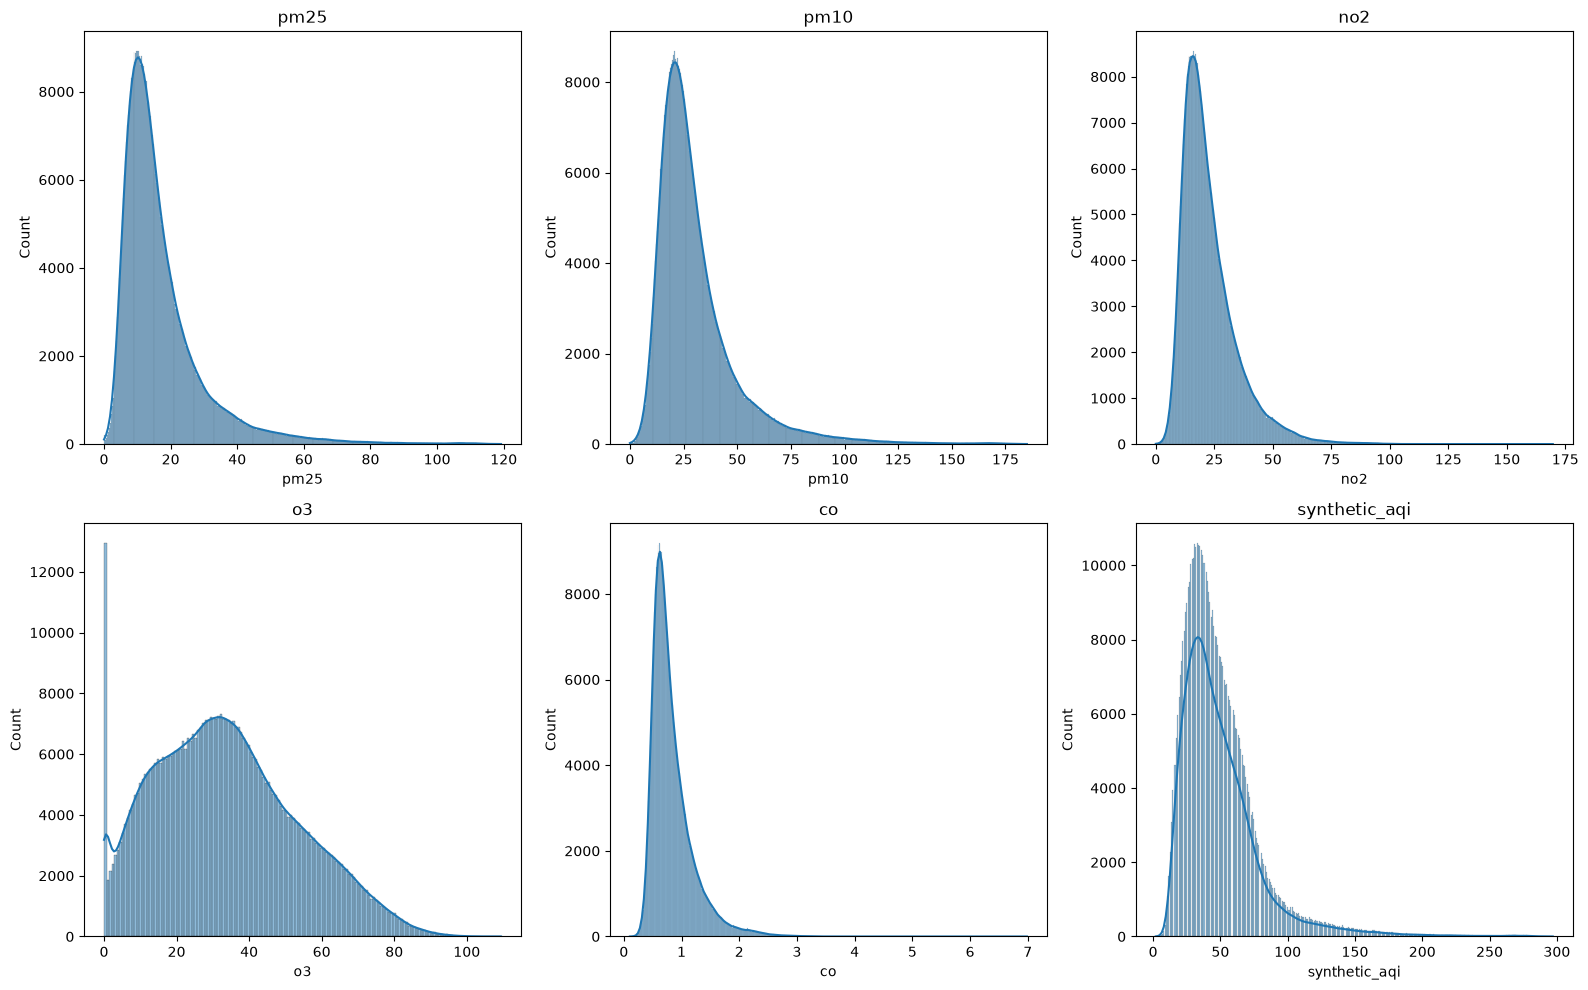

In [191]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()
for i, col in enumerate(air_numeric_cols):
    sns.histplot(air_quality_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

In [192]:
air_quality_clean[air_numeric_cols].skew()

pm25             2.477675
pm10             2.389439
no2              1.642943
o3               0.393528
co               1.873009
synthetic_aqi    2.353727
dtype: float64

In [193]:
(air_quality_clean['o3'] == 0).mean() * 100

np.float64(2.1718796515927052)

In [194]:
air_quality_clean.assign(hour=air_quality_clean['timestamp'].dt.hour).groupby('hour')['o3'].mean()

hour
0     19.047046
1     19.419900
2     20.078148
3     21.152980
4     22.300327
5     23.748294
6     25.934447
7     34.114283
8     41.916627
9     48.612260
10    53.121521
11    55.961452
12    57.228118
13    56.278824
14    53.207778
15    47.847145
16    41.818922
17    34.137812
18    25.988809
19    24.577511
20    22.503824
21    21.410518
22    20.648200
23    19.439939
Name: o3, dtype: float64

In [195]:
for col in air_numeric_cols:
    n_out = len(iqr_outliers(air_quality_clean[col]))
    print(f"{col}: \t{n_out} outliers ({n_out/len(air_quality_clean)*100:.2f}%)")

pm25: 	33982 outliers (6.53%)
pm10: 	32723 outliers (6.28%)
no2: 	22436 outliers (4.31%)
o3: 	1143 outliers (0.22%)
co: 	25580 outliers (4.91%)
synthetic_aqi: 	24007 outliers (4.61%)


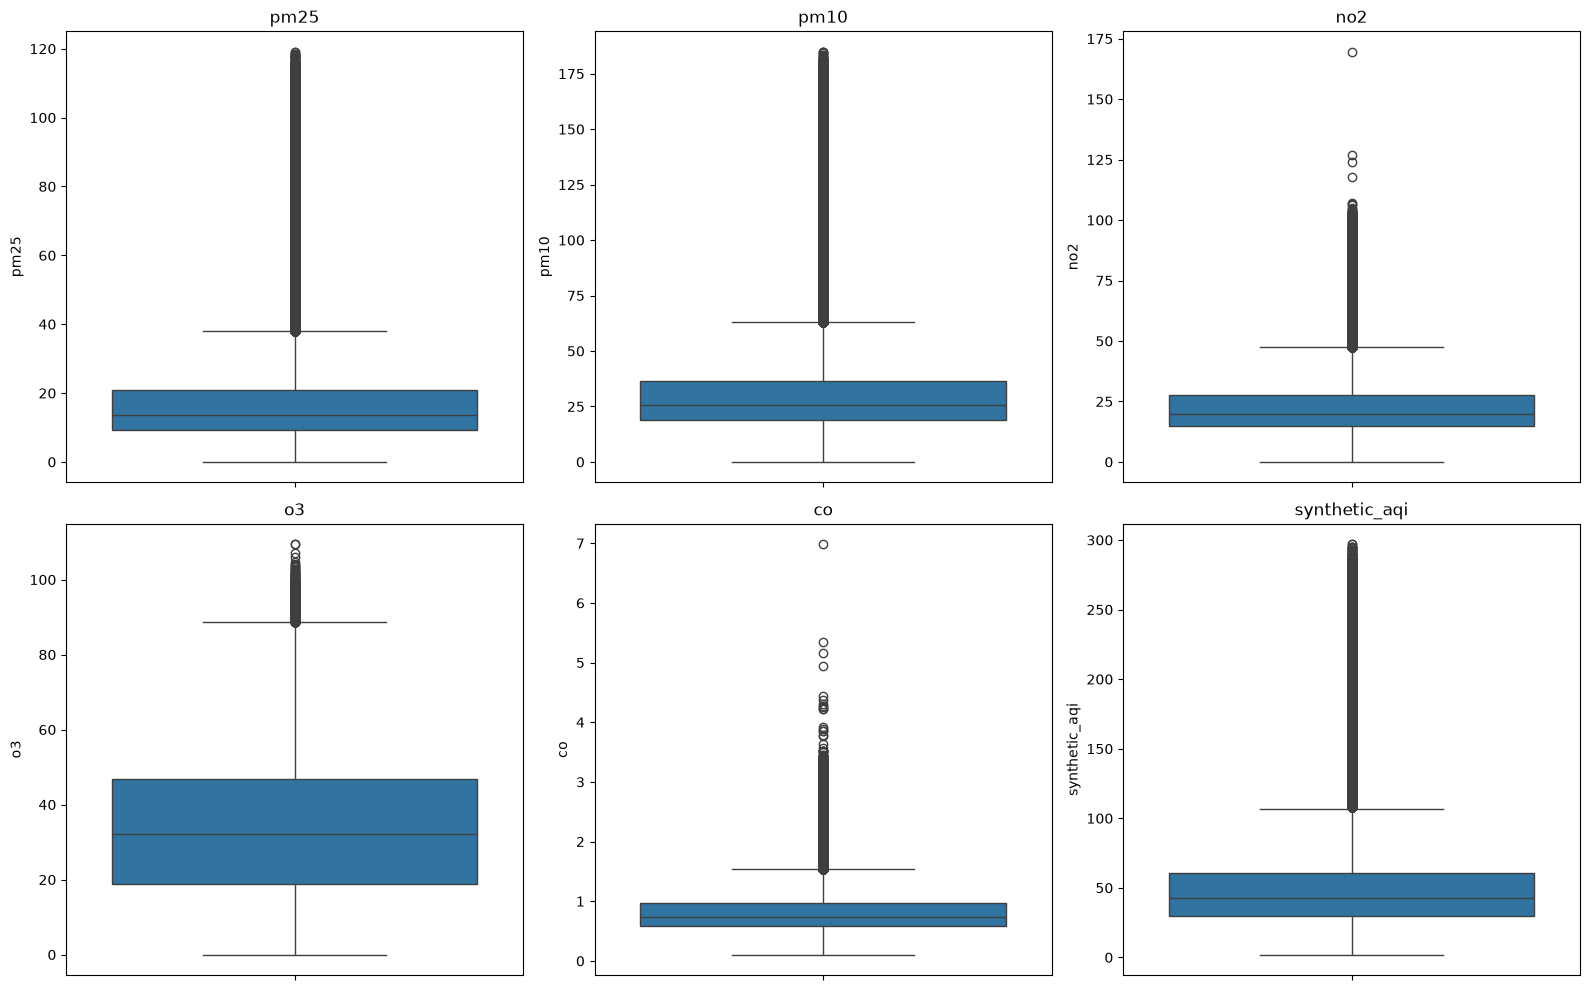

In [196]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()
for i, col in enumerate(air_numeric_cols):
    sns.boxplot(y=air_quality_clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

#### Insights: Distribution, Skew & Outliers 

- `pm25`, `pm10`, `no2`, `co`, and `synthetic_aqi` all share the same shape: strongly 
  right-skewed (skew 1.6–2.5), sharp peak near the low end, long thinning tail toward high 
  pollution readings. This is the classic signature of direct-emission pollutants — most 
  hours are clean, with a real but less common tail of high-pollution events (likely 
  overlapping with traffic/industrial activity, to confirm later).
- `o3` behaves distinctly from the rest — low skew (0.39), a smooth hump-shaped 
  distribution peaking around 30-40 rather than decaying from a sharp low peak. This 
  matches its photochemical nature: unlike directly-emitted pollutants, o3 forms from 
  sunlight-driven reactions and follows a clear daily solar cycle (confirmed directly: 
  mean rises smoothly from ~19 at night to ~57 at midday, tracking daylight rather than 
  emission sources).
- `o3`'s small zero-spike (2.17%) sits at deep-night hours where photochemical formation 
  is minimal — a real, low-value tail rather than a structural artifact.
- Outlier rates track skew closely: `pm25` (6.53%) and `pm10` (6.28%) show the highest 
  outlier share — consistent with occasional severe-pollution spikes — while `o3` has 
  the lowest (0.22%), fitting its smoother, less extreme distribution.
- **Decision:** no values removed or capped. Every flagged outlier across the 5 
  emission-driven pollutants represents a genuine high-pollution event worth preserving 
  for the alert/category validation  and the traffic/district merge

<a id="s5-4"></a>

### 5.4 Trends over time

*Why we run this.* Two cycles matter for air quality: the daily one (does pollution track rush hour,
or sunlight?) and the annual one (is there a pollution season?). We add `hour` and `month` columns
and aggregate on each.

Keep the result of this section in mind when reading §5.5 — the two sections appear to contradict
each other, and resolving that contradiction is the most instructive finding in this chapter.

In [197]:
air_quality_clean['hour'] = air_quality_clean['timestamp'].dt.hour
air_quality_clean['month'] = air_quality_clean['timestamp'].dt.month
air_quality_clean.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,hour,month
0,2023-01-01,D18,12.242668,21.097840,16.418533,0.480383,0.639115,30.0,Good,0,Normal,0,1
1,2023-01-01,D20,9.049954,13.662868,19.788688,4.664579,0.564931,23.0,Good,0,Normal,0,1
2,2023-01-01,D12,55.399468,88.199068,48.699894,9.519965,0.453731,138.0,Unhealthy for Sensitive Groups,0,Normal,0,1
3,2023-01-01,D08,18.254212,33.666482,25.610461,10.337124,0.582859,45.0,Good,0,Normal,0,1
4,2023-01-01,D03,67.386936,108.388819,55.332205,8.792343,0.383224,168.0,Unhealthy,1,Normal,0,1


In [198]:
hourly_air = air_quality_clean.groupby('hour')[['pm25', 'no2', 'co', 'o3', 'synthetic_aqi']].mean()
hourly_air

,pm25,no2,co,o3,synthetic_aqi
hour,,,,,
0,13.403463,17.066340,0.570928,19.047046,36.417416
1,13.432152,17.095411,0.569793,19.419900,36.593875
2,13.502665,17.147883,0.569120,20.078148,36.959596
3,13.711360,17.310974,0.571298,21.152980,37.711507
4,13.565296,17.219697,0.571242,22.300327,37.796697
5,13.562137,17.199034,0.570407,23.748294,38.399982
6,17.553014,23.202257,0.853916,25.934447,46.121187
7,20.308719,27.530027,1.061399,34.114283,54.024196
8,20.898187,28.201707,1.076553,41.916627,58.131381


In [199]:
monthly_air = air_quality_clean.groupby('month')[['pm25', 'no2', 'co', 'o3', 'synthetic_aqi']].mean()
monthly_air

,pm25,no2,co,o3,synthetic_aqi
month,,,,,
1,17.344648,22.937440,0.841056,19.601061,45.247170
2,17.298510,22.839687,0.832662,21.343252,45.403171
3,17.368276,22.884559,0.837610,26.555460,46.810605
4,17.225859,22.770144,0.832387,33.392270,48.593471
5,17.111744,22.676472,0.834615,40.321650,51.693787
6,17.399779,22.918263,0.835054,47.564209,56.693621
7,17.235339,22.770973,0.834474,48.236530,56.770836
8,17.300013,22.764700,0.830437,46.199532,55.508997
9,17.115190,22.641483,0.831767,40.256093,51.641345


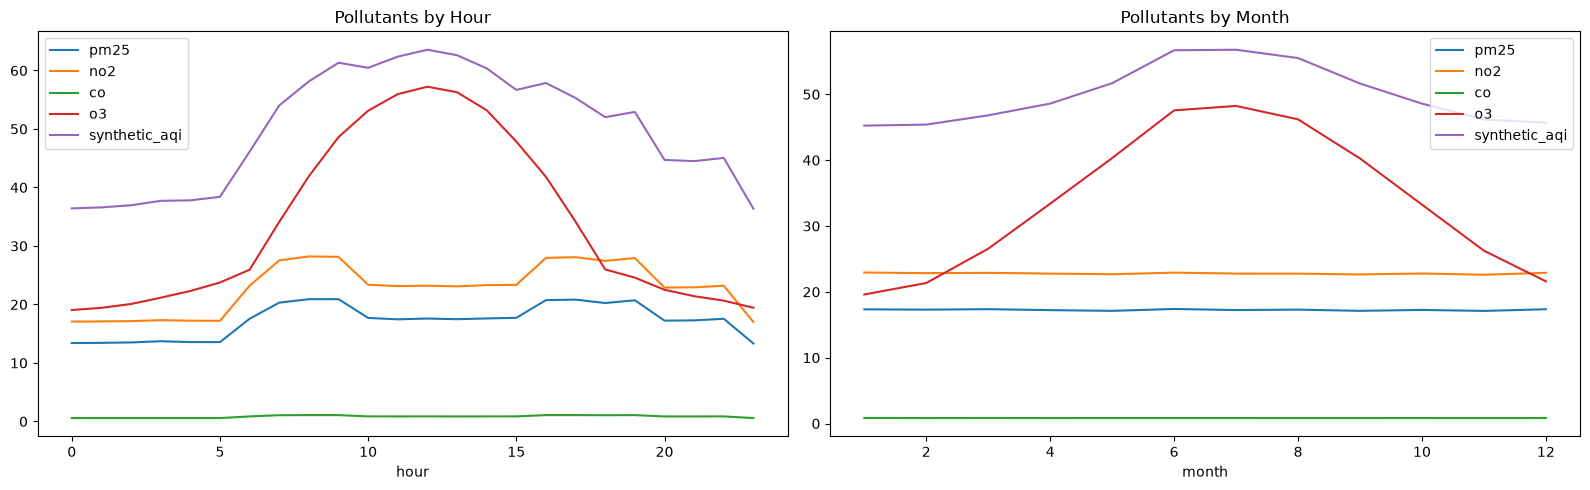

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
hourly_air.plot(ax=axes[0], title='Pollutants by Hour')
monthly_air.plot(ax=axes[1], title='Pollutants by Month')
plt.tight_layout()

#### Insights: Time Trends

- `synthetic_aqi's` timing (when it peaks during the day/year) visually tracks o3, since o3 has the largest absolute swing of any pollutant. 
    But correlation shows `pm25/pm10/no2` are actually the stronger drivers of synthetic_aqi's magnitude (0.85–0.93 vs o3's 0.47) — o3 shapes when AQI is highest, while pm25/pm10/no2 largely decide how high.
- `pm25`, `no2`, and `co` are essentially flat across both hour and month — no clear 
  rush-hour or seasonal cycle. sunlight (o3) dominates the overall signal. Worth confirming their traffic link directly in 
  via correlation, since it may be real but too small to show in a simple hourly mean.
- o3/synthetic_aqi's summer peak and daytime peak both align with stronger 
  sunlight/heat — consistent with photochemical formation intensifying with more 
  sun hours and higher temperatures.

<a id="s5-5"></a>

### 5.5 Relationships between pollutants

*Why we run this.* The time plots show *when* each pollutant peaks. The correlation matrix shows
*what moves with what* — which is a different question, and here it gives an apparently conflicting
answer about what drives `synthetic_aqi`.

The resolution, spelled out in the insights below, is that **timing and magnitude are different
properties**: `o3` has by far the largest absolute swing, so it dominates the *shape* of the AQI
curve on a time plot, while `pm25`/`pm10`/`no2` correlate far more strongly with AQI and therefore
dominate its *value*.

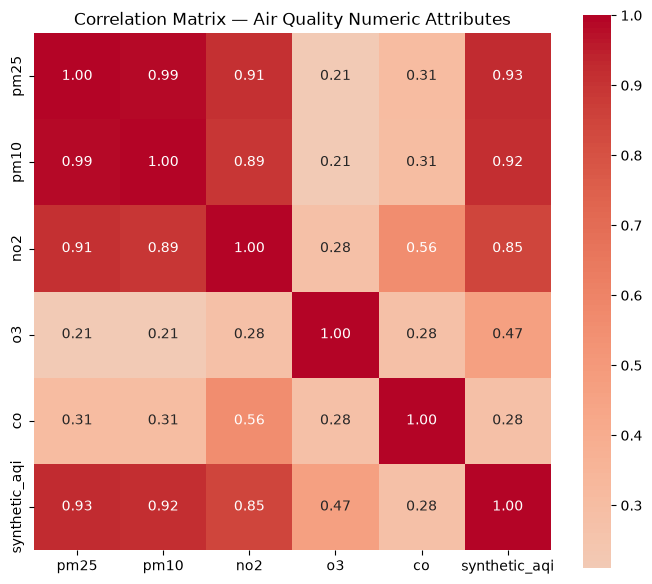

In [201]:
air_corr_matrix = air_quality_clean[air_numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(air_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Air Quality Numeric Attributes')
plt.tight_layout()

#### Insights: Correlation Matrix 

- `pm25`, `pm10`, `no2` are tightly correlated (0.89-0.99) — confirms they share a common 
  source (likely combustion/traffic emissions), differing mainly in particle size/gas type.
- These three also drive `synthetic_aqi` most strongly (0.85-0.93) — they're the real 
  magnitude-driver of the AQI score, not o3 (0.47) — apparent contradiction with the time trend
  time-trend plot, where synthetic_aqi's *shape* visually tracked o3's daily/seasonal 
  swing. Resolution: o3 has the largest absolute range (near 0 to ~57), so its cycle 
  dominates visually, while pm25/no2 likely have their own weaker cycle that got averaged 
  flat — worth a closer look if traffic-linked timing matters later.
- `co` shares moderate overlap with `no2` (0.56, likely combustion-linked) but weak overlap 
  with pm25/pm10 (0.31) — a partially different source or dispersal behavior.
- `o3` is the most independent pollutant overall (0.21-0.28 with everything except 
  synthetic_aqi) — consistent with its distinct photochemical formation process rather 
  than direct emission.

<a id="s5-6"></a>

### 5.6 Flag and category validation

*Why we run this.* Same validation pattern as every other file, applied to one flag and one
categorical band.

- **Mean `synthetic_aqi` by `pollution_alert_flag`** — does the alert mark genuinely worse air?
- **`groupby(category).agg(['min','max','count'])`** — this is how a banding rule is *recovered*:
  the min and max of each category reveal its cut-points, and non-overlapping ranges prove the rule
  is deterministic with no ambiguous rows.

In [202]:
air_quality_clean.groupby('pollution_alert_flag')['synthetic_aqi'].mean()

pollution_alert_flag
0     47.709671
1    189.339391
Name: synthetic_aqi, dtype: float64

In [203]:
# we apply min, max to get the bands
air_quality_clean.groupby('air_quality_category')['synthetic_aqi'].agg(['min','max','count'])

,min,max,count
air_quality_category,,,
Good,2.0,50.0,319488
Moderate,51.0,100.0,172264
Unhealthy for Sensitive Groups,101.0,150.0,20759
Unhealthy,151.0,200.0,5803
Very Unhealthy,201.0,297.0,2341


#### Insights: Flag/Category Validation

- `pollution_alert_flag` is strongly meaningful — flagged rows average synthetic_aqi of 
  189.3 vs. 47.7 unflagged (~4x higher)
- `air_quality_category` bands map exactly to synthetic_aqi in clean, non-overlapping 
  20-50-point ranges: 
  - Good (0-50)
  - Moderate (51-100)
  - Unhealthy for Sensitive Groups (101-150)
  - Unhealthy (151-200)
  - Very Unhealthy (201+). 
<br>The banding rule is fully recoverable and consistent — no ambiguous or misclassified rows.

<a id="s5-7"></a>

### 5.7 What actually drives pollution: district, traffic and weather

*Why we run this.* The core causal question of this chapter, tested against three candidate drivers
using three separate merges — each pulling only the columns its own question requires.

- **District merge** — aggregate pollutants to district level (20 rows) and correlate against
  `industrial_activity_index` and `commercial_activity_index`. Aggregating first is essential:
  these are static district properties.
- **Traffic merge** — an hourly inner join on `(timestamp, district_id)`, bringing in
  `congestion_index` and `traffic_volume`. This tests two distinct hypotheses at once: does raw
  vehicle *demand* pollute, or does being *stuck in traffic* pollute?
- **Weather merge** — same join pattern, bringing in wind and rainfall to test the two natural
  mitigation hypotheses (wind disperses, rain washes out).

In [204]:
district_air = air_quality_clean.groupby('district_id', as_index=False)[air_numeric_cols].mean().merge(
    districts[['district_id', 'industrial_activity_index', 'commercial_activity_index']], on='district_id'
)
district_air

,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,industrial_activity_index,commercial_activity_index
0,D01,20.533788,35.798695,29.237742,37.394436,1.206345,54.888040,10,95
1,D02,17.415497,31.129464,26.330046,37.222158,1.153310,49.285747,5,100
2,D03,51.149497,81.714411,46.201612,38.654084,0.645573,127.447359,100,30
3,D04,12.234173,23.340860,19.461639,31.967586,0.875165,38.892587,5,40
4,D05,14.220283,26.301653,20.791920,33.254030,0.862475,42.171543,10,35
5,D06,15.289078,27.909548,20.917280,33.517463,0.796916,43.842871,15,25
6,D07,11.889460,22.842469,18.990464,32.342010,0.852797,38.618433,5,45
7,D08,20.770075,36.158212,26.359314,35.678344,0.921672,54.632420,20,85
8,D09,9.911643,19.883645,17.398364,32.512366,0.844605,36.701356,0,60
9,D10,25.594553,43.395910,27.562360,33.181406,0.695006,64.764001,60,70


In [205]:
district_air[['industrial_activity_index', 'commercial_activity_index', 'pm25', 'pm10', 'no2', 'synthetic_aqi']].corr()

,industrial_activity_index,commercial_activity_index,pm25,pm10,no2,synthetic_aqi
industrial_activity_index,1.000000,-0.105575,0.916672,0.916759,0.812287,0.913053
commercial_activity_index,-0.105575,1.000000,0.085438,0.085401,0.269167,0.021352
pm25,0.916672,0.085438,1.000000,1.000000,0.969380,0.992862
pm10,0.916759,0.085401,1.000000,1.000000,0.969326,0.992877
no2,0.812287,0.269167,0.969380,0.969326,1.000000,0.948493
synthetic_aqi,0.913053,0.021352,0.992862,0.992877,0.948493,1.000000


In [206]:
air_traffic = air_quality_clean.merge(
    traffic_clean[['timestamp', 'district_id', 'congestion_index', 'traffic_volume']], on=['timestamp', 'district_id'], how='inner'
)
air_traffic

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,hour,month,congestion_index,traffic_volume
0,2023-01-01 00:00:00,D18,12.242668,21.097840,16.418533,0.480383,0.639115,30.0,Good,0,Normal,0,1,8.085675,241
1,2023-01-01 00:00:00,D20,9.049954,13.662868,19.788688,4.664579,0.564931,23.0,Good,0,Normal,0,1,7.794341,161
2,2023-01-01 00:00:00,D12,55.399468,88.199068,48.699894,9.519965,0.453731,138.0,Unhealthy for Sensitive Groups,0,Normal,0,1,4.317279,150
3,2023-01-01 00:00:00,D08,18.254212,33.666482,25.610461,10.337124,0.582859,45.0,Good,0,Normal,0,1,3.338292,261
4,2023-01-01 00:00:00,D03,67.386936,108.388819,55.332205,8.792343,0.383224,168.0,Unhealthy,1,Normal,0,1,0.008906,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515471,2025-12-31 23:00:00,D14,4.220500,9.531779,16.610121,1.917285,0.564902,19.0,Good,0,Normal,23,12,0.372130,279
515472,2025-12-31 23:00:00,D13,1.892487,7.633518,9.850855,6.023003,0.441945,11.0,Good,0,Normal,23,12,4.653978,80
515473,2025-12-31 23:00:00,D11,3.450491,8.721143,13.721880,4.900424,0.323982,16.0,Good,0,Normal,23,12,14.581443,401
515474,2025-12-31 23:00:00,D03,26.953920,45.742743,19.892822,17.225408,0.562672,67.0,Moderate,0,Normal,23,12,0.661458,140


In [207]:
air_traffic[['congestion_index', 'traffic_volume', 'pm25', 'no2']].corr()

,congestion_index,traffic_volume,pm25,no2
congestion_index,1.000000,0.875833,0.079090,0.291667
traffic_volume,0.875833,1.000000,0.182562,0.410821
pm25,0.079090,0.182562,1.000000,0.905962
no2,0.291667,0.410821,0.905962,1.000000


In [208]:
air_weather = air_quality_clean.merge(
    weather_clean[['timestamp', 'district_id', 'wind_speed_kmh', 'rainfall_mm']], on=['timestamp', 'district_id'], how='inner'
)
air_weather

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,hour,month,wind_speed_kmh,rainfall_mm
0,2023-01-01 00:00:00,D18,12.242668,21.097840,16.418533,0.480383,0.639115,30.0,Good,0,Normal,0,1,7.920973,0.000000
1,2023-01-01 00:00:00,D20,9.049954,13.662868,19.788688,4.664579,0.564931,23.0,Good,0,Normal,0,1,6.849491,0.000000
2,2023-01-01 00:00:00,D12,55.399468,88.199068,48.699894,9.519965,0.453731,138.0,Unhealthy for Sensitive Groups,0,Normal,0,1,6.919833,0.000000
3,2023-01-01 00:00:00,D08,18.254212,33.666482,25.610461,10.337124,0.582859,45.0,Good,0,Normal,0,1,5.157908,0.000000
4,2023-01-01 00:00:00,D03,67.386936,108.388819,55.332205,8.792343,0.383224,168.0,Unhealthy,1,Normal,0,1,5.326696,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514152,2025-12-31 23:00:00,D14,4.220500,9.531779,16.610121,1.917285,0.564902,19.0,Good,0,Normal,23,12,8.135852,0.526728
514153,2025-12-31 23:00:00,D13,1.892487,7.633518,9.850855,6.023003,0.441945,11.0,Good,0,Normal,23,12,11.617799,0.294560
514154,2025-12-31 23:00:00,D11,3.450491,8.721143,13.721880,4.900424,0.323982,16.0,Good,0,Normal,23,12,5.728655,0.777284
514155,2025-12-31 23:00:00,D03,26.953920,45.742743,19.892822,17.225408,0.562672,67.0,Moderate,0,Normal,23,12,8.299341,0.779860


In [209]:
air_weather[['wind_speed_kmh', 'rainfall_mm', 'pm25', 'no2', 'synthetic_aqi']].corr()

,wind_speed_kmh,rainfall_mm,pm25,no2,synthetic_aqi
wind_speed_kmh,1.000000,0.414949,-0.246818,-0.316555,-0.245496
rainfall_mm,0.414949,1.000000,-0.116533,-0.132777,-0.132351
pm25,-0.246818,-0.116533,1.000000,0.905861,0.926266
no2,-0.316555,-0.132777,0.905861,1.000000,0.847159
synthetic_aqi,-0.245496,-0.132351,0.926266,0.847159,1.000000


#### Insights: District, Traffic & Weather Context

- **Industrial activity is the dominant pollution driver**, not commercial activity: 
  `industrial_activity_index` correlates 0.91-0.92 with pm25/pm10/synthetic_aqi and 0.81 
  with no2, while `commercial_activity_index` is nearly irrelevant (0.02-0.27). This is 
  the strongest single predictor found across the whole project so far.
- **Traffic has a real but secondary effect**, `traffic_volume` correlates moderately with no2 (0.41, consistent with 
  vehicle exhaust) but weakly with pm25 (0.18). `congestion_index` is even weaker with 
  pm25 (0.08) — stationary/slow traffic isn't a major pollution source here; raw traffic 
  demand matters more than congestion severity.
- **Weather effects confirmed in direction, modest in size:** wind disperses pollutants 
  (pm25: -0.25, no2: -0.32) and rain washes them out (-0.12 to -0.13) — both hypotheses 
  hold, but neither weather factor comes close to industrial activity's effect size.
- **Bottom line:** air quality in this city is primarily a zoning/industrial-source 
  problem, with traffic contributing a smaller, no2-specific effect, and weather acting 
  as a moderate natural mitigator rather than a major driver either way.

<a id="s5-8"></a>

### 5.8 Chapter takeaways

**`pm25`, `pm10` and `no2` share one emission source** (r = 0.89–0.99) — they differ by particle
size and gas type, not by cause. `co` overlaps only partially (0.56 with `no2`, 0.31 with the
particulates), suggesting a partly different source.

**`o3` is structurally distinct.** Photochemical rather than directly emitted, it tracks sunlight
(smoothly from ~19 at night to ~57 at midday) and season (summer peak), and has the weakest
correlation with everything else (0.21–0.28).

**The `air_quality_category` banding is fully recoverable**: Good (0–50), Moderate (51–100),
Unhealthy for Sensitive Groups (101–150), Unhealthy (151–200), Very Unhealthy (201+). No overlap, no
ambiguity.

**`pollution_alert_flag` is strongly meaningful** — flagged rows average roughly 4× the AQI of
unflagged ones (189.3 vs 47.7), the cleanest flag separation in the project so far.

**Industrial activity is the dominant driver of pollution in this city** (r = 0.81–0.92 with every
major pollutant), far outweighing commercial activity (≈ 0). This is the single strongest predictor
found anywhere in the dataset.

**Traffic's effect is real but secondary**: `traffic_volume` correlates 0.41 with `no2` — consistent
with vehicle exhaust — but only 0.18 with `pm25`, and `congestion_index` matters even less (0.08).
Volume matters more than being stuck in it.

**Wind and rain both confirm as mitigators** (−0.12 to −0.32) but are modest next to industrial
activity.

**No values were dropped or capped**, and the null pattern was the same outage mechanism for the
fourth file running.

> **Pitfalls caught in this chapter.**
>
> - **A real contradiction between the time trends (§5.4) and the correlation matrix (§5.5).** The
>   time plot made `synthetic_aqi` look driven by `o3`; the correlations said `pm25`/`pm10`/`no2`.
>   Both are right about different things — `o3` has the largest absolute swing so it dominates the
>   *shape*, while the particulates dominate the *value*. This required going back and correcting an
>   earlier write-up once the later evidence came in.
> - **Nearly merging a column the question did not need** (`weather_impact_score` into the traffic
>   merge). Merging only what the specific question requires keeps frames narrow and results
>   interpretable.

---
<a id="ch6"></a>

## 6. `public_transport.csv` — ridership, service and delays

[↑ back to contents](#toc)

**What this file is.** The fifth and last hourly fact table: how many people used public transport
in each district each hour, how often vehicles ran, how full they were and how late they were.

**What each row carries.**

- **Demand**: `passenger_count`, `vehicle_occupancy_percent`
- **Supply**: `service_frequency` (minutes between vehicles)
- **Service quality**: `average_delay_minutes`
- **Pre-built flag**: `service_disruption_flag`
- **Metadata**: `sensor_status`

**Two structural quirks to establish up front**, because they shape everything afterwards:
`vehicle_occupancy_percent` routinely exceeds 100% and is capped at exactly 150, and
`service_frequency` takes only three distinct values, which makes it categorical rather than
continuous despite being stored as a number.

**Questions this chapter answers**

1. Is transit service scheduled around demand, or fixed?
2. Does the road network's rush hour appear in transit too?
3. What actually causes delay — crowding, road congestion, or disruptions?
4. Does weather push people onto transit?

<a id="s6-1"></a>

### 6.1 Loading, types and two structural checks

*Why we run this.* The standard opening, followed by two investigations that determine how the
columns must be treated for the rest of the chapter.

- **`head` / `shape` / `info` / `to_datetime` / `Int64` casts** — inventory and types.
  `passenger_count` and `service_frequency` are counts, so they get the nullable-integer treatment
  from Chapter 3.
- **`duplicated`** — composite key uniqueness.
- **Occupancy check** — `describe()` plus the share of readings above 100%. Over half the readings
  exceed "full", and the maximum sits at exactly 150.0. That is a deliberate overcrowding scale, not
  a data error, and the hard ceiling will matter when we read the distribution later.
- **Frequency checks** — `min`/`max`/`nunique` reveals only three values. The two follow-up
  groupbys test whether frequency is a *static district property* (does each district always run the
  same frequency?) or a *time-varying schedule*. Every district shows all three values, which
  settles it.
- **Mean frequency by hour** — with frequency established as time-varying, this shows the actual
  schedule and lets us compare it against `traffic.csv`'s rush-hour windows.

In [210]:
public_transport = pd.read_csv('data/public_transport.csv')

In [211]:
public_transport.head(10)

,timestamp,district_id,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,sensor_status
0,2023-01-01 00:00:00,D01,527.0,30.0,1.255956,131.75,0,Normal
1,2023-01-01 00:00:00,D02,199.0,30.0,0.587336,49.75,0,Normal
2,2023-01-01 00:00:00,D03,28.0,30.0,0.505464,7.00,0,Normal
3,2023-01-01 00:00:00,D04,632.0,30.0,6.850023,150.00,0,Normal
4,2023-01-01 00:00:00,D05,533.0,30.0,6.485823,133.25,0,Normal
5,2023-01-01 00:00:00,D06,475.0,30.0,2.404247,118.75,0,Normal
6,2023-01-01 00:00:00,D07,481.0,30.0,1.688809,120.25,0,Normal
7,2023-01-01 00:00:00,D08,95.0,30.0,2.008340,23.75,0,Normal
8,2023-01-01 00:00:00,D09,323.0,30.0,2.191436,80.75,0,Normal
9,2023-01-01 00:00:00,D10,22.0,30.0,0.559250,5.50,0,Normal


In [212]:
public_transport.shape

(526080, 8)

In [213]:
public_transport.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   timestamp                  526080 non-null  str    
 1   district_id                526080 non-null  str    
 2   passenger_count            520838 non-null  float64
 3   service_frequency          520838 non-null  float64
 4   average_delay_minutes      520838 non-null  float64
 5   vehicle_occupancy_percent  520838 non-null  float64
 6   service_disruption_flag    526080 non-null  int64  
 7   sensor_status              526080 non-null  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 32.1 MB


In [214]:
public_transport['timestamp'] = pd.to_datetime(public_transport['timestamp'], errors='coerce')
public_transport[['passenger_count', 'service_frequency']] = public_transport[['passenger_count', 'service_frequency']].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [215]:
public_transport.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   timestamp                  526080 non-null  datetime64[us]
 1   district_id                526080 non-null  str           
 2   passenger_count            520838 non-null  Int64         
 3   service_frequency          520838 non-null  Int64         
 4   average_delay_minutes      520838 non-null  float64       
 5   vehicle_occupancy_percent  520838 non-null  float64       
 6   service_disruption_flag    526080 non-null  int64         
 7   sensor_status              526080 non-null  str           
dtypes: Int64(2), datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 33.1 MB


In [216]:
public_transport.duplicated(subset=['timestamp', 'district_id']).sum()

np.int64(0)

In [217]:
public_transport['vehicle_occupancy_percent'].describe()

count    520838.000000
mean        102.935985
std          55.207297
min           0.000000
25%          48.250000
50%         147.500000
75%         150.000000
max         150.000000
Name: vehicle_occupancy_percent, dtype: float64

In [218]:
(public_transport['vehicle_occupancy_percent'] > 100).mean() * 100

np.float64(58.46183090024331)

In [219]:
public_transport['service_frequency'].agg(['min', 'max', 'nunique'])

min         5
max        30
nunique     3
Name: service_frequency, dtype: int64

In [220]:
public_transport.groupby('service_frequency')['district_id'].nunique()

service_frequency
5     20
10    20
30    20
Name: district_id, dtype: int64

In [221]:
public_transport.groupby('district_id')['service_frequency'].nunique()

district_id
D01    3
D02    3
D03    3
D04    3
D05    3
D06    3
D07    3
D08    3
D09    3
D10    3
D11    3
D12    3
D13    3
D14    3
D15    3
D16    3
D17    3
D18    3
D19    3
D20    3
Name: service_frequency, dtype: int64

- the above 2 cells prove that service frequency is not a fixed number but it varies per each district

In [222]:
public_transport['hour'] = public_transport['timestamp'].dt.hour
public_transport.groupby('hour')['service_frequency'].mean()

hour
0         30.0
1         30.0
2         30.0
3         30.0
4         30.0
5         10.0
6         10.0
7     6.426794
8     6.426531
9     6.428802
10        10.0
11        10.0
12        10.0
13        10.0
14        10.0
15        10.0
16     6.42495
17    6.426826
18     6.42913
19    6.428473
20        10.0
21        10.0
22        10.0
23        10.0
Name: service_frequency, dtype: Float64

#### Insights: Consistency & dtypes 

- `vehicle_occupancy_percent` exceeding 100% is common (58.46% of readings), capped at a 
  hard ceiling of 150.0 — not a data error, but a deliberate overcrowding signal where 
  100% represents rated capacity and values above it represent real standing-passenger 
  overcrowding. Kept as-is; the upper half of the distribution clusters heavily near the 
  150.0 ceiling and will need careful histogram treatment
- `service_frequency` only takes 3 values (5, 10, 30 minutes) but is NOT a static 
  per-district property — every district shows all 3 values, varying by time of day. It 
  maps directly onto the demand pattern: sparsest at night (30 min), moderate midday 
  (10 min), most frequent during rush hours 7-9/16-19 (~6.4 min) — the exact same windows 
  flagged by `rush_hour_flag` in traffic.csv. This confirms transit service is actively 
  scheduled around real demand, and gives a useful time-based grouping variable for later 
  analysis (rather than a continuous one for correlation).

<a id="s6-2"></a>

### 6.2 Missing values

*Why we run this.* Fifth consecutive file with the same sensor-outage mechanism, verified the same
way: null counts, `sensor_status` cross-check, the conflict loop across all four affected columns,
the per-district bias check, then drop and sort chronologically.

#### Nulls check

In [223]:
public_transport.isna().any()

timestamp                    False
district_id                  False
passenger_count               True
service_frequency             True
average_delay_minutes         True
vehicle_occupancy_percent     True
service_disruption_flag      False
sensor_status                False
hour                         False
dtype: bool

In [224]:
public_transport.isna().sum()

timestamp                       0
district_id                     0
passenger_count              5242
service_frequency            5242
average_delay_minutes        5242
vehicle_occupancy_percent    5242
service_disruption_flag         0
sensor_status                   0
hour                            0
dtype: int64

In [225]:
public_transport['sensor_status'].value_counts()

sensor_status
Normal                520838
Communication-Loss      5151
Outage-Affected           91
Name: count, dtype: int64

In [226]:
public_transport[public_transport['passenger_count'].isna()]['sensor_status'].value_counts()

sensor_status
Communication-Loss    5151
Outage-Affected         91
Name: count, dtype: int64

In [227]:
transport_null_cols = ['passenger_count', 'service_frequency', 'average_delay_minutes', 'vehicle_occupancy_percent']
passenger_count_nulls = public_transport[public_transport['passenger_count'].isna()].index
transport_nulls_conflicts = []
for i in transport_null_cols:
    if not (passenger_count_nulls.equals(public_transport[public_transport[i].isna()].index)):
        transport_nulls_conflicts.append(i)

print(transport_nulls_conflicts)

[]


In [228]:
public_transport.groupby('district_id')['sensor_status'].apply(lambda x: (x != 'Normal').mean())

district_id
D01    0.009390
D02    0.010341
D03    0.009998
D04    0.008858
D05    0.009732
D06    0.008516
D07    0.010341
D08    0.010075
D09    0.009542
D10    0.009504
D11    0.009884
D12    0.011139
D13    0.009732
D14    0.010645
D15    0.009390
D16    0.010569
D17    0.010189
D18    0.010949
D19    0.011101
D20    0.009390
Name: sensor_status, dtype: float64

In [229]:
public_transport_clean = public_transport.dropna().sort_values('timestamp').reset_index(drop=True)

In [230]:
public_transport_clean.isna().sum()

timestamp                    0
district_id                  0
passenger_count              0
service_frequency            0
average_delay_minutes        0
vehicle_occupancy_percent    0
service_disruption_flag      0
sensor_status                0
hour                         0
dtype: int64

#### Insights: Null Handling 

- All 4 affected columns (`passenger_count`, `service_frequency`, `average_delay_minutes`, 
  `vehicle_occupancy_percent`) share an identical null count (5,242)
- Missingness is evenly spread across districts (~0.85%-1.11%), consistent with random 
  sensor outages rather than a systemic issue tied to any specific district.
- **Decision:** drop all null rows. This is the 5th consecutive file (weather, traffic, 
  power_grid, air_quality, public_transport) showing the exact same sensor-outage-driven 
  null mechanism — strong confirmation this is a deliberate, uniform feature of how the 
  whole dataset was generated, not a per-file data quality issue.

<a id="s6-3"></a>

### 6.3 Distributions, skew and outliers

*Why we run this.* Standard univariate screening, with one deliberate exclusion:
`service_frequency` is left out of the numeric column list. It takes three values and represents a
service tier, so its mean would be meaningless and its correlations misleading. It is summarised
with `value_counts()` instead.

- **`describe()` and three histograms** — shapes for ridership, delay and occupancy.
- **`skew()`** — note that occupancy comes out *left*-skewed, which is unusual and is caused
  entirely by the pile-up at the 150.0 ceiling.
- **`iqr_outliers` loop** — occupancy returns zero outliers, precisely because a heavily populated
  ceiling cannot be statistically extreme.
- **`service_frequency.value_counts()`** — how the three service tiers divide up the day.

In [231]:
# service_frequency is not treated as numeric column as it is not continous it shows 3 values only so it is categorical
transport_numeric_cols = ['passenger_count', 'average_delay_minutes', 'vehicle_occupancy_percent']
public_transport_clean[transport_numeric_cols].describe()

,passenger_count,average_delay_minutes,vehicle_occupancy_percent
count,520838.0,520838.000000,520838.000000
mean,3875.380998,5.350368,102.935985
std,5406.190616,9.635373,55.207297
min,0.0,0.000002,0.000000
25%,442.0,2.020853,48.250000
50%,1668.0,3.418913,147.500000
75%,5367.0,5.409064,150.000000
max,65775.0,97.558212,150.000000


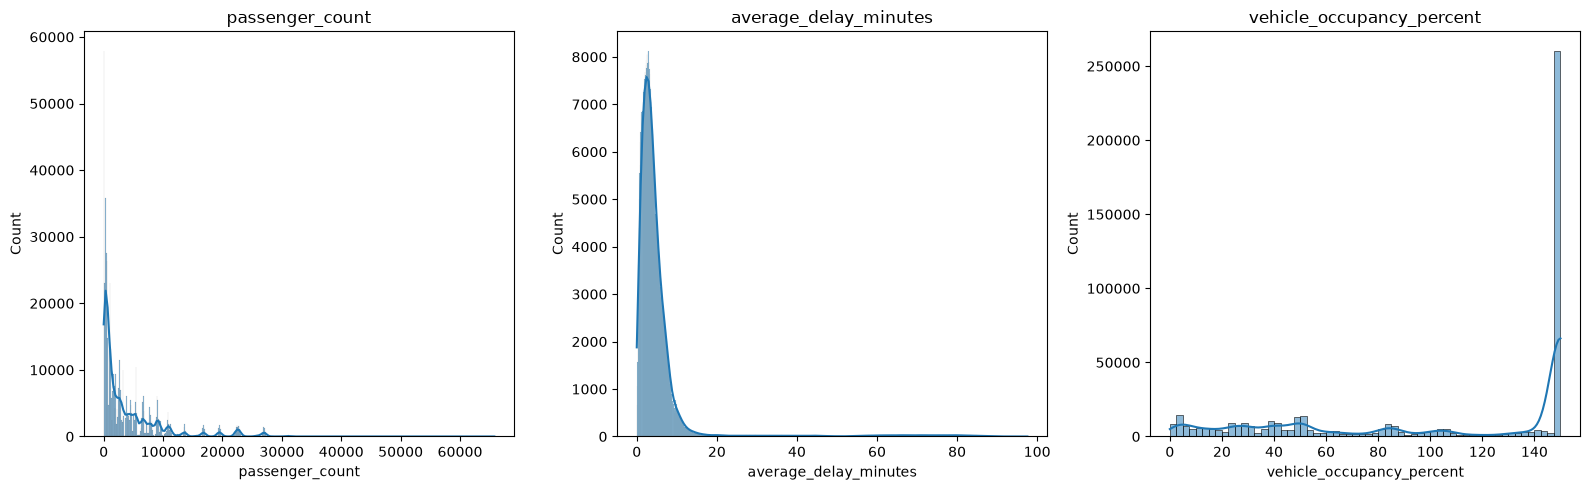

In [232]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for i, col in enumerate(transport_numeric_cols):
    sns.histplot(public_transport_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()

In [233]:
public_transport_clean[transport_numeric_cols].skew()

passenger_count              2.364381
average_delay_minutes        6.015631
vehicle_occupancy_percent   -0.575018
dtype: Float64

In [234]:
for col in transport_numeric_cols:
    n_out = len(iqr_outliers(public_transport_clean[col]))
    print(f"{col}:\t{n_out} outliers ({n_out/len(public_transport_clean)*100:.2f}%)")

passenger_count:	33335 outliers (6.40%)
average_delay_minutes:	27318 outliers (5.25%)
vehicle_occupancy_percent:	0 outliers (0.00%)


In [235]:
public_transport_clean['service_frequency'].value_counts()

service_frequency
10    303749
5     108569
30    108520
Name: count, dtype: Int64

#### Insights: Distribution, Skew & Outliers 

- `passenger_count` and `average_delay_minutes` are strongly right-skewed (2.36, 6.02) — 
  most readings are low/typical, with a real tail of high-ridership and high-delay events.
- `vehicle_occupancy_percent` is left-skewed (-0.58), driven by a massive spike at its 
  150.0 ceiling (~260K rows) — confirms this is a hard cap, not open-ended, with the 
  majority of high-occupancy readings piling up exactly at the limit. Zero IQR outliers 
  because a ceiling this heavily populated can't be statistically "extreme."
- `service_frequency`'s 3 tiers are unevenly used: the 10-min tier dominates (58%), while 
  5-min (rush) and 30-min (night) each cover ~21% — consistent with rush hours being a 
  smaller fraction of the day than regular daytime service.
- **Decision:** no values removed or capped. Ceiling-clustered occupancy and skewed 
  delay/ridership tails both represent real operational conditions (overcrowding, service 
  disruption) worth validation.

<a id="s6-4"></a>

### 6.4 Trends over time

*Why we run this.* Chapter 3 established a very specific daily signature for road traffic: a night
trough, a midday plateau, a sharp weekday double peak, and completely flat weekends. If transit
shows the same signature, the two systems are responding to one underlying commuting rhythm.

- **`day_of_week` and a rebuilt `weekend_flag`** — this file has no weekend flag of its own, so we
  derive one (`dayofweek >= 5`). Chapter 3 verified that exact rule against `traffic.csv`'s own
  flag, so we can reuse it with confidence.
- **Hourly aggregation** — the daily profile of ridership, delay and occupancy.
- **Weekend comparison and the hour × weekend unstack** — the same weekday/weekend split used in
  §3.7, so the two files can be compared directly.
- **Plots** — note `secondary_y` on the first: passenger counts run in the thousands and delays in
  single-digit minutes, so a second axis is what makes both curves readable together.

In [236]:
public_transport_clean['day_of_week'] = public_transport_clean['timestamp'].dt.dayofweek
public_transport_clean['weekend_flag'] = (public_transport_clean['day_of_week'] >= 5).astype(int)

In [237]:
public_transport_clean.head()

,timestamp,district_id,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,sensor_status,hour,day_of_week,weekend_flag
0,2023-01-01,D01,527,30,1.255956,131.75,0,Normal,0,6,1
1,2023-01-01,D20,161,30,0.664157,40.25,0,Normal,0,6,1
2,2023-01-01,D18,270,30,2.619722,67.50,0,Normal,0,6,1
3,2023-01-01,D17,75,30,1.486537,18.75,0,Normal,0,6,1
4,2023-01-01,D16,44,30,3.735659,11.00,0,Normal,0,6,1


In [238]:
hourly_public_transport = public_transport_clean.groupby('hour')[['passenger_count', 'average_delay_minutes', 'vehicle_occupancy_percent']].mean()
hourly_public_transport

,passenger_count,average_delay_minutes,vehicle_occupancy_percent
hour,,,
0,332.035555,3.714473,70.052121
1,332.275052,3.385458,70.115020
2,331.378453,3.168042,69.969095
3,330.743884,3.160394,69.953064
4,331.568625,3.314073,70.028530
5,3304.753962,3.286147,110.306230
6,3313.868706,5.318515,110.316618
7,7316.443564,6.932294,113.588142
8,7304.506428,7.020992,113.567487


In [239]:
weekend_compare = public_transport_clean.groupby('weekend_flag')[['passenger_count', 'average_delay_minutes', 'vehicle_occupancy_percent']].mean()
weekend_compare

,passenger_count,average_delay_minutes,vehicle_occupancy_percent
weekend_flag,,,
0,4693.585882,5.734442,107.481546
1,1828.427509,4.389509,91.564078


In [240]:
hourly_by_weekend = public_transport_clean.groupby(['hour', 'weekend_flag'])['passenger_count'].mean().unstack()
hourly_by_weekend.columns = ['Weekday', 'Weekend']
hourly_by_weekend

,Weekday,Weekend
hour,,
0,374.941473,224.583549
1,375.577236,224.155631
2,374.588201,223.458454
3,373.047005,224.856359
4,374.713935,223.962331
5,3727.561694,2245.54958
6,3740.325338,2246.522834
7,9343.380866,2240.264772
8,9324.549288,2244.286014


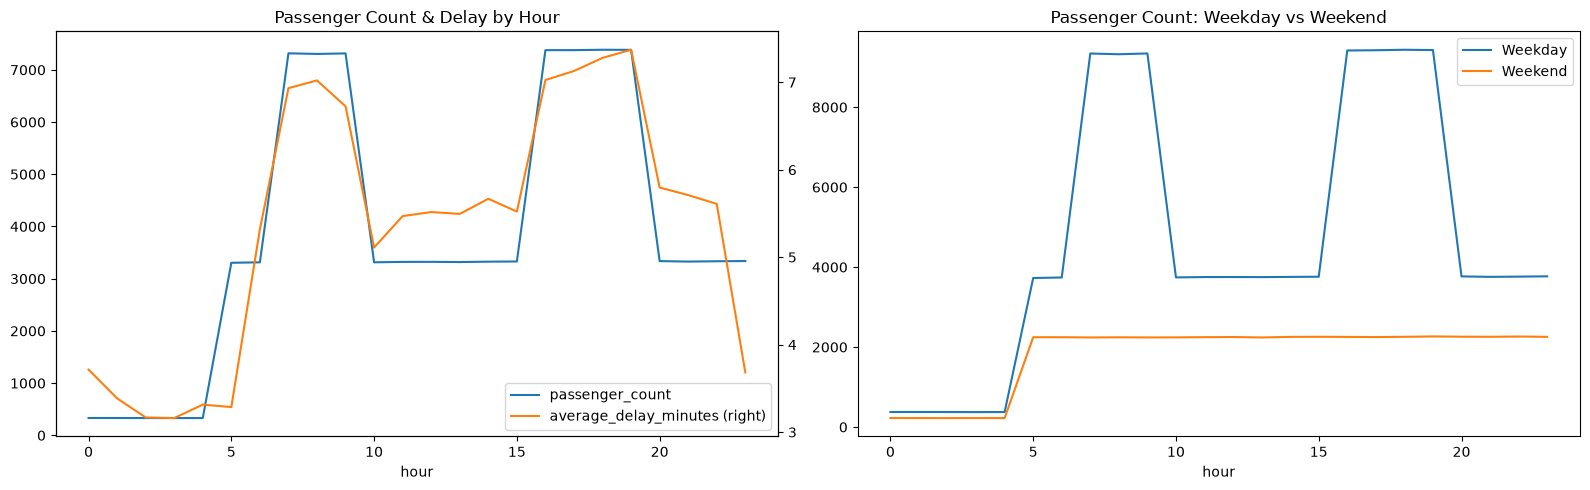

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
hourly_public_transport[['passenger_count', 'average_delay_minutes']].plot(ax=axes[0], title='Passenger Count & Delay by Hour', secondary_y='average_delay_minutes')
hourly_by_weekend.plot(ax=axes[1], title='Passenger Count: Weekday vs Weekend')
plt.tight_layout()

#### Insights: Time Trends 

- Passenger count follows the same three-tier daily structure as traffic.csv: a low 
  overnight base (~331), a moderate midday/off-peak plateau (~3,300-3,330), and two sharp 
  rush-hour peaks (~7,300-7,385) at hours 7-9 and 16-19.
- `average_delay_minutes` and `vehicle_occupancy_percent` both track passenger_count's 
  shape closely — busier hours mean both slower service and higher occupancy, consistent 
  with overcrowding degrading punctuality.
- Weekday vs weekend mirrors traffic.csv exactly: weekdays show a sharp double-peak rush 
  hour (up to ~9,437 riders), while weekends stay on a flat, low plateau (~2,240-2,266) 
  all day with no rush bump at all — rush hour is purely a weekday, commute-driven 
  phenomenon here too, not a general "busy time of day" effect.

<a id="s6-5"></a>

### 6.5 Relationships and flag validation

*Why we run this.* One expectation to test and one flag to validate.

The expectation: `passenger_count` and `vehicle_occupancy_percent` should be nearly the same
quantity expressed two ways. The correlation matrix tests that, and the answer is more interesting
than a confirmation would have been.

The flag: `service_disruption_flag` is checked the usual way — group means on the variables it
should affect. Both delay *and* ridership are included, because a disruption might plausibly reduce
demand as well as punctuality, and it is worth knowing whether it does.

In [242]:
public_transport_clean[transport_numeric_cols].corr()

,passenger_count,average_delay_minutes,vehicle_occupancy_percent
passenger_count,1.000000,0.166812,0.541114
average_delay_minutes,0.166812,1.000000,0.121395
vehicle_occupancy_percent,0.541114,0.121395,1.000000


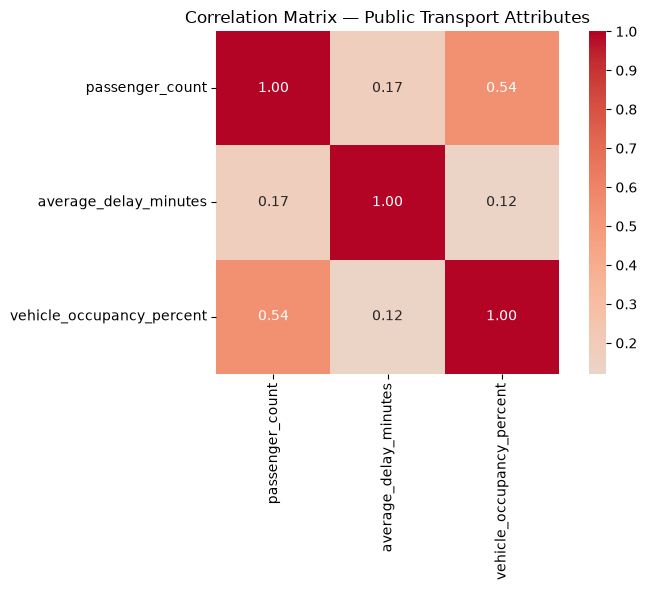

In [243]:
plt.figure(figsize=(8,6))
sns.heatmap(public_transport_clean[transport_numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Public Transport Attributes')
plt.tight_layout()

In [244]:
public_transport_clean.groupby('service_disruption_flag')[['average_delay_minutes', 'passenger_count']].mean()

,average_delay_minutes,passenger_count
service_disruption_flag,,
0,3.896557,3861.38935
1,56.692563,4369.504114


#### Insights: Relationships & Flag Validation 

- `passenger_count` and `vehicle_occupancy_percent` correlate only moderately (r=0.54) — 
  weaker than expected if occupancy were a direct linear function of ridership. Likely 
  explanation: vehicle capacity varies by route/type, so identical passenger counts 
  produce different occupancy% depending on the vehicle; occupancy's heavy clustering at 
  its 150.0 ceiling further compresses the relationship.
- `average_delay_minutes` correlates weakly with both passenger_count (0.17) and 
  occupancy (0.12) — crowding alone isn't a strong driver of delay; something else 
  (disruptions) matters more, confirmed directly below.
- `service_disruption_flag` is extremely meaningful: flagged rows average 56.7 minutes 
  of delay vs. 3.9 minutes normally — a ~14.5x jump, the strongest flag-validation gap 
  of any file in this project. Passenger count is barely affected (4,370 vs 3,861) — 
  disruptions cripple punctuality without meaningfully reducing ridership.

<a id="s6-6"></a>

### 6.6 District, traffic and weather context

*Why we run this.* Three cross-table questions, each with its own merge.

**(a) Does better transit access mean less delay?** The intuitive hypothesis. We aggregate to
district level and join `public_transport_access_index` from `districts.csv`. The result comes out
*backwards*, and the explanation — visible by comparing the district-level correlation against the
row-level one — is one of the more useful methodological findings in the notebook.

**(b) Does road congestion spill into transit delay?** An hourly inner join to `traffic_clean`,
pulling only `congestion_index`.

**(c) Does weather move people onto transit?** An hourly inner join to `weather_clean`, tested two
ways: continuous `rainfall_mm` correlation, and a group comparison on `storm_flag`. As in Chapter 4,
the continuous and discrete versions disagree, and the disagreement is the finding.

In [245]:
district_transport = public_transport_clean.groupby('district_id', as_index=False)[['passenger_count', 'average_delay_minutes']].mean()
district_transport

,district_id,passenger_count,average_delay_minutes
0,D01,9588.478796,6.178361
1,D02,3417.226875,5.466407
2,D03,504.788334,3.965847
3,D04,11330.143876,6.318329
4,D05,9419.918919,5.723617
5,D06,7064.229985,5.649497
6,D07,8208.166065,6.131079
7,D08,1791.118399,4.924150
8,D09,5723.759068,6.332414
9,D10,378.464343,4.286131


In [246]:
district_transport = district_transport.merge(districts[['district_id', 'public_transport_access_index']], on='district_id')
district_transport

,district_id,passenger_count,average_delay_minutes,public_transport_access_index
0,D01,9588.478796,6.178361,95
1,D02,3417.226875,5.466407,90
2,D03,504.788334,3.965847,40
3,D04,11330.143876,6.318329,75
4,D05,9419.918919,5.723617,70
5,D06,7064.229985,5.649497,60
6,D07,8208.166065,6.131079,65
7,D08,1791.118399,4.924150,85
8,D09,5723.759068,6.332414,80
9,D10,378.464343,4.286131,90


In [247]:
district_transport[['public_transport_access_index', 'passenger_count', 'average_delay_minutes']].corr()

,public_transport_access_index,passenger_count,average_delay_minutes
public_transport_access_index,1.000000,0.188582,0.326187
passenger_count,0.188582,1.000000,0.645545
average_delay_minutes,0.326187,0.645545,1.000000


- `public_transport_access_index` does NOT predict lower delay (r=0.33, positive).<br> Likely explanation: high-access districts also 
  carry higher ridership, and at the district level, ridership itself is a much stronger 
  delay driver (r=0.65) than it appeared row-by-row (r=0.17). Aggregating to 
  district level reveals a real structural pattern that hourly noise obscured: 
  consistently busy districts are consistently slower, even though any single busy hour 
  doesn't strongly predict that hour's delay.

In [248]:
transport_traffic = public_transport_clean.merge(traffic_clean[['timestamp', 'district_id', 'congestion_index']], on=['timestamp', 'district_id'], how='inner')
transport_traffic

,timestamp,district_id,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,sensor_status,hour,day_of_week,weekend_flag,congestion_index
0,2023-01-01 00:00:00,D01,527,30,1.255956,131.75,0,Normal,0,6,1,6.675445
1,2023-01-01 00:00:00,D20,161,30,0.664157,40.25,0,Normal,0,6,1,7.794341
2,2023-01-01 00:00:00,D18,270,30,2.619722,67.50,0,Normal,0,6,1,8.085675
3,2023-01-01 00:00:00,D17,75,30,1.486537,18.75,0,Normal,0,6,1,5.648994
4,2023-01-01 00:00:00,D16,44,30,3.735659,11.00,0,Normal,0,6,1,4.939799
...,...,...,...,...,...,...,...,...,...,...,...,...
515647,2025-12-31 23:00:00,D02,3710,10,1.558607,150.00,0,Normal,23,2,0,8.515647
515648,2025-12-31 23:00:00,D01,10287,10,1.041389,150.00,0,Normal,23,2,0,10.462134
515649,2025-12-31 23:00:00,D19,3292,10,0.315060,150.00,0,Normal,23,2,0,0.328767
515650,2025-12-31 23:00:00,D09,6298,10,3.088045,150.00,0,Normal,23,2,0,14.686530


In [249]:
transport_traffic[['congestion_index', 'average_delay_minutes']].corr()

,congestion_index,average_delay_minutes
congestion_index,1.000000,0.331468
average_delay_minutes,0.331468,1.000000


- Road congestion spills over into transit delay, 
  `congestion_index` correlates 0.33 with `average_delay_minutes` — real but moderate, 
  not dominant.

In [250]:
transport_weather = public_transport_clean.merge(weather_clean[['timestamp', 'district_id', 'rainfall_mm', 'storm_flag']], on=['timestamp', 'district_id'], how='inner')
transport_weather

,timestamp,district_id,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,sensor_status,hour,day_of_week,weekend_flag,rainfall_mm,storm_flag
0,2023-01-01 00:00:00,D01,527,30,1.255956,131.75,0,Normal,0,6,1,0.000000,0
1,2023-01-01 00:00:00,D20,161,30,0.664157,40.25,0,Normal,0,6,1,0.000000,0
2,2023-01-01 00:00:00,D18,270,30,2.619722,67.50,0,Normal,0,6,1,0.000000,0
3,2023-01-01 00:00:00,D17,75,30,1.486537,18.75,0,Normal,0,6,1,0.000000,0
4,2023-01-01 00:00:00,D16,44,30,3.735659,11.00,0,Normal,0,6,1,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514346,2025-12-31 23:00:00,D02,3710,10,1.558607,150.00,0,Normal,23,2,0,0.446288,0
514347,2025-12-31 23:00:00,D01,10287,10,1.041389,150.00,0,Normal,23,2,0,0.715818,0
514348,2025-12-31 23:00:00,D19,3292,10,0.315060,150.00,0,Normal,23,2,0,0.268990,0
514349,2025-12-31 23:00:00,D09,6298,10,3.088045,150.00,0,Normal,23,2,0,0.414624,0


In [251]:
transport_weather.groupby('storm_flag')['passenger_count'].mean()

storm_flag
0    3861.722467
1    4628.108803
Name: passenger_count, dtype: Float64

In [252]:
transport_weather[['rainfall_mm', 'passenger_count']].corr()

,rainfall_mm,passenger_count
rainfall_mm,1.000000,0.020136
passenger_count,0.020136,1.000000


- Storms shift ridership toward transit: storm-flagged hours average 20% higher 
  passenger_count (4,628 vs 3,862). But raw `rainfall_mm` shows almost no correlation 
  (0.02) — same pattern seen elsewhere in this project: mild continuous rain doesn't 
  change behavior, but a discrete, severe weather event (storm) does. The flag captures 
  this; the continuous variable doesn't.

<a id="s6-7"></a>

### 6.7 Chapter takeaways

**Transit mirrors road traffic almost exactly.** The same three-tier daily structure — night trough
(~331), midday plateau (~3,300), sharp double peak (~7,300–7,385) at hours 7–9 and 16–19 — and the
same weekday-only pattern, with weekends flat all day (~2,240–2,266) and no bump at all.

**Service is demand-responsive, not static.** `service_frequency` matches rush-hour timing exactly
(most frequent during 7–9 / 16–19), the same windows `traffic.csv`'s `rush_hour_flag` marks. Strong
cross-file consistency.

**Overcrowding is real and deliberately encoded.** 58% of readings exceed 100% occupancy, capped at
150 — a genuine standing-passenger signal, heavily clustered at the ceiling, not an error.

**`service_disruption_flag` is the strongest flag validation in the project**: flagged rows average
56.7 minutes of delay against 3.9 normally (~14.5×), while ridership is barely affected. Disruptions
cripple punctuality without reducing demand.

**Road congestion spills into transit delay** (r = 0.33) — real, but moderate rather than dominant.

**Storms push riders onto transit**: storm-flagged hours carry ~20% higher ridership, even though
continuous rainfall correlates at essentially zero (0.02).

**No values were dropped or capped**; the null pattern was the familiar outage mechanism for the
fifth file running.

> **Pitfalls and surprises in this chapter.**
>
> - **Ridership and occupancy correlate only 0.54**, far weaker than expected for what looks like
>   one quantity in two framings. The likely reasons: vehicle capacity varies by route and type, so
>   identical passenger counts map to different occupancy percentages; and the pile-up at the 150.0
>   ceiling compresses the relationship further.
> - **A counterintuitive positive correlation** between `public_transport_access_index` and delay
>   (r = 0.33 rather than negative). Resolved by changing aggregation level: at district level
>   ridership predicts delay strongly (r = 0.65) where row-by-row it barely did (0.17). High-access
>   districts are simply busy districts, and busyness drives the delay.
> - **The general lesson worth carrying beyond this file**: *the same two variables can look weakly
>   related row-by-row and strongly related once aggregated.* Choosing the wrong level of
>   aggregation can hide a real structural pattern under hourly noise.

---
<a id="ch7"></a>

# Part III — The event logs

## 7. `city_events.csv` — planned events and their citywide footprint

[↑ back to contents](#toc)

**What this file is.** A departure from everything before it. Not an hourly sensor feed but a
**discrete event log**: 300 rows, one per planned city event, each with a start and end timestamp
and a host district.

**What each row carries.**

- **Identity**: `event_id` (a true primary key, unlike the composite keys elsewhere), `event_type`
  (10 categories), `district_id`
- **Timing**: `start_timestamp`, `end_timestamp`
- **Scale**: `expected_attendance`, `actual_attendance`, `event_impact_level`

**Three consequences of being an event log.** There is no `sensor_status` column and no missing data
at all, so the null-handling step has nothing to do. There is no hourly grid, so joins to the fact
tables cannot be exact-key merges. And the file's real value is not in its own columns but in what
happens to the *rest of the city* while an event is running.

**Questions this chapter answers**

1. Do event types differ in scale, and does that scale explain anything else?
2. Does `event_impact_level` measure crowd size, event length, or both?
3. Which districts actually host events — and does the intuitive answer survive normalisation?
4. **The capstone question:** when a large event runs, what measurably happens to traffic, transit,
   power and air quality — compared to what normally happens in that district at that hour?

<a id="s7-1"></a>

### 7.1 Loading, types and a new engineered feature

*Why we run this.* Inventory, type conversions, and the one genuinely new feature engineered in this
notebook.

- **`head` / `shape` / `info`** — the inventory.
- **Two `to_datetime` conversions** — both start and end, since the duration calculation needs both.
- **`duplicated(subset=['event_id'])`** — confirms `event_id` is a real primary key.
- **`value_counts` on type and impact level** — the category inventory. Impact level is then cast to
  an ordered `Categorical` (Low < Medium < High < Extreme), the same treatment
  `air_quality_category` received in Chapter 5.
- **`event_duration`** — the new feature: `(end − start)` converted to hours. This is not a
  validation of something that shipped with the file; it is information that only exists once the
  two timestamps are differenced, and it lets us ask whether "impact" is about crowd size or length.
- **`isna().any()`** — confirms there is nothing to clean.

In [253]:
city_events = pd.read_csv('data/city_events.csv')

In [254]:
city_events.head(10)

,event_id,event_name,event_type,district_id,start_timestamp,end_timestamp,expected_attendance,actual_attendance,event_impact_level
0,EVT_0001,Conference 2025,Conference,D08,2025-09-21 16:00:00,2025-09-21 19:00:00,6468,6488,Medium
1,EVT_0002,Marathon 2023,Marathon,D18,2023-04-12 18:00:00,2023-04-12 22:00:00,78082,58674,Extreme
2,EVT_0003,Marathon 2024,Marathon,D01,2024-05-01 18:00:00,2024-05-01 22:00:00,29996,29136,High
3,EVT_0004,Conference 2025,Conference,D15,2025-05-12 11:00:00,2025-05-12 20:00:00,3032,2743,Low
4,EVT_0005,Political Event 2025,Political Event,D08,2025-12-12 13:00:00,2025-12-13 00:00:00,2771,2270,Low
5,EVT_0006,Public Holiday 2025,Public Holiday,D11,2025-03-03 15:00:00,2025-03-03 21:00:00,20816,18316,High
6,EVT_0007,Political Event 2024,Political Event,D12,2024-06-09 09:00:00,2024-06-09 14:00:00,3033,2932,Medium
7,EVT_0008,Market 2025,Market,D12,2025-09-25 09:00:00,2025-09-25 16:00:00,5494,5831,Low
8,EVT_0009,Conference 2023,Conference,D04,2023-05-09 17:00:00,2023-05-10 03:00:00,2828,2704,Low
9,EVT_0010,Political Event 2025,Political Event,D16,2025-08-14 15:00:00,2025-08-15 01:00:00,9202,6871,Medium


In [255]:
city_events.shape

(300, 9)

In [256]:
city_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   event_id             300 non-null    str  
 1   event_name           300 non-null    str  
 2   event_type           300 non-null    str  
 3   district_id          300 non-null    str  
 4   start_timestamp      300 non-null    str  
 5   end_timestamp        300 non-null    str  
 6   expected_attendance  300 non-null    int64
 7   actual_attendance    300 non-null    int64
 8   event_impact_level   300 non-null    str  
dtypes: int64(2), str(7)
memory usage: 21.2 KB


In [257]:
city_events['start_timestamp'] = pd.to_datetime(city_events['start_timestamp'], errors='coerce')
city_events['end_timestamp'] = pd.to_datetime(city_events['end_timestamp'], errors='coerce')

In [258]:
city_events.duplicated(subset=['event_id']).sum()

np.int64(0)

In [259]:
city_events['event_type'].value_counts()

event_type
Public Holiday       38
Conference           36
Market               35
Parade               35
Marathon             31
Political Event      30
Cultural Festival    28
Concert              25
Festival             23
Football Match       19
Name: count, dtype: int64

In [260]:
city_events['event_impact_level'].value_counts()

event_impact_level
High       134
Medium      72
Low         57
Extreme     37
Name: count, dtype: int64

In [261]:
ordered_impact_levels = ['Low', 'Medium', 'High', 'Extreme']
city_events['event_impact_level'] = pd.Categorical(city_events['event_impact_level'], categories=ordered_impact_levels, ordered=True)

In [262]:
city_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   event_id             300 non-null    str           
 1   event_name           300 non-null    str           
 2   event_type           300 non-null    str           
 3   district_id          300 non-null    str           
 4   start_timestamp      300 non-null    datetime64[us]
 5   end_timestamp        300 non-null    datetime64[us]
 6   expected_attendance  300 non-null    int64         
 7   actual_attendance    300 non-null    int64         
 8   event_impact_level   300 non-null    category      
dtypes: category(1), datetime64[us](2), int64(2), str(4)
memory usage: 19.4 KB


In [263]:
# duration in hours
city_events['event_duration'] = (city_events['end_timestamp'] - city_events['start_timestamp']).dt.total_seconds() / 3600
city_events.head()

,event_id,event_name,event_type,district_id,start_timestamp,end_timestamp,expected_attendance,actual_attendance,event_impact_level,event_duration
0,EVT_0001,Conference 2025,Conference,D08,2025-09-21 16:00:00,2025-09-21 19:00:00,6468,6488,Medium,3.0
1,EVT_0002,Marathon 2023,Marathon,D18,2023-04-12 18:00:00,2023-04-12 22:00:00,78082,58674,Extreme,4.0
2,EVT_0003,Marathon 2024,Marathon,D01,2024-05-01 18:00:00,2024-05-01 22:00:00,29996,29136,High,4.0
3,EVT_0004,Conference 2025,Conference,D15,2025-05-12 11:00:00,2025-05-12 20:00:00,3032,2743,Low,9.0
4,EVT_0005,Political Event 2025,Political Event,D08,2025-12-12 13:00:00,2025-12-13 00:00:00,2771,2270,Low,11.0


#### Null checks

In [264]:
city_events.isna().any()

event_id               False
event_name             False
event_type             False
district_id            False
start_timestamp        False
end_timestamp          False
expected_attendance    False
actual_attendance      False
event_impact_level     False
event_duration         False
dtype: bool

#### Insights: Consistency, dtypes & Null Handling

- `event_id` is confirmed unique across all 300 rows — a genuine primary key, unlike the 
  composite (timestamp, district_id) key used in every other file so far.
- `event_type` has 10 categories fairly evenly represented (19-38 events each) — no single 
  event type dominates the dataset, good for later per-type comparisons in 4.B/4.C.
- `event_impact_level` cast as an ordered category (Low < Medium < High < Extreme), 
  matching the same approach used for `air_quality_category`.
- `event_duration` (hours) is a genuinely new engineered feature this file didn't ship 
  with — computed directly from start/end timestamps, ranging from a few hours 
  (Conference) to overnight spans (Political Event, Market).
- No nulls anywhere in the file — unlike every previous file, this table has no 
  `sensor_status` column and no sensor-outage mechanism at all, since it's a discrete 
  event log rather than a continuous hourly sensor feed. Step 3 (null handling) is 
  effectively already complete with nothing to drop.

<a id="s7-2"></a>

### 7.2 Attendance, duration and event scale

*Why we run this.* Establishing whether "event type" is a meaningful grouping variable or just a
label. If the types separate cleanly by attendance, that tiering becomes the lens for the rest of
the chapter.

- **`describe()`** — the overall ranges for attendance and duration.
- **Mean expected vs actual attendance by type, sorted** — a grouped **bar chart** is deliberately
  chosen here. An earlier version used boxplots, but boxplots answer "what is the spread and where
  are the outliers?" while this question is "how do the types rank?" — which bars answer far more
  directly. Plotting expected and actual side by side also exposes a consistent gap between them.
- **Boxplot of duration by type** — here the boxplot *is* the right choice, because the question is
  about overlap and spread rather than ranking.
- **`skew()`** — confirms the attendance right-skew that the three-tier structure creates.

In [265]:
city_events[['expected_attendance', 'actual_attendance', 'event_duration']].describe()

,expected_attendance,actual_attendance,event_duration
count,300.000000,300.00000,300.000000
mean,22502.606667,20031.60000,6.826667
std,20733.043514,18400.27457,2.581764
min,1016.000000,859.00000,3.000000
25%,5972.250000,5480.25000,5.000000
50%,15562.000000,14753.00000,7.000000
75%,34256.250000,29182.25000,9.000000
max,79890.000000,77608.00000,11.000000


In [266]:
attendance_by_type = city_events.groupby('event_type')[['expected_attendance', 'actual_attendance']].mean().sort_values('expected_attendance', ascending=False)
attendance_by_type


,expected_attendance,actual_attendance
event_type,,
Concert,53210.600000,47567.240000
Marathon,49629.193548,43343.096774
Football Match,47529.894737,41551.894737
Parade,24793.857143,23063.114286
Festival,24208.869565,21769.173913
Public Holiday,23267.210526,20347.736842
Cultural Festival,5743.321429,4972.142857
Political Event,5714.333333,5251.500000
Market,4845.771429,4614.628571


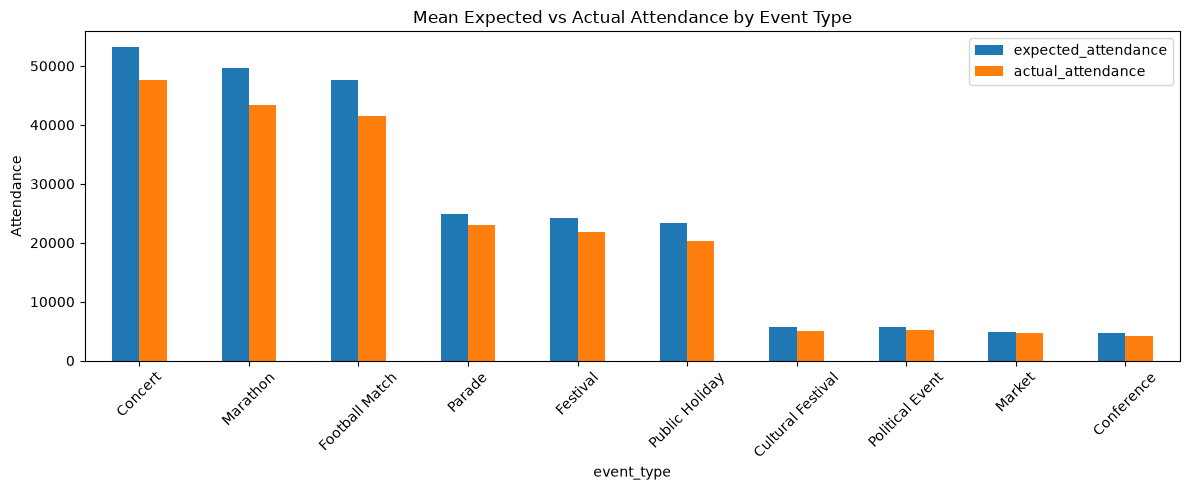

In [267]:
attendance_by_type.plot(kind='bar', figsize=(12,5))
plt.title('Mean Expected vs Actual Attendance by Event Type')
plt.ylabel('Attendance')
plt.xticks(rotation=45)
plt.tight_layout()

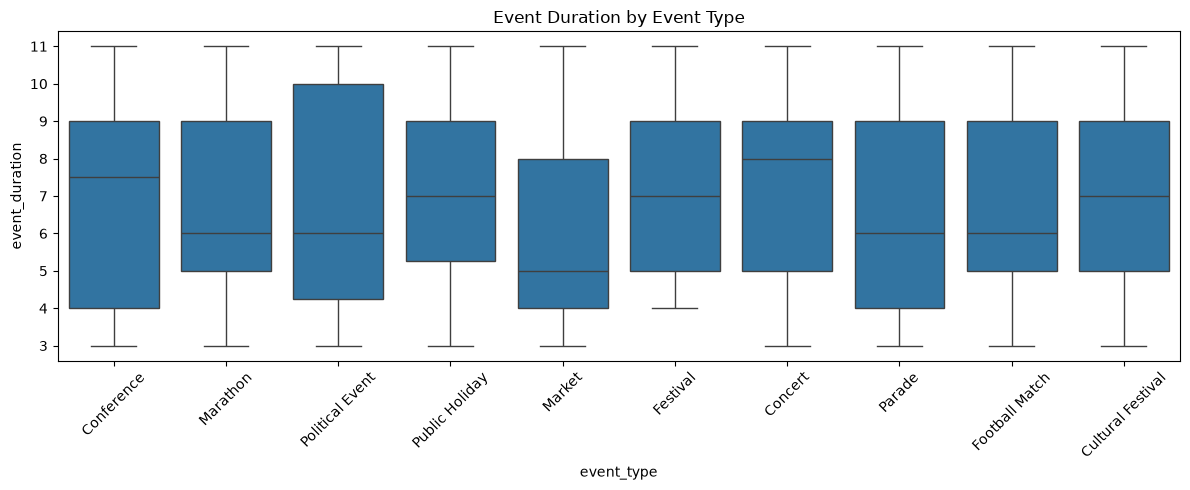

In [268]:
plt.figure(figsize=(12,5))
sns.boxplot(data=city_events, x='event_type', y='event_duration')
plt.xticks(rotation=45)
plt.title('Event Duration by Event Type')
plt.tight_layout()

In [269]:
city_events[['expected_attendance', 'actual_attendance', 'event_duration']].skew()

expected_attendance    1.116059
actual_attendance      1.118988
event_duration         0.082549
dtype: float64

#### Insights: Distribution 

- Event types fall into 3 clear attendance tiers: `large-scale` (Concert, Marathon, Football 
  Match, ~42K-53K expected),` mid-scale `(Parade, Festival, Public Holiday, ~20K-25K), and 
  `small-scale` (Cultural Festival, Political Event, Market, Conference, ~5K-6K). This 
  explains attendance's right-skew (1.12) — it's not one smooth distribution, but three 
  distinct event scales layered together.
- Actual attendance is lower than expected for every single event type — under-turnout is a universal pattern in this dataset, 
  worth quantifying precisely as a turnout_ratio
- `event_duration` shows no meaningful difference by event type (medians 5-8 hours, 
  heavily overlapping ranges) and is nearly symmetric (skew 0.08) — duration is 
  independent of what kind of event it is.

<a id="s7-3"></a>

### 7.3 When events happen

*Why we run this.* Testing whether event scheduling is random or seasonal — both overall and per
type. A citywide monthly count could look perfectly flat while individual event types cluster hard
in particular months, so we look at both.

- **`month` column and monthly counts** — the overall distribution, plus its mean as a reference for
  what "normal" looks like.
- **`crosstab(month, event_type)` + heatmap** — the per-type view. With only ~19–38 events per type
  spread over 12 months, most cells are small; the heatmap makes the genuine 5+ spikes stand out
  from ordinary small-sample noise.

In [270]:
city_events['month'] = city_events['start_timestamp'].dt.month
city_events

,event_id,event_name,event_type,district_id,start_timestamp,end_timestamp,expected_attendance,actual_attendance,event_impact_level,event_duration,month
0,EVT_0001,Conference 2025,Conference,D08,2025-09-21 16:00:00,2025-09-21 19:00:00,6468,6488,Medium,3.0,9
1,EVT_0002,Marathon 2023,Marathon,D18,2023-04-12 18:00:00,2023-04-12 22:00:00,78082,58674,Extreme,4.0,4
2,EVT_0003,Marathon 2024,Marathon,D01,2024-05-01 18:00:00,2024-05-01 22:00:00,29996,29136,High,4.0,5
3,EVT_0004,Conference 2025,Conference,D15,2025-05-12 11:00:00,2025-05-12 20:00:00,3032,2743,Low,9.0,5
4,EVT_0005,Political Event 2025,Political Event,D08,2025-12-12 13:00:00,2025-12-13 00:00:00,2771,2270,Low,11.0,12
...,...,...,...,...,...,...,...,...,...,...,...
295,EVT_0296,Public Holiday 2025,Public Holiday,D11,2025-08-22 10:00:00,2025-08-22 18:00:00,15498,14563,High,8.0,8
296,EVT_0297,Festival 2024,Festival,D08,2024-03-12 15:00:00,2024-03-12 20:00:00,23865,22773,High,5.0,3
297,EVT_0298,Public Holiday 2024,Public Holiday,D12,2024-12-08 18:00:00,2024-12-08 21:00:00,21181,20860,High,3.0,12
298,EVT_0299,Conference 2023,Conference,D07,2023-07-02 13:00:00,2023-07-02 22:00:00,4456,4154,Medium,9.0,7


In [271]:
city_events['month'].value_counts().mean()

np.float64(25.0)

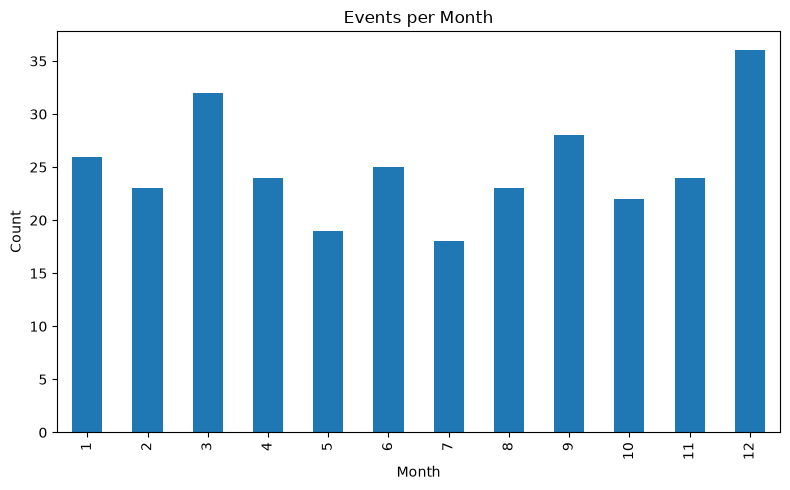

In [272]:
plt.figure(figsize=(8, 5))
city_events['month'].value_counts().sort_index().plot(kind='bar')
plt.title('Events per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [273]:
event_month = pd.crosstab(city_events['month'], city_events['event_type'])
event_month

event_type,Concert,Conference,Cultural Festival,Festival,Football Match,Marathon,Market,Parade,Political Event,Public Holiday
month,,,,,,,,,,
1,1,2,2,1,3,2,4,7,1,3
2,4,3,3,0,0,1,2,1,4,5
3,1,6,6,6,0,2,3,4,0,4
4,3,5,2,2,2,2,2,2,2,2
5,1,4,0,3,2,3,3,2,0,1
6,2,1,3,0,4,1,5,0,5,4
7,1,1,2,1,1,1,3,5,3,0
8,4,1,0,2,0,4,3,0,5,4
9,2,5,1,1,2,3,4,5,2,3


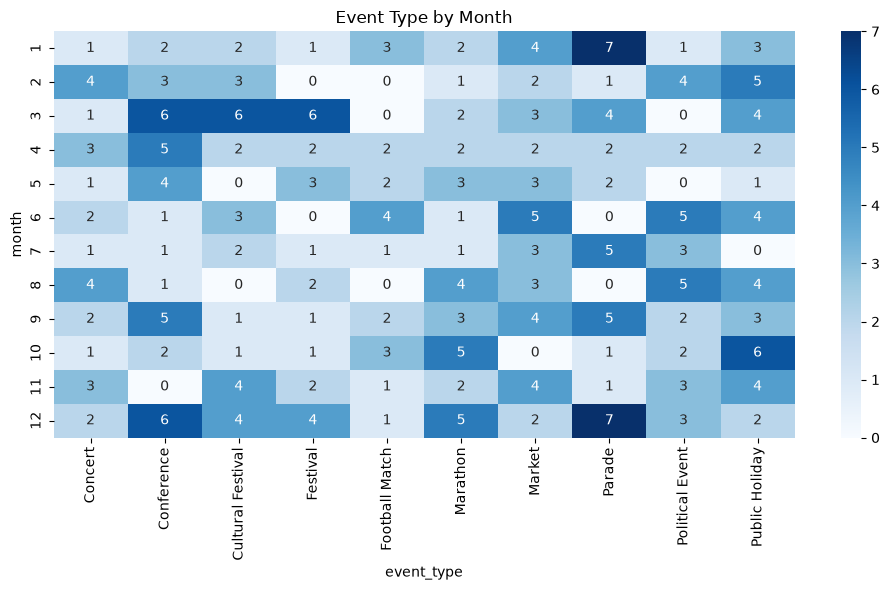

In [274]:
plt.figure(figsize=(10, 6))
sns.heatmap(event_month, cmap='Blues', annot=True, fmt='d')
plt.title('Event Type by Month')
plt.tight_layout()
plt.show()

#### Insights: Time Trends 

- Events are scheduled fairly evenly across the year overall (18-36 per month), with 
  December (36) and March (32) as the two busiest months — no single month dominates 
  or is empty.
- Specific event types DO cluster seasonally, contradicting a "fully random" scheduling 
  assumption: `Parade` peaks at both year-end and year-start (7 in December, 7 in 
  January) — likely holiday-season parades; `Public Holiday` spikes in October (6); 
  `Cultural Festival` and `Festival` both spike together in March (6 each).
- `Marathon`  clusters in three separate months (June, September, December, 5 each), suggesting a few dedicated 
  marathon events spread through the year rather than one seasonal window.
- With only ~19-38 events per type across 12 months, most month/type cells (0-4) reflect 
  normal small-sample variation rather than a real pattern — the 5+ spikes above are the 
  genuine seasonal signals worth remembering.

<a id="s7-4"></a>

### 7.4 Turnout ratio and impact-level validation

*Why we run this.* §7.2 showed actual attendance falling short of expected for every type. A ratio
turns that observation into a comparable number across events of wildly different sizes — a
1,000-person shortfall means something very different for a 5,000-person conference than for a
50,000-person marathon.

- **`turnout_ratio`** — `actual / expected`, the second engineered feature in this file.
- **Mean turnout by type, as a percentage** — is under-attendance type-specific or universal?
- **Attendance and duration grouped by `event_impact_level`** — the validation: comparing the flag
  against *both* candidate drivers at once shows which one it actually encodes.
- **Boxplot with a reference line at 1.0** — the horizontal line marks "attendance exactly as
  expected", so how far each type sits below it is readable at a glance.

In [275]:
city_events['turnout_ratio'] = city_events['actual_attendance'] / city_events['expected_attendance']
city_events.head()

,event_id,event_name,event_type,district_id,start_timestamp,end_timestamp,expected_attendance,actual_attendance,event_impact_level,event_duration,month,turnout_ratio
0,EVT_0001,Conference 2025,Conference,D08,2025-09-21 16:00:00,2025-09-21 19:00:00,6468,6488,Medium,3.0,9,1.003092
1,EVT_0002,Marathon 2023,Marathon,D18,2023-04-12 18:00:00,2023-04-12 22:00:00,78082,58674,Extreme,4.0,4,0.751441
2,EVT_0003,Marathon 2024,Marathon,D01,2024-05-01 18:00:00,2024-05-01 22:00:00,29996,29136,High,4.0,5,0.971330
3,EVT_0004,Conference 2025,Conference,D15,2025-05-12 11:00:00,2025-05-12 20:00:00,3032,2743,Low,9.0,5,0.904683
4,EVT_0005,Political Event 2025,Political Event,D08,2025-12-12 13:00:00,2025-12-13 00:00:00,2771,2270,Low,11.0,12,0.819199


In [276]:
(city_events.groupby('event_type')['turnout_ratio'].mean() * 100).sort_values()

event_type
Public Holiday       86.928615
Cultural Festival    87.853949
Conference           88.247765
Marathon             88.326572
Football Match       88.612892
Concert              88.985209
Festival             90.242236
Political Event      92.118270
Parade               92.653577
Market               93.525302
Name: turnout_ratio, dtype: float64

In [277]:
city_events.groupby('event_impact_level')[['actual_attendance', 'event_duration']].mean()

,actual_attendance,event_duration
event_impact_level,,
Low,5090.719298,6.736842
Medium,4387.388889,6.666667
High,24402.380597,6.940299
Extreme,57662.108108,6.864865


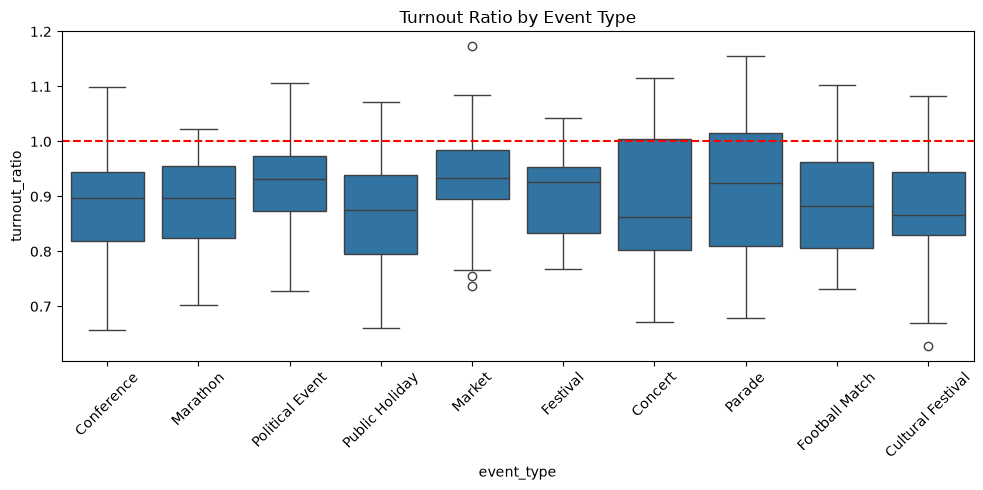

In [278]:
plt.figure(figsize=(10,5))
sns.boxplot(data=city_events, x='event_type', y='turnout_ratio')
plt.xticks(rotation=45)
plt.axhline(1.0, color='red', linestyle='--')
plt.title('Turnout Ratio by Event Type')
plt.tight_layout()

#### Insights: Turnout Ratio & Impact Level Validation 

- Turnout ratio is below 1.0 for every event type (86.9%-93.5%) — under-attendance is 
  universal, not type-specific, with a fairly narrow 6.6-point spread across all 10 
  types. This looks like a consistent ~10-15% shrinkage built into how the dataset was 
  generated, rather than a real behavioral signal worth attributing to any particular 
  event type.
- `event_impact_level` is strongly validated by `actual_attendance` — a clean, near-
  monotonic climb from Low (~5,091) to Extreme (~57,662), an ~11x range. It has almost 
  no relationship with `event_duration` (6.67-6.94 hours across all 4 levels) — impact 
  level reflects crowd size specifically, not how long an event runs.

<a id="s7-5"></a>

### 7.5 Which districts host events

*Why we run this.* A question where the obvious calculation gives the wrong answer, which is exactly
why the normalisation step matters.

- **Event count per district, joined to `district_type`** — the raw counts.
- **Sum by district type** — the tempting but misleading version: types with more districts
  accumulate more events automatically.
- **Events per district by type** — dividing by `districts['district_type'].value_counts()` corrects
  for that, and reverses the ranking.
- **Bar chart coloured by type** — the per-district view, showing how much variation exists *within*
  each type.

In [279]:
event_district = city_events.groupby('district_id', as_index=False)['event_id'].count().rename(columns={'event_id':'event_count'})
event_district = event_district.merge(districts[['district_id', 'district_type']], on='district_id')
event_district.sort_values('event_count', ascending=False).reset_index(drop=True)

,district_id,event_count,district_type
0,D17,23,Commercial
1,D08,21,Commercial
2,D19,20,Residential
3,D02,18,Commercial
4,D07,18,Residential
5,D11,16,Mixed
6,D12,16,Industrial
7,D18,16,Mixed
8,D05,15,Residential
9,D09,15,Mixed


In [280]:
event_district.groupby('district_type')['event_count'].sum().sort_values(ascending=False)

district_type
Commercial         91
Residential        86
Mixed              47
Industrial         30
Recreation         18
Public Services    14
Transport          14
Name: event_count, dtype: int64

In [281]:
# in the above cell we got the sum of events for each district type , but may be we got the most events are in the commercial districts
# just beacause there are more commercial districts than any other type, so we will calculate the average events per district type to make sure of this point 
district_counts = districts['district_type'].value_counts()
avg_events_per_type = (event_district.groupby('district_type')['event_count'].sum() / district_counts).sort_values(ascending=False)
avg_events_per_type

district_type
Commercial         18.200000
Mixed              15.666667
Industrial         15.000000
Residential        14.333333
Public Services    14.000000
Transport          14.000000
Recreation          9.000000
dtype: float64

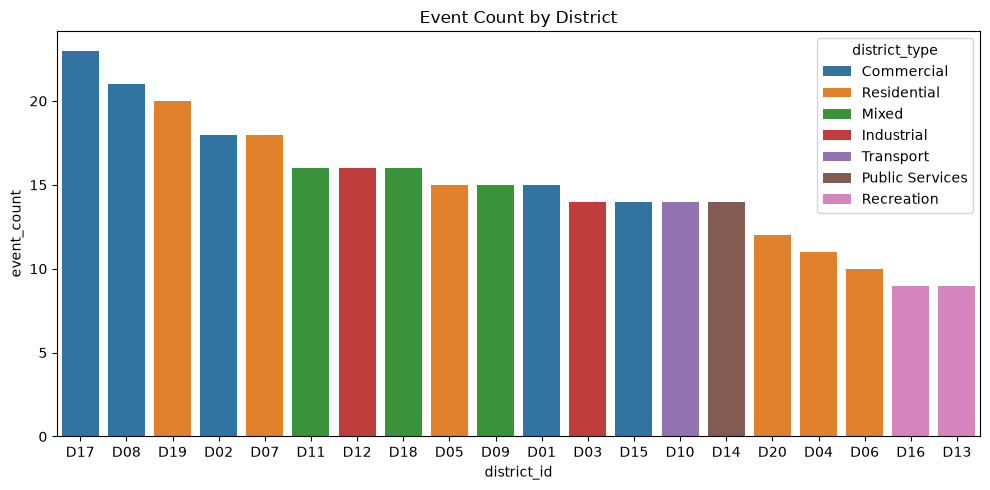

In [282]:
plt.figure(figsize=(10,5))
sns.barplot(data=event_district.sort_values('event_count', ascending=False), x='district_id', y='event_count', hue='district_type', dodge=False)
plt.title('Event Count by District')
plt.tight_layout()

#### Insights: District Distribution 

- Raw event counts are misleading without normalizing by how many districts exist per 
  type — Commercial (91 total) and Residential (86 total) look similar at first glance, 
  but Commercial only has 5 districts vs Residential's 6, so per-district averages tell 
  a different story.
- `Commercial districts` genuinely host the most events per district (18.2 avg) 
- `Recreation districts` — intuitively expected to be event hotspots — actually host the 
  FEWEST events per district (9.0 avg), about half Commercial's rate. This is a genuine 
  contradiction of the intuitive assumption, not a normalization artifact, and worth 
  flagging directly: whatever "Recreation" zoning represents in this dataset, it isn't 
  functioning as a major public-event venue type.
- `Mixed` (15.7) and `Industrial` (15.0) districts host events at a similar, moderate rate — 
  `Transport` and `Public Services` (14.0 each, though only 1 district each) sit close 
  behind.

<a id="s7-6"></a>

### 7.6 Measuring real event impact: a range join with a baseline

*Why we run this.* This is the methodological centrepiece of the notebook, and it needs two things
that no previous chapter required.

**First, a different kind of join.** Every merge so far has been an exact-key join on
`(timestamp, district_id)`. That is impossible here: an event is not an instant, it is a *window*
spanning several hours. `get_event_impact` therefore performs a **range join** — for each event, it
selects every fact-table row in the same district whose timestamp falls between the event's start
and end, and aggregates it. The function is written generically (`fact_df`, `value_col`, `agg`) so
the same logic serves all four fact tables.

**Second, a baseline.** Knowing that congestion averaged 45 during a marathon means nothing without
knowing what that district normally looks like at that hour. `get_baseline` builds the counterfactual:
same district, same hour of day, but excluding every timestamp that falls inside *any* event window
in that district. The difference between the two is the **uplift** — the event's actual effect,
with the district's normal daily rhythm subtracted out.

**A note on `itertuples()`.** The loop uses `itertuples()` rather than `iterrows()`. Both iterate
row by row, but `itertuples` returns lightweight named tuples instead of constructing a Series per
row, and the speed difference is meaningful at 300 events × 4 fact tables.

Cell by cell:

- **`get_event_impact`** — the range join.
- **First application** — congestion during each event, inspected on the first 10 rows before going
  further.
- **`get_baseline`** — the counterfactual builder.
- **Baseline + uplift for congestion** — the three columns (during / baseline / uplift) shown
  together, so the arithmetic is visible rather than hidden.
- **Uplift by event type + boxplot** — the result. The reference line at 0 marks "no different from
  a normal hour", and whether a type's box straddles that line is the whole finding.

In [283]:
# This function calculate the event impact on different aspects of the city during the event time
def get_event_impact(fact_df, value_col, agg='mean'):
    results = []
    for event in city_events.itertuples():
        mask = (
            (fact_df['district_id'] == event.district_id) &
            (fact_df['timestamp'] >= event.start_timestamp) &
            (fact_df['timestamp'] <= event.end_timestamp)
        )
        during = fact_df.loc[mask, value_col]
        results.append(during.agg(agg) if len(during) > 0 else np.nan)
    return pd.Series(results, index=city_events.index)

In [284]:
city_events['traffic_congestion_during'] = get_event_impact(traffic_clean, 'congestion_index')
city_events[['event_id', 'district_id', 'event_type', 'traffic_congestion_during']].head(10)

,event_id,district_id,event_type,traffic_congestion_during
0,EVT_0001,D08,Conference,21.667809
1,EVT_0002,D18,Marathon,101.770419
2,EVT_0003,D01,Marathon,117.297409
3,EVT_0004,D15,Conference,48.621282
4,EVT_0005,D08,Political Event,47.172063
5,EVT_0006,D11,Public Holiday,120.000000
6,EVT_0007,D12,Political Event,17.783657
7,EVT_0008,D12,Market,24.044952
8,EVT_0009,D04,Conference,44.189829
9,EVT_0010,D16,Political Event,28.009879


In [285]:
# This function calculates the baseline value for a given metric in a specific district and hour, excluding periods when events are occurring. 
# It helps to establish a reference point for comparison against event-impacted data.
def get_baseline(fact_df, value_col, district_id, hour, agg='mean'):
    event_dates = city_events[city_events['district_id'] == district_id][['start_timestamp', 'end_timestamp']]
    mask = (fact_df['district_id'] == district_id) & (fact_df['timestamp'].dt.hour == hour)
    non_event_mask = mask.copy()
    for _, row in event_dates.iterrows():
        non_event_mask &= ~((fact_df['timestamp'] >= row['start_timestamp']) & (fact_df['timestamp'] <= row['end_timestamp']))
    baseline_vals = fact_df.loc[non_event_mask, value_col]
    return baseline_vals.agg(agg) if len(baseline_vals) > 0 else np.nan

In [286]:
city_events['traffic_congestion_baseline'] = city_events.apply(
    lambda e: get_baseline(traffic_clean, 'congestion_index', e['district_id'], e['start_timestamp'].hour), axis=1
)
city_events['congestion_uplift'] = city_events['traffic_congestion_during'] - city_events['traffic_congestion_baseline']
city_events[['event_id', 'district_id', 'event_type', 'traffic_congestion_during', 'traffic_congestion_baseline', 'congestion_uplift']].head(10)

,event_id,district_id,event_type,traffic_congestion_during,traffic_congestion_baseline,congestion_uplift
0,EVT_0001,D08,Conference,21.667809,40.114312,-18.446503
1,EVT_0002,D18,Marathon,101.770419,53.878256,47.892164
2,EVT_0003,D01,Marathon,117.297409,67.471492,49.825917
3,EVT_0004,D15,Conference,48.621282,31.693590,16.927692
4,EVT_0005,D08,Political Event,47.172063,24.628586,22.543477
5,EVT_0006,D11,Public Holiday,120.000000,76.523018,43.476982
6,EVT_0007,D12,Political Event,17.783657,27.687373,-9.903716
7,EVT_0008,D12,Market,24.044952,27.687373,-3.642421
8,EVT_0009,D04,Conference,44.189829,70.312075,-26.122246
9,EVT_0010,D16,Political Event,28.009879,18.893271,9.116609


In [287]:
city_events.groupby('event_type')['congestion_uplift'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
event_type,,
Marathon,38.585664,31
Football Match,35.040895,19
Concert,31.726952,25
Festival,26.781074,23
Parade,26.554790,35
Public Holiday,21.120012,38
Conference,5.171403,36
Market,4.916139,35
Political Event,3.653731,30


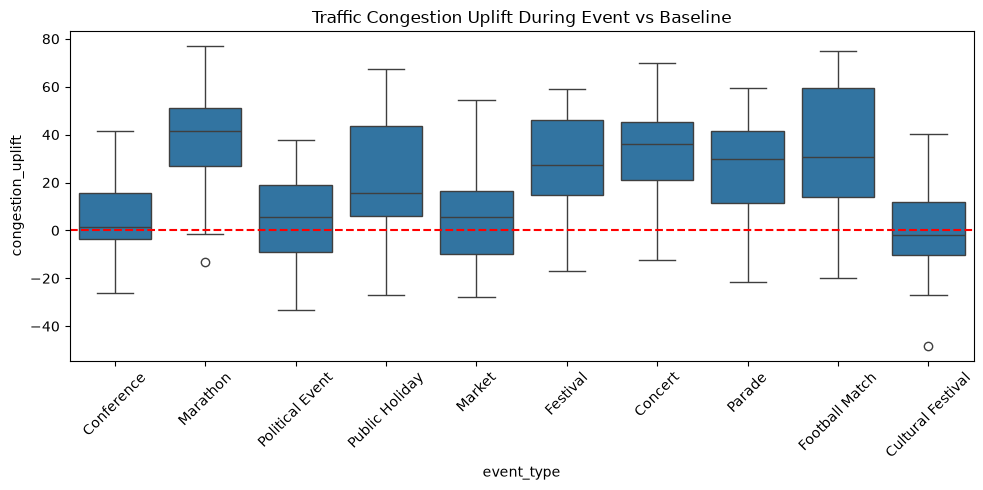

In [288]:
plt.figure(figsize=(10,5))
sns.boxplot(data=city_events, x='event_type', y='congestion_uplift')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--')
plt.title('Traffic Congestion Uplift During Event vs Baseline')
plt.tight_layout()

#### Insights: Event Impact on Traffic 

- Congestion uplift during events tracks attendance scale almost exactly, mirroring 
  the three tiers: large-scale events (Marathon +38.6, Football Match +35.0, Concert 
  +31.7) show strong, consistent congestion increases over baseline; mid-scale events 
  (Festival +26.8, Parade +26.6, Public Holiday +21.1) show a real but smaller effect; 
  small-scale events (Conference +5.2, Market +4.9, Political Event +3.7, Cultural 
  Festival +0.3) show essentially no consistent uplift — their boxplots straddle zero, 
  meaning congestion is about equally likely to be higher or lower than a normal hour.
- This confirms it's specifically crowd SIZE driving traffic impact, not merely "an event 
  is happening" — small events blend into normal district traffic patterns, while 
  large-scale events genuinely strain the road network well beyond baseline.

<a id="s7-7"></a>

### 7.7 Event impact across all four fact tables

*Why we run this.* §7.6 established the method on traffic. `add_impact_columns` wraps the two
functions into one reusable step so the identical measurement can be applied to transit ridership,
electricity demand and air quality — giving a consistent, comparable read across four independent
domains of city life.

If all four domains agree, the conclusion is robust. If they disagree, the disagreement itself is
informative — and one of them does disagree.

In [289]:
# This function adds three new columns to the city_events DataFrame for a specified metric: 
# - the average value during the event, 
# - the baseline value
# - the uplift (difference between during and baseline).

def add_impact_columns(fact_df, value_col, label):
    city_events[f'{label}_during'] = get_event_impact(fact_df, value_col)
    city_events[f'{label}_baseline'] = city_events.apply(
        lambda e: get_baseline(fact_df, value_col, e['district_id'], e['start_timestamp'].hour), axis=1
    )
    city_events[f'{label}_uplift'] = city_events[f'{label}_during'] - city_events[f'{label}_baseline']

In [290]:
add_impact_columns(public_transport_clean, 'passenger_count', 'transit')
add_impact_columns(power_grid_clean, 'electricity_demand_mwh', 'power')
add_impact_columns(air_quality_clean, 'synthetic_aqi', 'aqi')

In [291]:
city_events.groupby('event_type')[['transit_uplift', 'power_uplift', 'aqi_uplift', 'congestion_uplift']].mean().sort_values('power_uplift', ascending=False)

,transit_uplift,power_uplift,aqi_uplift,congestion_uplift
event_type,,,,
Parade,3620.841962,94.002527,3.235576,26.554790
Concert,4574.136276,93.721550,7.639658,31.726952
Football Match,6855.118620,92.255763,7.771118,35.040895
Marathon,6097.964894,79.556600,10.625660,38.585664
Festival,4155.529550,79.317074,3.915087,26.781074
Public Holiday,3330.168677,76.933645,5.235537,21.120012
Conference,594.632691,62.872474,-4.510632,5.171403
Market,959.944741,58.456339,1.005327,4.916139
Political Event,486.918369,51.924558,-0.996178,3.653731


#### Insights: Event Impact Across All Fact Tables 

- All four impact measures (`traffic`, `transit`, `power`, `air quality`) confirm the same 
  underlying pattern: large-scale events (Marathon, Football Match, Concert) create 
  substantial, consistent spikes across every domain, while small-scale events 
  (Conference, Political Event, Cultural Festival) show little to no citywide impact — 
  in some cases even slightly negative.
- `Transit` ridership shows the sharpest large-event effect (+4,500 to +6,900 for 
  Football Match/Marathon/Concert) — crowds this size clearly shift to public transport 
  in a way road traffic alone doesn't fully capture. Cultural Festival shows a small 
  NEGATIVE transit uplift (-102), consistent with it having essentially no detectable 
  impact anywhere.
- `Power demand` is the one metric that rises for every event type without exception 
  (49.7-94.0) — any gathering draws some extra electricity (lighting, sound, vendors), 
  so it doesn't split cleanly into "impact" vs "no impact" tiers like the other three; 
  it's more of a smooth scale-dependent gradient.
- `Air quality` worsens for large events (+7.6 to +10.6) but actually IMPROVES slightly 
  during Conference and Cultural Festival (-4.5, -5.1) — consistent with these being 
  smaller, likely indoor gatherings that don't add emissions and may coincide with 
  lighter-than-normal traffic in that district/hour.
- **Bottom line:** event impact on city infrastructure is driven almost entirely by 
  crowd size, not event type per se — a small Conference and a small Political Event 
  behave almost identically to "no event happening," while stadium/marathon-scale 
  events create real, measurable strain across traffic, transit, power, and air quality 
  simultaneously.

<a id="s7-8"></a>

### 7.8 Chapter takeaways

**Events fall into three clean attendance tiers**: large-scale (Concert, Marathon, Football Match,
~42–53K), mid-scale (Parade, Festival, Public Holiday, ~20–25K) and small-scale (Cultural Festival,
Political Event, Market, Conference, ~5–6K). This tiering explains almost every later finding in the
chapter.

**Under-turnout is universal, not type-specific.** Every event type runs at 87–94% of expected
attendance, a narrow 6.6-point spread — this looks like a consistent ~10–15% shrinkage built into
the data generation rather than a behavioural pattern worth attributing to any event type.

**`event_impact_level` encodes crowd size, not duration.** It climbs cleanly from Low (~5,091) to
Extreme (~57,662), an ~11× range, while duration stays flat (6.67–6.94 hours) across all four
levels.

**Recreation districts host the *fewest* events per district** (9.0 average) despite being the
intuitive expectation, while Commercial leads (18.2). Visible only after normalising by district
count — the raw sums pointed the other way.

**The capstone finding: event impact is driven by crowd size, not event type.** Large-scale events
show strong, consistent uplift across all four domains; small-scale events show near-zero or even
slightly negative uplift, statistically indistinguishable from "no event happening". Transit shows
the sharpest large-event effect (+4,500 to +6,900 riders).

**Power demand is the single exception.** It rises for every event type without exception
(+49.7 to +94.0 MWh), including the smallest ones — any gathering draws extra electricity for
lighting, sound and vendors, so power behaves as a smooth scale-dependent gradient rather than
splitting into "impact" and "no impact" tiers like the other three.

**No null handling was needed** — the first file in the project with no sensor-outage mechanism at
all.

> **Pitfalls and method notes from this chapter.**
>
> - **Boxplots where bars were needed.** The attendance-by-type comparison was initially plotted as
>   grouped boxplots; a bar chart of means told the three-tier ranking story far more clearly.
>   Boxplots suit spread and outlier questions, bar charts suit ranking questions.
> - **Nearly taking raw district event counts at face value.** Commercial (91) and Residential (86)
>   looked comparable until normalised by the number of districts of each type, which flipped the
>   ordering entirely.
> - **A new join pattern was required.** Range joins plus an explicit non-event baseline are what
>   separate "what happened during the event" from "what the event actually caused".

---
<a id="ch8"></a>

## 8. `emergency_events.csv` — incident log and response

[↑ back to contents](#toc)

**What this file is.** The second event log and the final file: ~12,900 emergency incidents, one row
each, with a timestamp, a district, a type, a severity and an outcome.

**What each row carries.**

- **Identity and classification**: `event_id`, `emergency_type` (6 categories), `severity_level`
  (Low → Critical)
- **Response and outcome**: `response_time_minutes`, `outcome`, `hospital_transport_required`
- **Pre-built flags**: `weather_related_flag`, `traffic_related_flag`

**Why this file is the right one to end on.** It is the only place where a flag can be tested
against *independently measured ground truth*. `weather_related_flag` claims an incident was
weather-driven — and `weather.csv` records what the weather actually was at that district and hour.
The same applies to `traffic_related_flag` and `traffic.csv`. Two flags, one shared test, and — as
it turns out — two opposite verdicts.

**Questions this chapter answers**

1. Does the dispatch system genuinely prioritise by severity?
2. Is hospital transport driven by incident type or by severity?
3. Do the two emergency flags survive contact with ground truth?
4. What makes one district generate more emergencies than another?

<a id="s8-1"></a>

### 8.1 Loading, types and categories

*Why we run this.* Inventory and type setup. `severity_level` gets the ordered-categorical treatment
used for `air_quality_category` and `event_impact_level`, so Low < Medium < High < Critical is
respected in every later groupby and plot — essential here, because the central question of §8.4 is
whether outcomes *escalate* with severity, and an alphabetical ordering would scramble exactly that.

The `value_counts` calls on type, severity and outcome establish the incident mix, and the
`event_id` uniqueness and null checks confirm this file is as clean as `city_events.csv`.

In [292]:
emergency_events = pd.read_csv('data/emergency_events.csv')

In [293]:
emergency_events.head(10)

,event_id,timestamp,district_id,emergency_type,severity_level,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag,outcome
0,EMG_000001,2023-01-01 06:31:00,D11,Medical Emergency,Medium,23.238000,1,0,0,0,Resolved On-Site
1,EMG_000002,2023-01-01 07:01:00,D05,Medical Emergency,Low,17.542814,1,0,0,0,Resolved On-Site
2,EMG_000003,2023-01-01 17:54:00,D07,Traffic Accident,High,13.675920,1,1,0,1,Transported to Hospital
3,EMG_000004,2023-01-01 19:09:00,D07,Public Safety Incident,Low,20.669389,0,0,0,0,Resolved On-Site
4,EMG_000005,2023-01-01 21:51:00,D09,Medical Emergency,Low,19.989403,1,0,0,0,Transported to Hospital
5,EMG_000006,2023-01-02 00:40:00,D14,Medical Emergency,Medium,12.542375,1,0,0,0,Resolved On-Site
6,EMG_000007,2023-01-02 06:11:00,D05,Public Safety Incident,Medium,18.247575,0,0,0,0,Transported to Hospital
7,EMG_000008,2023-01-02 06:08:00,D05,Medical Emergency,High,13.222128,1,1,0,0,Resolved On-Site
8,EMG_000009,2023-01-02 06:34:00,D19,Medical Emergency,Low,21.901362,1,0,0,0,Transported to Hospital
9,EMG_000010,2023-01-02 07:09:00,D01,Traffic Accident,Medium,27.726223,1,0,0,1,Transported to Hospital


In [294]:
emergency_events.shape

(12928, 11)

In [295]:
emergency_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 12928 entries, 0 to 12927
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     12928 non-null  str    
 1   timestamp                    12928 non-null  str    
 2   district_id                  12928 non-null  str    
 3   emergency_type               12928 non-null  str    
 4   severity_level               12928 non-null  str    
 5   response_time_minutes        12928 non-null  float64
 6   ambulance_required           12928 non-null  int64  
 7   hospital_transport_required  12928 non-null  int64  
 8   weather_related_flag         12928 non-null  int64  
 9   traffic_related_flag         12928 non-null  int64  
 10  outcome                      12928 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 1.1 MB


In [296]:
emergency_events['timestamp'] = pd.to_datetime(emergency_events['timestamp'], errors='coerce')

In [297]:
emergency_events['severity_level'].value_counts()

severity_level
Medium      5239
Low         5055
High        1985
Critical     649
Name: count, dtype: int64

In [298]:
severity_order = ['Low', 'Medium', 'High', 'Critical']
emergency_events['severity_level'] = pd.Categorical(emergency_events['severity_level'], categories=severity_order, ordered=True)

In [299]:
emergency_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 12928 entries, 0 to 12927
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   event_id                     12928 non-null  str           
 1   timestamp                    12928 non-null  datetime64[us]
 2   district_id                  12928 non-null  str           
 3   emergency_type               12928 non-null  str           
 4   severity_level               12928 non-null  category      
 5   response_time_minutes        12928 non-null  float64       
 6   ambulance_required           12928 non-null  int64         
 7   hospital_transport_required  12928 non-null  int64         
 8   weather_related_flag         12928 non-null  int64         
 9   traffic_related_flag         12928 non-null  int64         
 10  outcome                      12928 non-null  str           
dtypes: category(1), datetime64[us](1), float64(1), int64

In [300]:
emergency_events['outcome'].value_counts()

outcome
Resolved On-Site            7723
Transported to Hospital     4540
Referred to Other Agency     665
Name: count, dtype: int64

In [301]:
emergency_events['emergency_type'].value_counts()

emergency_type
Medical Emergency         4780
Traffic Accident          4582
Public Safety Incident    1111
Weather Emergency          914
Fire                       771
Infrastructure Failure     770
Name: count, dtype: int64

In [302]:
emergency_events.duplicated(subset=['event_id']).sum()

np.int64(0)

In [303]:
emergency_events.isna().any()

event_id                       False
timestamp                      False
district_id                    False
emergency_type                 False
severity_level                 False
response_time_minutes          False
ambulance_required             False
hospital_transport_required    False
weather_related_flag           False
traffic_related_flag           False
outcome                        False
dtype: bool

#### Insights: Consistency, dtypes & Null Handling 

- `event_id` unique, no full-row duplicates, no nulls anywhere — same clean, sensor-
  outage-free structure as city_events.csv, consistent with this being a discrete 
  incident log rather than a continuous hourly sensor feed.
- `emergency_type` is dominated by Medical Emergency (4,780) and Traffic Accident 
  (4,582) — together over 70% of all incidents — with Weather Emergency, Fire, and 
  Infrastructure Failure each much rarer (770-914).
- `outcome` skews heavily toward Resolved On-Site (7,723, ~60%) vs Transported to 
  Hospital (4,540, ~35%) and rarely Referred to Other Agency (665, ~5%).
- `severity_level` cast as an ordered category (Low < Medium < High < Critical), matching 
  the same approach used for `event_impact_level` and `air_quality_category`.

<a id="s8-2"></a>

### 8.2 Distributions of response time and incident mix

*Why we run this.* `response_time_minutes` is the only continuous measurement in the file, so it
gets the standard univariate treatment: `describe()`, a histogram and `skew()`. The right tail is
the interesting part — it raises a question that §8.4 answers: are slow responses a sign of the
system being overwhelmed, or simply of low-priority incidents being deprioritised?

The three bar charts then show the categorical mix. `severity_level` is sorted by index rather than
by frequency, which is exactly what the ordered categorical from §8.1 makes possible — severity
reads Low → Critical instead of being ranked by count.

In [304]:
emergency_events['response_time_minutes'].describe()

count    12928.000000
mean        22.031028
std          9.165784
min          2.000000
25%         15.550395
50%         20.108822
75%         26.948931
max         54.691975
Name: response_time_minutes, dtype: float64

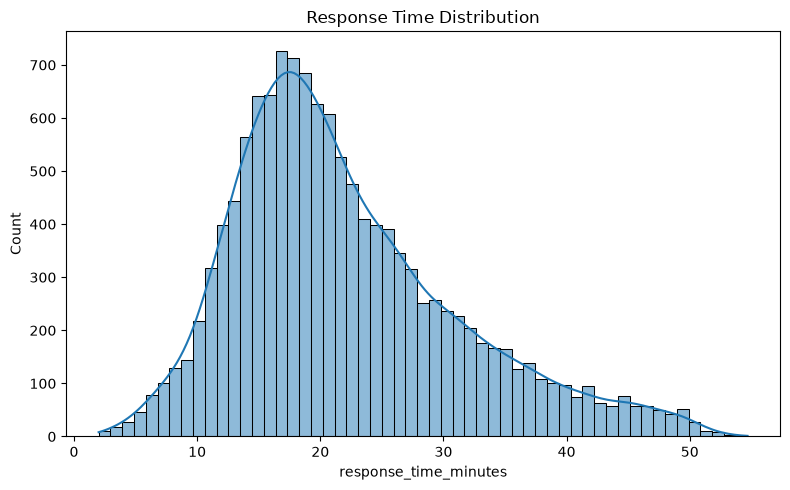

In [305]:
plt.figure(figsize=(8,5))
sns.histplot(emergency_events['response_time_minutes'], kde=True)
plt.title('Response Time Distribution')
plt.tight_layout()

In [306]:
emergency_events['response_time_minutes'].skew()

np.float64(0.8492689170679688)

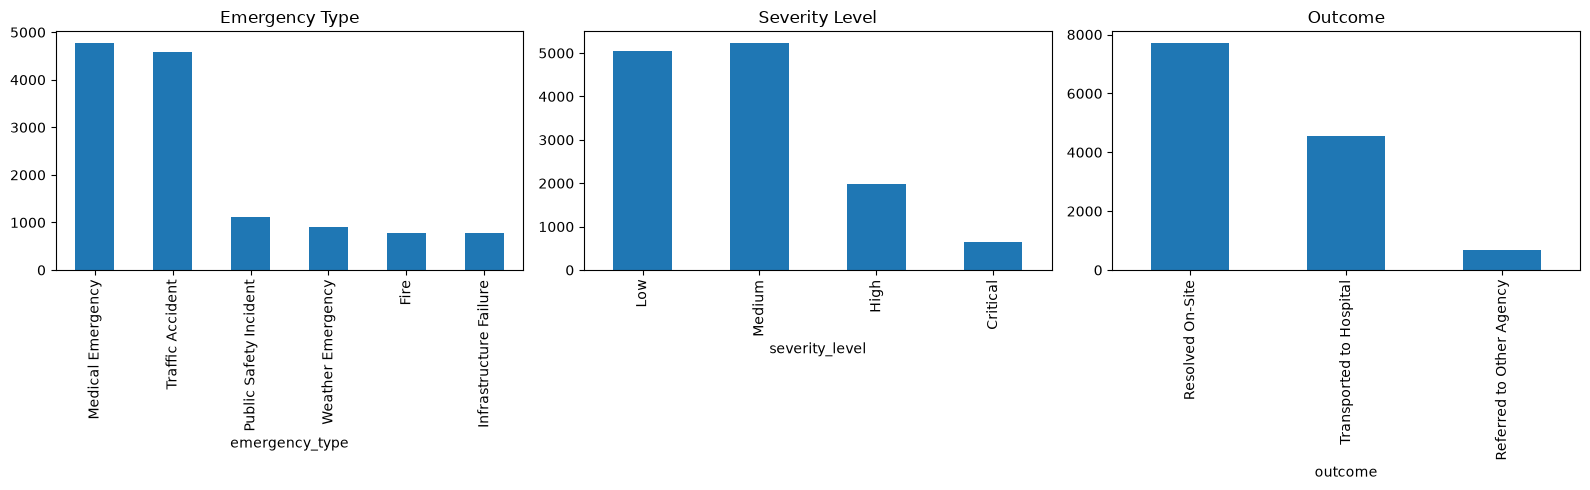

In [307]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
emergency_events['emergency_type'].value_counts().plot(kind='bar', ax=axes[0], title='Emergency Type')
emergency_events['severity_level'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Severity Level')
emergency_events['outcome'].value_counts().plot(kind='bar', ax=axes[2], title='Outcome')
plt.tight_layout()

#### Insights: Distribution 

- `response_time_minutes` is right-skewed (0.85): most responses fall in a tight 15-27 
  min band, with a real tail stretching to ~55 min for slower-response incidents — worth 
  checking whether that tail correlates with severity_level (do Critical cases get 
  faster response, or does the system get overwhelmed and respond slower?).
- Emergency types split into 2 dominant categories (Medical Emergency, Traffic Accident — 
  together ~73%) and 4 rarer types (Public Safety, Weather, Fire, Infrastructure Failure, 
  each 6-9%).
- Severity skews toward Low/Medium (86% combined), Critical is rare (5%) — expected for 
  an escalating severity scale where most incidents don't reach the top tier.
- Outcomes lean toward Resolved On-Site (60%) over Transported to Hospital (35%) and 
  rarely Referred to Other Agency (5%) — most emergencies are handled without hospital 
  involvement.

<a id="s8-3"></a>

### 8.3 When emergencies happen

*Why we run this.* Three earlier chapters found strong temporal patterns — traffic's weekday double
peak, power's dual winter/summer seasonality, weather's summer heatwave season. Emergencies should
inherit whichever of those actually drives them, and which pattern they follow is itself the
evidence for what causes them.

- **Hourly and monthly counts** — the two cycles.
- **Stacked bar of hour × type** — breaks the hourly total into its components, testing whether
  different emergency types peak at different times of day.

In [308]:
emergency_events['hour'] = emergency_events['timestamp'].dt.hour
emergency_events['month'] = emergency_events['timestamp'].dt.month

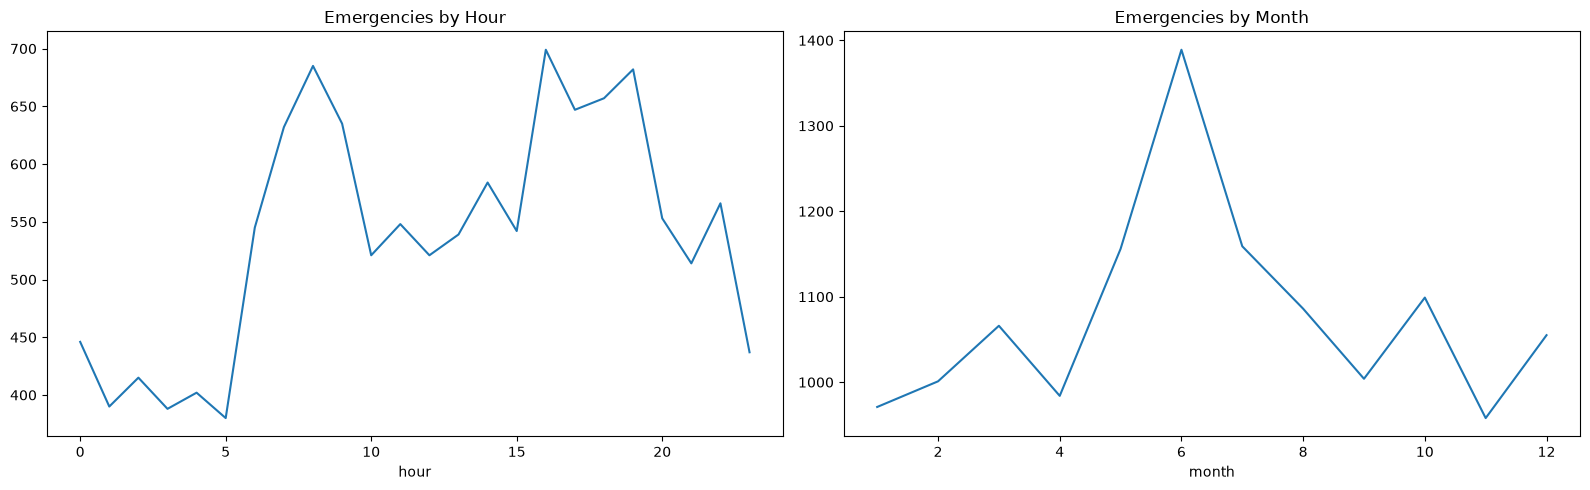

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
emergency_events.groupby('hour').size().plot(ax=axes[0], title='Emergencies by Hour')
emergency_events.groupby('month').size().plot(ax=axes[1], title='Emergencies by Month')
plt.tight_layout()

In [310]:
emergency_hour_type_pct = pd.crosstab(emergency_events['hour'], emergency_events['emergency_type']) 
emergency_hour_type_pct

emergency_type,Fire,Infrastructure Failure,Medical Emergency,Public Safety Incident,Traffic Accident,Weather Emergency
hour,,,,,,
0,28,27,146,43,171,31
1,17,29,146,36,139,23
2,31,25,169,39,127,24
3,32,21,140,34,141,20
4,24,19,152,43,130,34
5,18,24,151,31,132,24
6,33,40,211,49,188,24
7,36,30,242,54,232,38
8,33,32,252,64,246,58


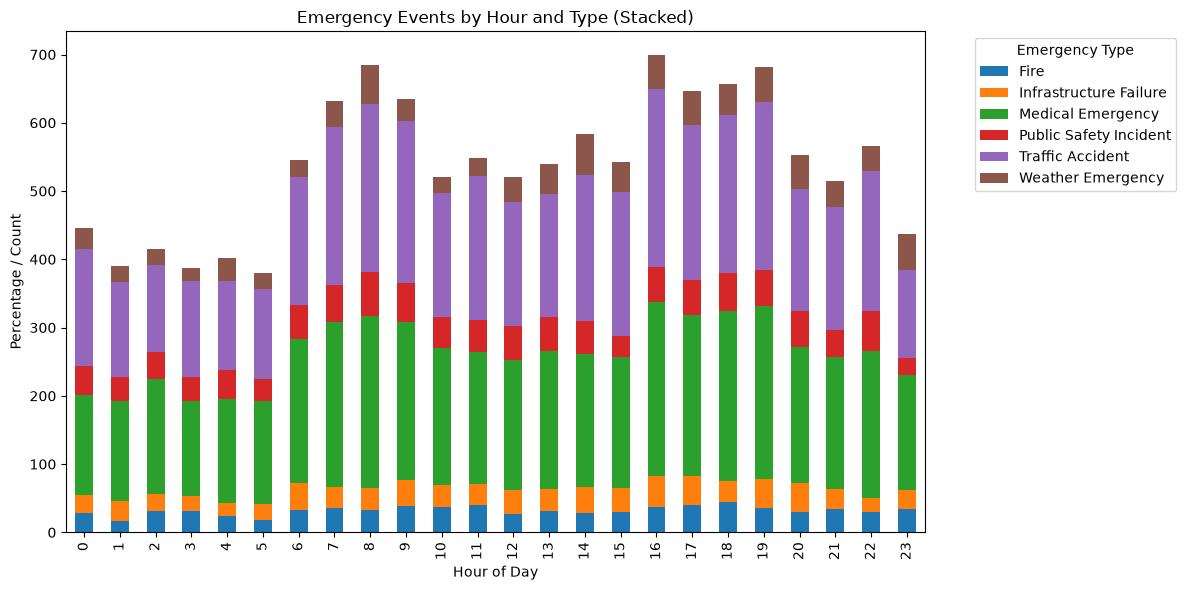

In [311]:
emergency_hour_type_pct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Emergency Events by Hour and Type (Stacked)')
plt.xlabel('Hour of Day')
plt.ylabel('Percentage / Count')
plt.legend(title='Emergency Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Insights: Time Trends 

- Emergencies show two hourly peaks — morning (7-9, ~635-685) and evening (16-19, 
  ~650-700) — loosely aligned with traffic.csv's rush-hour windows, but the swing is 
  much milder (~1.8x day/night) than traffic's own rush-hour effect (~3x) — emergencies 
  are only partially rush-hour-driven.
- Emergencies peak clearly in June (1,391) and trough in November (962) — a single 
  summer peak, not power_grid.csv's dual winter+summer pattern. This is consistent with 
  weather.csv's heatwave season

<a id="s8-4"></a>

### 8.4 Severity, response time and outcome

*Why we run this.* Two competing hypotheses about what determines an emergency's outcome: the *kind*
of emergency it is, or *how severe* it is. Each gets its own test.

- **`groupby('severity_level')`** — mean response time and hospital-transport rate per severity
  tier. Because severity is an ordered categorical, the result reads in escalating order and any
  monotonic trend is immediately visible.
- **`crosstab(emergency_type, outcome, normalize='index')`** — row-normalised so each emergency type
  sums to 100%. Without normalising, the dominant types would simply show the biggest numbers in
  every outcome column; normalising makes the *rates* comparable across types of very different
  frequency.

In [312]:
emergency_events.groupby('severity_level')[['response_time_minutes', 'hospital_transport_required']].mean()

,response_time_minutes,hospital_transport_required
severity_level,,
Low,24.816958,0.000000
Medium,21.858099,0.000000
High,17.806402,0.718892
Critical,14.648868,0.713405


In [313]:
pd.crosstab(emergency_events['emergency_type'], emergency_events['outcome'], normalize='index') * 100

outcome,Referred to Other Agency,Resolved On-Site,Transported to Hospital
emergency_type,,,
Fire,5.317769,61.219196,33.463035
Infrastructure Failure,5.194805,63.506494,31.298701
Medical Emergency,5.292887,59.937238,34.769874
Public Safety Incident,4.950495,58.595860,36.453645
Traffic Accident,5.019642,58.773461,36.206897
Weather Emergency,5.032823,60.503282,34.463895


#### Insights: Relationships 

- `response_time_minutes` correctly escalates with severity: 
    - Low (24.8 min) → Medium (21.9) → High (17.8) → Critical (14.6) 
    <br>Critical cases get responded to ~10 minutes faster than Low ones, confirming the dispatch system genuinely prioritizes by severity.
- `hospital_transport_required` shows a hard binary threshold, not a gradual escalation: 
  exactly 0% for Low and Medium, then a sharp jump to ~71-72% for High and Critical. 
  Transport requirement is essentially a High/Critical-only phenomenon.
- Emergency type has almost no relationship with outcome, contrary to the checklist's 
  hypothesis — Traffic Accident's hospital-transport rate (36.2%) is barely higher than 
  Medical Emergency (34.8%) or even Fire (33.5%), all sitting within a tight 33-36% band. 
  Outcome appears to be driven almost entirely by severity_level, not by what kind of 
  emergency occurred.

<a id="s8-5"></a>

### 8.5 Validating the emergency flags against ground truth

*Why we run this.* The strongest form of flag validation available anywhere in this project. Rather
than checking a flag against a column in its own file, we check it against an independent
measurement recorded by a different sensor system entirely.

**The merge problem, and the fix.** `emergency_events` timestamps have minute precision (an incident
at 06:31:00), while every fact table is hourly (06:00:00). An exact-key merge therefore matches only
the incidents that happen to land exactly on the hour — the first attempt returned mostly NaNs.
Flooring the emergency timestamp to the hour (`.dt.floor('h')`) into a separate `timestamp_hour`
column aligns the two grains and matches ~96% of rows. The remaining ~4% is `weather_clean`'s own
sensor-outage gap, the same mechanism traced in every fact-table chapter.

Note the merge keeps the original `timestamp` intact and joins on the floored copy via
`left_on`/`right_on`, so minute-level precision is not lost from the emergency records themselves.

- **Weather merge + group means by `weather_related_flag`** — comparing flagged and unflagged
  incidents on real rainfall and on real storm / heavy-rain rates.
- **Traffic merge + group means by `traffic_related_flag`** — the same test against real
  `congestion_index` and `accident_count`.

In [314]:
# since that other tables timestamp are hourly and the emergency table is precisely by minutes and hours
# so we will floor it to the hour to have smooth merging
emergency_events['timestamp_hour'] = emergency_events['timestamp'].dt.floor('h')
emergency_events.head()

,event_id,timestamp,district_id,emergency_type,severity_level,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag,outcome,hour,month,timestamp_hour
0,EMG_000001,2023-01-01 06:31:00,D11,Medical Emergency,Medium,23.238000,1,0,0,0,Resolved On-Site,6,1,2023-01-01 06:00:00
1,EMG_000002,2023-01-01 07:01:00,D05,Medical Emergency,Low,17.542814,1,0,0,0,Resolved On-Site,7,1,2023-01-01 07:00:00
2,EMG_000003,2023-01-01 17:54:00,D07,Traffic Accident,High,13.675920,1,1,0,1,Transported to Hospital,17,1,2023-01-01 17:00:00
3,EMG_000004,2023-01-01 19:09:00,D07,Public Safety Incident,Low,20.669389,0,0,0,0,Resolved On-Site,19,1,2023-01-01 19:00:00
4,EMG_000005,2023-01-01 21:51:00,D09,Medical Emergency,Low,19.989403,1,0,0,0,Transported to Hospital,21,1,2023-01-01 21:00:00


In [315]:
weather_flagged = emergency_events.merge(
    weather_clean[['timestamp', 'district_id', 'rainfall_mm', 'storm_flag', 'heavy_rain_flag']],
    left_on=['timestamp_hour', 'district_id'], right_on=['timestamp', 'district_id'], how='left'
)
weather_flagged.head()

,event_id,timestamp_x,district_id,emergency_type,severity_level,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag,outcome,hour,month,timestamp_hour,timestamp_y,rainfall_mm,storm_flag,heavy_rain_flag
0,EMG_000001,2023-01-01 06:31:00,D11,Medical Emergency,Medium,23.238000,1,0,0,0,Resolved On-Site,6,1,2023-01-01 06:00:00,2023-01-01 06:00:00,0.0,0.0,0.0
1,EMG_000002,2023-01-01 07:01:00,D05,Medical Emergency,Low,17.542814,1,0,0,0,Resolved On-Site,7,1,2023-01-01 07:00:00,2023-01-01 07:00:00,0.0,0.0,0.0
2,EMG_000003,2023-01-01 17:54:00,D07,Traffic Accident,High,13.675920,1,1,0,1,Transported to Hospital,17,1,2023-01-01 17:00:00,2023-01-01 17:00:00,0.0,0.0,0.0
3,EMG_000004,2023-01-01 19:09:00,D07,Public Safety Incident,Low,20.669389,0,0,0,0,Resolved On-Site,19,1,2023-01-01 19:00:00,2023-01-01 19:00:00,0.0,0.0,0.0
4,EMG_000005,2023-01-01 21:51:00,D09,Medical Emergency,Low,19.989403,1,0,0,0,Transported to Hospital,21,1,2023-01-01 21:00:00,2023-01-01 21:00:00,0.0,0.0,0.0


In [316]:
weather_flagged.groupby('weather_related_flag')[['rainfall_mm', 'storm_flag', 'heavy_rain_flag']].mean()

,rainfall_mm,storm_flag,heavy_rain_flag
weather_related_flag,,,
0,0.983395,0.136356,0.155024
1,5.727704,0.947637,0.947637


In [317]:
traffic_flagged = emergency_events.merge(
    traffic_clean[['timestamp', 'district_id', 'congestion_index', 'accident_count']],
    left_on=['timestamp_hour', 'district_id'], right_on=['timestamp', 'district_id'], how='left'
)
traffic_flagged.head()

,event_id,timestamp_x,district_id,emergency_type,severity_level,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag,outcome,hour,month,timestamp_hour,timestamp_y,congestion_index,accident_count
0,EMG_000001,2023-01-01 06:31:00,D11,Medical Emergency,Medium,23.238000,1,0,0,0,Resolved On-Site,6,1,2023-01-01 06:00:00,2023-01-01 06:00:00,57.176577,1
1,EMG_000002,2023-01-01 07:01:00,D05,Medical Emergency,Low,17.542814,1,0,0,0,Resolved On-Site,7,1,2023-01-01 07:00:00,2023-01-01 07:00:00,19.539866,0
2,EMG_000003,2023-01-01 17:54:00,D07,Traffic Accident,High,13.675920,1,1,0,1,Transported to Hospital,17,1,2023-01-01 17:00:00,2023-01-01 17:00:00,33.023990,1
3,EMG_000004,2023-01-01 19:09:00,D07,Public Safety Incident,Low,20.669389,0,0,0,0,Resolved On-Site,19,1,2023-01-01 19:00:00,2023-01-01 19:00:00,28.850701,0
4,EMG_000005,2023-01-01 21:51:00,D09,Medical Emergency,Low,19.989403,1,0,0,0,Transported to Hospital,21,1,2023-01-01 21:00:00,2023-01-01 21:00:00,31.869945,1


In [318]:
traffic_flagged.groupby('traffic_related_flag')[['congestion_index', 'accident_count']].mean()

,congestion_index,accident_count
traffic_related_flag,,
0,40.685819,0.655997
1,40.022048,0.708021


#### Insights: Flag Validation Against Ground Truth

- Note: the initial merge attempt returned mostly NaNs because `emergency_events` has 
  minute-precision timestamps while weather_clean/traffic_clean are hourly — fixed by 
  flooring emergency timestamps to the hour before merging. The corrected merge matched 
  ~96% of rows (the remaining ~4% NaN is weather_clean's own sensor-outage gap, same 
  mechanism seen throughout the project).
- `weather_related_flag` is strongly validated against ground truth: flagged incidents 
  show ~5.8x higher rainfall (5.73mm vs 0.98mm) and storm_flag/heavy_rain_flag rates 
  jump from ~14-16% to ~94.8%. This flag reliably reflects real, independently-measured 
  severe weather.
- `traffic_related_flag` FAILS validation — flagged incidents show essentially no 
  difference in congestion_index (40.0 vs 40.7, if anything slightly lower) or 
  accident_count (0.71 vs 0.66) compared to unflagged ones. Unlike weather_related_flag, 
  this flag does not correspond to genuinely worse traffic conditions at the matching 
  district/hour — it may be assigned based on the emergency_type label itself (e.g. 
  "Traffic Accident" always gets flagged) rather than actual measured congestion, or it 
  may simply be unreliable in this dataset.

<a id="s8-6"></a>

### 8.6 What drives emergency demand across districts

*Why we run this.* The final cross-table question of the notebook: why do some districts generate far
more emergencies than others? Three candidate explanations are assembled into one district-level
frame and tested together — zoning type, population density, and traffic congestion.

- **Emergency count per district**, joined to `district_type` and `population_density`.
- **Traffic-accident count per district** — the same count restricted to one emergency type, added
  with a left join so districts with no traffic accidents would still appear.
- **Mean `congestion_index` per district** from `traffic_clean`.
- **Correlation across all four** — which of the candidates actually explains emergency volume.

Everything is aggregated to 20 rows before correlating, for the same reason as in earlier chapters:
`population_density` and `district_type` are static properties, so the district is the only level at
which correlating them is meaningful.

In [319]:
district_emergency = emergency_events.groupby('district_id', as_index=False).size().rename(columns={'size': 'emergency_count'})
district_emergency = district_emergency.merge(districts[['district_id', 'district_type', 'population_density']], on='district_id')

In [320]:
district_emergency

,district_id,emergency_count,district_type,population_density
0,D01,715,Commercial,23076.923077
1,D02,654,Commercial,11842.105263
2,D03,472,Industrial,1000.000000
3,D04,707,Residential,14400.000000
4,D05,723,Residential,11428.571429
5,D06,701,Residential,14000.000000
6,D07,671,Residential,13043.478261
7,D08,612,Commercial,4166.666667
8,D09,697,Mixed,11333.333333
9,D10,523,Transport,200.000000


In [321]:
district_traffic_acc = emergency_events[emergency_events['emergency_type']=='Traffic Accident'].groupby('district_id', as_index=False).size().rename(columns={'size':'traffic_accident_count'})
district_emergency = district_emergency.merge(district_traffic_acc, on='district_id', how='left')

In [322]:
district_emergency

,district_id,emergency_count,district_type,population_density,traffic_accident_count
0,D01,715,Commercial,23076.923077,270
1,D02,654,Commercial,11842.105263,241
2,D03,472,Industrial,1000.000000,164
3,D04,707,Residential,14400.000000,261
4,D05,723,Residential,11428.571429,241
5,D06,701,Residential,14000.000000,238
6,D07,671,Residential,13043.478261,247
7,D08,612,Commercial,4166.666667,196
8,D09,697,Mixed,11333.333333,243
9,D10,523,Transport,200.000000,198


In [323]:
district_congestion = traffic_clean.groupby('district_id', as_index=False)['congestion_index'].mean()
district_emergency = district_emergency.merge(district_congestion, on='district_id')

In [324]:
district_emergency.sort_values('emergency_count', ascending=False)

,district_id,emergency_count,district_type,population_density,traffic_accident_count,congestion_index
10,D11,911,Mixed,15000.000000,316,66.338047
4,D05,723,Residential,11428.571429,241,33.807968
0,D01,715,Commercial,23076.923077,270,39.572381
3,D04,707,Residential,14400.000000,261,41.261986
5,D06,701,Residential,14000.000000,238,32.659101
8,D09,697,Mixed,11333.333333,243,41.573453
17,D18,681,Mixed,13636.363636,243,31.475648
14,D15,674,Commercial,6666.666667,253,30.265898
6,D07,671,Residential,13043.478261,247,38.715357
16,D17,655,Commercial,2769.230769,217,25.662184


In [325]:
district_emergency[['emergency_count', 'population_density', 'traffic_accident_count', 'congestion_index']].corr()

,emergency_count,population_density,traffic_accident_count,congestion_index
emergency_count,1.000000,0.766294,0.948211,0.956949
population_density,0.766294,1.000000,0.822461,0.795905
traffic_accident_count,0.948211,0.822461,1.000000,0.935115
congestion_index,0.956949,0.795905,0.935115,1.000000


#### Insights: District Distribution — emergency_events.csv

- Total emergency count correlates very strongly with `congestion_index` (r=0.96) and 
  `traffic_accident_count` (r=0.95) at the district level — districts with worse traffic 
  congestion generate substantially more emergencies overall, largely driven by Traffic 
  Accident being one of the two dominant emergency types (~35% of all incidents, per 4.A).
- `population_density` also correlates strongly (r=0.77) — denser districts see more 
  emergencies of every kind, independent of traffic specifically.
- D11 (Mixed, highest congestion at 66.3 from traffic.csv's own analysis) tops the 
  emergency count (911) and traffic accident count (316) — consistent with earlier 
  traffic.csv findings that flagged D11 as an outlier high-congestion district despite 
  its low road_capacity_index.
- **Bottom line:** emergency response demand in this city is driven primarily by traffic 
  congestion and population density, not by district_type zoning category itself — 
  Commercial, Residential, and Mixed districts all appear across the full range of 
  emergency counts depending on their actual congestion/density levels.

<a id="s8-7"></a>

### 8.7 Chapter takeaways

**`hospital_transport_required` is a hard binary threshold, not a gradual escalation** — exactly 0%
for Low and Medium severity, then a sharp jump to ~71–72% for High and Critical. It is essentially a
High/Critical-only outcome.

**Response time correctly escalates with severity**: 24.8 min (Low) → 21.9 → 17.8 → 14.6 (Critical).
Critical incidents are reached ~10 minutes faster, confirming the dispatch system genuinely
prioritises by urgency.

**Emergency type has almost no relationship with outcome.** Traffic Accident's hospital-transport
rate (36.2%) is barely different from Medical Emergency (34.8%) or Fire (33.5%) — all within a tight
33–36% band. Outcome is driven by severity, not by incident type.

**The key finding of this file — flag reliability differs sharply by flag.**
`weather_related_flag` validates strongly against ground truth: flagged incidents show ~5.8× higher
rainfall (5.73 mm vs 0.98 mm) and storm / heavy-rain rates jumping from ~15% to ~95%.
`traffic_related_flag` **fails validation entirely**: flagged incidents show no meaningful difference
in real congestion (40.0 vs 40.7) or accident count (0.71 vs 0.66). One flag reflects genuinely
measured conditions; the other most likely just mirrors the `emergency_type` label.

**Emergencies follow a single summer peak** (June, 1,391) rather than `power_grid`'s dual
winter+summer shape — consistent with a heat-driven medical emergency mechanism, and matching
`weather.csv`'s heatwave season.

**District emergency rates are driven by congestion and density, not zoning.** Emergency count
correlates 0.96 with `congestion_index`, 0.95 with traffic-accident count and 0.77 with
`population_density`. D11 — flagged back in Chapter 3 as the outlier high-congestion district —
tops the emergency count (911). Commercial, Residential and Mixed districts all appear across the
full range depending on their actual conditions rather than their category label.

> **Pitfalls caught in this chapter.**
>
> - **A merge that silently returned mostly NaNs**, caused by the minute-vs-hour grain mismatch
>   described in §8.5. Caught by checking the match rate rather than trusting the merged output, and
>   then verified after the fix rather than assumed.
> - **A `_x` / `_y` column triplication** from re-running a merge cell without restarting from a
>   clean base. A notebook-state issue rather than a logic error — the values were correct once
>   traced — but a good argument for running merge chains from a clean frame.

---
<a id="ch9"></a>

# Part IV — Synthesis

## 9. Cross-file findings: what the whole dataset says

[↑ back to contents](#toc)

Each chapter above answered questions about one file. This chapter answers the question none of them
could: **what does this city look like once all seven tables are read together?**

Three findings only became visible by comparing files:

**Industrial zoning is the single most powerful predictor in the dataset.** It predicts electricity
demand (r = 0.82 in `districts.csv`, confirmed at 0.84 in three years of real `power_grid` data) and
it predicts pollution more strongly than anything else measured (r = 0.81–0.92 with every major
pollutant). Commercial activity, by contrast, predicts transit access (0.82) and road capacity
(0.57) but is nearly irrelevant to pollution (≈ 0). Zoning is not a label in this dataset — it is
the design decision most of the city's behaviour follows from.

**The city runs on one weekday commuting rhythm.** Road traffic and public transport show the same
three-tier daily curve — night trough, midday plateau, sharp double peak at hours 7–9 and 16–19 —
and both go completely flat at weekends. Transit `service_frequency` is scheduled around exactly
those windows, and emergency incidents show a weaker echo of the same shape (~1.8× day/night swing
versus traffic's ~3×). Three independent files describing one underlying human pattern.

**Extreme weather matters; mild weather does not.** This came up in four separate chapters and
always the same way. Continuous `rainfall_mm` correlates ~0.02 with transit ridership; discrete
`storm_flag` shows a 20% ridership jump. Raw temperature correlates 0.12 with electricity demand;
`heatwave_flag` shows a 10.5% demand jump. The flags capture a threshold effect that the continuous
variable averages away. **When a flag exists alongside its continuous source variable, the flag is
often the more informative feature.**

<a id="s9-1"></a>

### 9.1 The flag reliability scoreboard

A large share of this notebook was spent validating pre-engineered flags rather than building new
features. Collected in one place, the verdicts are:

| Flag | File | Verdict | Evidence |
|---|---|---|---|
| `heatwave_flag` | weather | ✅ Reliable | 32.9 °C flagged vs 14.9 °C unflagged |
| `heavy_rain_flag` | weather | ✅ Reliable | ~5 mm vs ~1.1 mm (non-zero rain only) |
| `storm_flag` | weather | ✅ Reliable, compound | Requires high rain **and** wind (54.4 vs 9.7 km/h) |
| `weekend_flag` | traffic | ✅ Deterministic | Exact match to Sat/Sun, zero exceptions |
| `accident_flag` | traffic | ✅ Deterministic | Perfect 1-to-1 with `accident_count > 0` |
| `rush_hour_flag` | traffic | ⚠️ Partial | Correct window and weekday-only, but fires only ~71.5% within it |
| `weather_impact_score` | traffic | ✅ Trustworthy | 0.71 with rainfall, 0.67 with wind, exactly 2.0 on storms |
| `outage_flag` | power_grid | ✅ Consistent, weak signal | Pairs 1-to-1 with duration, but only ~7 pts of extra load |
| `pollution_alert_flag` | air_quality | ✅ Strong | ~4× AQI gap (189.3 vs 47.7) |
| `air_quality_category` | air_quality | ✅ Fully recoverable | Clean non-overlapping AQI bands |
| `service_disruption_flag` | public_transport | ✅ Strongest in project | 56.7 min vs 3.9 min delay (~14.5×) |
| `event_impact_level` | city_events | ✅ Valid — measures size | 11× attendance range; no relation to duration |
| `weather_related_flag` | emergency | ✅ Validated vs ground truth | ~5.8× rainfall; storm rate 15% → 95% |
| `traffic_related_flag` | emergency | ❌ **Fails** | No real difference in congestion or accident count |

**The practical rule this produces**: a flag is only usable downstream once it has been checked
against the measurement it claims to represent. Two of the fourteen would have misled a model —
`rush_hour_flag` by omission, `traffic_related_flag` outright.

<a id="s9-2"></a>

### 9.2 Six recurring structures across the city

**1. One sensor-outage mechanism explains every missing value.** Five files, ~1% of rows each,
always all measurement columns null simultaneously, always a `Communication-Loss` or
`Storm-Affected` sensor row, always uniformly spread across districts and hours. The two event logs
have no sensors and no nulls. Diagnosed and dropped identically in all five cases.

**2. Redundant columns appear in several places.** `grid_capacity_mwh` in `power_grid.csv` duplicates
`districts.csv` exactly; `grid_load_percent` and `grid_stress_index` are the same signal (r = 0.99);
`temperature_c` and `feels_like_c` are near-identical (0.99); `margin_ratio` and a utilisation
framing are `1 − x` of each other. Each of these is one feature, not two.

**3. Zero-inflation is everywhere and demands its own handling.** Rainfall (90% dry), accident and
incident counts (~96% zero), `special_event_impact` (>99% zero), `weather_impact_score` (97% at its
1.0 baseline), solar and wind generation (~59% zero), `o3` (2% zero). Each required non-zero-only
histograms, group-mean comparisons instead of correlations, and a sceptical reading of IQR outlier
counts.

**4. Demand beats capacity, consistently.** Congestion is driven by traffic volume more than by
`road_capacity_index` (−0.47). Emergencies are driven by congestion and density (0.96 / 0.77) rather
than by zoning type. Transit delay is driven by district busyness rather than by access quality. The
city's problems are demand-side.

**5. Scale beats category.** Event impact on the city is explained almost entirely by crowd size, not
event type — a small Conference and a small Political Event are statistically indistinguishable from
no event at all. Emergency outcome is explained by severity, not incident type. In both cases the
intuitive categorical explanation lost to the quantitative one.

**6. Cross-file confirmations hold.** Industrial activity → power demand appears at 0.82 in
`districts.csv` and 0.84 in `power_grid.csv`. Rush-hour windows derived from `traffic.csv` match
`public_transport.csv`'s service schedule exactly. Weather's heatwave season matches the emergency
June peak. The dataset is internally consistent across tables, which is a meaningful validation of
the analysis itself.

<a id="s9-3"></a>

### 9.3 Methodology lessons learned

The mistakes in this project were more instructive than the successes, and they cluster into five
recognisable kinds:

**Using the wrong statistical tool for the distribution.** Pearson correlation on a 96%-zero column
(`accident_count` vs congestion, r = 0.09) and on a U-shaped relationship (temperature vs electricity
demand, r = 0.12) both produced near-zero coefficients for relationships that were real and
substantial. *Check the distribution shape before choosing the summary statistic.*

**Applying the IQR rule to zero-inflated data.** Rainfall produced ~51,000 "outliers" simply because
Q1 = Q3 = 0. Restricting the analysis to non-zero events fixed it. The same fix was needed for the
renewable columns and the accident counters. *An outlier count says as much about distribution shape
as about data quality.*

**Choosing the wrong level of aggregation.** Ridership and delay correlate 0.17 row-by-row and 0.65
at district level. Static district properties (`green_space_percent`, `population_density`,
`road_capacity_index`) must be aggregated to 20 rows before correlating, or the analysis just
measures the same 20 values repeated thousands of times. *The aggregation level is an analytical
choice, not a formatting detail.*

**Mistaking a visualisation artifact for a bug.** Fractional ticks on a discrete histogram
(`bins=20` on integer counts), a squashed boxplot from a shared axis two orders of magnitude too
large, and bimodality confused with skew — three cases where the plot, not the data, was the problem.
*Before debugging the data, check the plotting parameters.*

**Reading a number without reading its sign or its context.** r = −0.79 between green space and
temperature was initially read as weak; it is a strong inverse relationship. Raw event counts by
district type looked conclusive until normalised by the number of districts per type, which reversed
the ranking.

**And one that is worth stating on its own**: in §5.4 and §5.5 a genuine contradiction appeared —
the time plot said `o3` drove AQI, the correlation matrix said `pm25`/`pm10`/`no2` did. Both were
correct about different properties (timing versus magnitude). The right response was to go back and
correct the earlier write-up once the later evidence arrived, rather than leaving two conflicting
claims standing in the same notebook.

<a id="s9-4"></a>

### 9.4 Limitations and what we would do next

**Limitations of this analysis**

- **Small-sample district types.** `Recreation`, `Transport` and `Public Services` contain one or two
  districts each. Every "type average" for them describes an individual district, and none should be
  read as a trend.
- **`Mixed` district averages are outlier-driven.** Only three districts qualify, and D11's extreme
  congestion (66.3) pulls the type average well above what the other two justify.
- **Correlations are not causal.** With 20 districts and heavily designed infrastructure, the most
  likely explanation for the strongest relationships is a common design-time cause (zoning), not
  direct causation in either direction.
- **This is simulated data.** Several patterns — the universal ~10–15% attendance shrinkage, the
  exact 2.0 ceiling on `weather_impact_score`, the 150.0 occupancy cap — are artifacts of how the
  dataset was generated rather than behavioural findings, and are flagged as such where they appear.
- **`rush_hour_flag`'s missing ~28.5%** has no explanation in the data itself. It is documented, not
  resolved.

**Natural next steps**

1. **Build the feature set for a demand model.** The validated predictors are in hand: industrial
   activity for power and pollution, traffic volume for congestion, hour-of-day and weekday for
   both, and the event flags for threshold effects.
2. **Test `volume_capacity_ratio`** — the feature considered and deferred in Chapter 3 — as a direct
   measure of the demand-versus-capacity question.
3. **Investigate `traffic_related_flag`'s failure.** Comparing it against `emergency_type` directly
   would confirm or rule out the hypothesis that it simply mirrors the label.
4. **Model the U-shaped temperature/demand relationship properly**, using a quadratic term or binned
   temperature rather than a linear coefficient that cancels itself out.
5. **Extend the event-uplift method** to emergency incidents, which was not done here — the range
   join and baseline machinery from §7.6 would transfer directly.

<a id="appA"></a>

## Appendix A — Cleaning decisions at a glance

[↑ back to contents](#toc)

| File | Duplicates | Nulls | Rows dropped | Values capped/removed | Clean frame |
|---|---|---|---|---|---|
| `districts.csv` | none | none | 0 | none | `districts` |
| `weather.csv` | none | 6,561 (1.25%), all 6 measurement cols together | 6,561 | **none** | `weather_clean` |
| `traffic.csv` | 1,052 full-row, dropped | 5,258, all 9 cols together | 5,258 | **none** | `traffic_clean` |
| `power_grid.csv` | none | 5,476, all 9 cols together | 5,476 | **none** | `power_grid_clean` |
| `air_quality.csv` | 1,052 full-row, dropped | 5,425, all 6 cols together | 5,425 | **none** | `air_quality_clean` |
| `public_transport.csv` | none | 5,242, all 4 cols together | 5,242 | **none** | `public_transport_clean` |
| `city_events.csv` | none | none | 0 | none | `city_events` |
| `emergency_events.csv` | none | none | 0 | none | `emergency_events` |

**The single reason no value was ever capped or removed.** In every file, the values the IQR rule
flagged were one of two things: a real peak condition (rush-hour volume, heatwave temperature,
peak electricity demand) or an artifact of a zero-inflated distribution (rainfall, accident counts,
renewable generation). Removing the first group would delete the phenomenon the analysis is about;
removing the second would delete every rare event the monitoring system exists to catch.

**Type conversions applied**

- `to_datetime` on every timestamp column, in all seven time-bearing files.
- `Int64` (nullable integer) on count columns in `traffic.csv` and `public_transport.csv`, so counts
  stay integers while tolerating sensor-outage nulls.
- Ordered `Categorical` on `air_quality_category`, `event_impact_level` and `severity_level`, so
  severity ordering is respected in every groupby, sort and plot.

<a id="appB"></a>

## Appendix B — Glossary of engineered and derived columns

[↑ back to contents](#toc)

**Created in this notebook**

| Column | File | Definition | Why |
|---|---|---|---|
| `population_density` | districts | `population / area_km2` | Compares districts of different sizes on equal terms |
| `margin_ratio` | districts | `(grid_capacity − base_demand) / grid_capacity` | Proportional spare grid capacity |
| `leftover_capacity_mwh` | districts | `grid_capacity − base_demand` | Absolute spare capacity in MWh |
| `hour`, `month`, `day_of_week` | several | `.dt` accessors on the timestamp | The grouping keys for every time-trend section |
| `weekend_flag` | public_transport | `day_of_week >= 5` | Rebuilt because this file ships without one |
| `event_duration` | city_events | `(end − start)` in hours | Separates "how big" from "how long" |
| `turnout_ratio` | city_events | `actual / expected attendance` | Makes under-turnout comparable across event scales |
| `*_during`, `*_baseline`, `*_uplift` | city_events | Range join vs non-event baseline (§7.6) | Isolates an event's real effect from the district's normal rhythm |
| `timestamp_hour` | emergency_events | `timestamp.dt.floor('h')` | Aligns minute-precision incidents with hourly fact tables |

**Shipped with the dataset, validated here**

`congestion_index` (validated, §3.8) · `weather_impact_score` (validated, §3.9) · `synthetic_aqi`
(validated, §5.5–5.6) · `air_quality_category` (rule recovered, §5.6) · `grid_stress_index`
(redundant with `grid_load_percent`, §4.6) · `temp_offset_c` (validated against real temperature,
§2.7) · `wind_multiplier` (consistent with measured wind by district type, §2.7) · plus the fourteen
flags scored in [§9.1](#s9-1).

---

*End of notebook.* [↑ back to contents](#toc)